In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [162]:
df = pd.read_csv("../dataset/Restaurant.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [163]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

# Early Preprocessing

## Ubah ke Inspection Level ##

In [165]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False, dropna=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,None,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [166]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[ns]
 2   INSPECTION TYPE      77629 non-null  object        
 3   DBA                  77629 non-null  object        
 4   BORO                 77629 non-null  object        
 5   BUILDING             77390 non-null  object        
 6   STREET               77629 non-null  object        
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  object        
 9   CUISINE_DESCRIPTION  77629 non-null  object        
 10  ACTION               77629 non-null  object        
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  object        
 13  GRADE_DATE           44221 non-

In [167]:
df_ins.duplicated().sum()

np.int64(0)

In [168]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

**Drop Missing Value in Score**

In [169]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()
df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Drop baris yang SCORE-nya null karena SCORE adalah kolom target, tidak bisa diimputasi

In [170]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='object')

## Ubah Tipe Data ##

In [171]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:
    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:
    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:
    df_ins[col] = df_ins[col].astype("category")
    
df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[ns]
INSPECTION TYPE              category
DBA                            object
BORO                         category
BUILDING                       object
STREET                         object
ZIPCODE                      category
PHONE                          object
CUISINE_DESCRIPTION          category
ACTION                         object
SCORE                         float64
GRADE                          object
GRADE_DATE             datetime64[ns]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                            object
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [172]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year
df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month
df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter
df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Latitude",
    "Longitude",
    "Community_Board",
    "INSPECTION TYPE",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek"
]

df_base = df_ins[
    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features
].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [173]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='object')

In [174]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[ns]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [175]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":
        if "Unknown" not in df_base[col].cat.categories:
            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")
    
df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [176]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

## Handle Missing Value Community Board ##

In [177]:
df_base["Community_Board"] = df_base["Community_Board"].astype(str)
df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)
df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")
df_base[["Community_Board"]].isna().sum()

Community_Board    0
dtype: int64

## Handle Missing Value Latitude Longitude ##

In [178]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [179]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")
df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA
df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(
    df_base.groupby("CAMIS")["Latitude"].transform("median")
)

df_base["Longitude"] = df_base["Longitude"].fillna(
    df_base.groupby("CAMIS")["Longitude"].transform("median")
)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())
df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [180]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [181]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [182]:
TOP_N_CUISINE = 15
TOP_N_INSTYPE = 5

top_cuisine = df_base["CUISINE_DESCRIPTION"].value_counts().nlargest(TOP_N_CUISINE).index
df_base["CUISINE_DESCRIPTION"] = (
    df_base["CUISINE_DESCRIPTION"]
    .apply(lambda x: x if x in top_cuisine else "Other")
)

top_instype = df_base["INSPECTION TYPE"].value_counts().nlargest(TOP_N_INSTYPE).index
df_base["INSPECTION TYPE"] = (
    df_base["INSPECTION TYPE"]
    .apply(lambda x: x if x in top_instype else "Other")
)

In [183]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())
print()
print(df_base["INSPECTION TYPE"].value_counts())
print(df_base["CUISINE_DESCRIPTION"].nunique())
print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

# Advanced Preprocessing

## Step 1 - Advanced Preprocessing: Feature Engineering dari Violation ##

- `df_ins` sudah mengagregasi `violation_count`, `critical_count`, dan `has_critical`
- Namun fitur-fitur ini **tidak ikut masuk ke `df_base`** saat pemilihan kolom
- Langkah ini melengkapi fitur violation yang kurang, lalu menarik semuanya ke `df_base`


In [184]:
inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

viol_clean = df_recent.copy()
viol_clean["VIOLATION CODE"]  = viol_clean["VIOLATION CODE"].astype(str).str.strip()
viol_clean["CRITICAL FLAG"]   = viol_clean["CRITICAL FLAG"].astype(str).str.strip().str.lower()

viol_clean = viol_clean[
    viol_clean["VIOLATION CODE"].notna() &
    (viol_clean["VIOLATION CODE"] != "") &
    (viol_clean["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_dedup = viol_clean.drop_duplicates(
    subset=inspection_key + ["VIOLATION CODE"]
).copy()

viol_features = (
    viol_dedup.groupby(inspection_key, as_index=False)
    .agg(
        violation_count    = ("VIOLATION CODE", "count"),
        unique_viol_codes  = ("VIOLATION CODE", "nunique"),
        critical_count     = ("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        noncritical_count  = ("CRITICAL FLAG", lambda x: (x != "critical").sum()),
        has_critical       = ("CRITICAL FLAG", lambda x: (x == "critical").any()),
    )
)

viol_features["critical_ratio"] = (
    viol_features["critical_count"] / viol_features["violation_count"].replace(0, pd.NA)
).fillna(0)

print("Shape viol_features:", viol_features.shape)
viol_features.head()

Shape viol_features: (77629, 9)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,violation_count,unique_viol_codes,critical_count,noncritical_count,has_critical,critical_ratio
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,3,3,2,1,True,0.666667
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,3,3,1,2,True,0.333333
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,3,3,1,2,True,0.333333
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,2,2,1,1,True,0.500000
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,2,2,0,True,1.000000


**1b. Binary Flag untuk Top Violation Codes dengan score tertinggi**

Dari EDA diketahui 9/10 violation code dengan median score tertinggi adalah critical code (05F, 06C, dst).
Membuat flag kehadiran kode-kode tersebut sebagai fitur eksplisit.


In [185]:
TOP_VIOL_CODES = ["10F", "08A", "06D", "10B", "02G", "06C", "02B", "04L", "04N", "04A", "05F", "06E", "09C"]

code_pivot = (
    viol_dedup[viol_dedup["VIOLATION CODE"].isin(TOP_VIOL_CODES)]
    .assign(val=1)
    .pivot_table(
        index=inspection_key,
        columns="VIOLATION CODE",
        values="val",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

code_pivot.columns.name = None
code_pivot = code_pivot.rename(
    columns={c: f"viol_{c}" for c in TOP_VIOL_CODES if c in code_pivot.columns}
)

print("Shape code_pivot:", code_pivot.shape)
code_pivot.head()

Shape code_pivot: (64843, 16)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,viol_02B,viol_02G,viol_04A,viol_04L,viol_04N,viol_05F,viol_06C,viol_06D,viol_06E,viol_08A,viol_09C,viol_10B,viol_10F
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,0,0,0,1,0,0,0,0,0,1,0,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,0,0,0,1,0,0,0,0,0,1,0,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,1,0,0,0,0,0,1
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,0,0,0,0,1
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,1,0,1,0,0,0,0


In [186]:
for col in inspection_key:
    viol_features[col]  = viol_features[col].astype(str)
    code_pivot[col]     = code_pivot[col].astype(str)
    df_base[col]        = df_base[col].astype(str)

df_base = df_base.merge(viol_features, on=inspection_key, how="left")

df_base = df_base.merge(code_pivot, on=inspection_key, how="left")

viol_numeric_cols = (
    ["violation_count", "unique_viol_codes", "critical_count",
     "noncritical_count", "critical_ratio"]
    + [c for c in df_base.columns if c.startswith("viol_")]
)

df_base[viol_numeric_cols] = df_base[viol_numeric_cols].fillna(0)
df_base["has_critical"] = df_base["has_critical"].fillna(False)

print("Shape df_base setelah merge violation features:", df_base.shape)
print("\nKolom baru yang ditambahkan:")
print([c for c in df_base.columns if c in viol_numeric_cols or c == "has_critical"])

Shape df_base setelah merge violation features: (68860, 33)

Kolom baru yang ditambahkan:
['violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'viol_10B', 'viol_10F']


In [187]:
print("=== Info df_base ===")
print(df_base[viol_numeric_cols + ["has_critical"]].describe())
print()
print("=== Missing values fitur violation ===")
print(df_base[viol_numeric_cols + ["has_critical"]].isna().sum())
print()
print("=== Contoh data ===")
df_base[[
    "CAMIS", "INSPECTION DATE", "SCORE",
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio", "has_critical"
]].head(10)

=== Info df_base ===
       violation_count  unique_viol_codes  critical_count  noncritical_count  \
count     68860.000000       68860.000000    68860.000000       68860.000000   
mean          3.246660           3.246660        1.815800           1.430860   
std           2.112278           2.112278        1.526577           1.067399   
min           0.000000           0.000000        0.000000           0.000000   
25%           2.000000           2.000000        1.000000           1.000000   
50%           3.000000           3.000000        1.000000           1.000000   
75%           4.000000           4.000000        3.000000           2.000000   
max          19.000000          19.000000       13.000000           8.000000   

       critical_ratio      viol_02B      viol_02G      viol_04A      viol_04L  \
count    68860.000000  68860.000000  68860.000000  68860.000000  68860.000000   
mean         0.510207      0.187090      0.220447      0.095760      0.169300   
std          0.

,CAMIS,INSPECTION DATE,SCORE,violation_count,critical_count,noncritical_count,unique_viol_codes,critical_ratio,has_critical
0,30075445,2023-08-01,38.0,3.0,2.0,1.0,3.0,0.666667,True
1,30075445,2023-08-22,12.0,3.0,1.0,2.0,3.0,0.333333,True
2,30075445,2024-11-08,10.0,3.0,1.0,2.0,3.0,0.333333,True
3,30075445,2026-02-27,7.0,2.0,1.0,1.0,2.0,0.500000,True
4,30191841,2023-04-23,10.0,2.0,2.0,0.0,2.0,1.000000,True
5,30191841,2024-11-20,24.0,6.0,2.0,4.0,6.0,0.333333,True
6,30191841,2025-02-20,10.0,2.0,2.0,0.0,2.0,1.000000,True
7,40356018,2024-04-16,0.0,1.0,0.0,1.0,1.0,0.000000,False
8,40356018,2025-09-17,10.0,2.0,1.0,1.0,2.0,0.500000,True
9,40356483,2023-11-16,35.0,6.0,3.0,3.0,6.0,0.500000,True


## Step 2 - Advanced Preprocessing: Feature Engineering Historis per Restoran ##

**Konteks & Anti Data Leakage:**

Karena 68%+ restoran adalah **repeat offender**, riwayat inspeksi sebelumnya sangat prediktif terhadap score saat ini.

Aturan krusial: **fitur historis hanya boleh menggunakan data dari inspeksi SEBELUM tanggal inspeksi yang sedang diprediksi.**
Jika memakai data dari tanggal yang sama atau sesudahnya → **data leakage** → model terlihat bagus saat training tapi gagal di production.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `prev_score` | Score inspeksi terakhir restoran sebelum inspeksi ini |
| `avg_score_last3` | Rata-rata score 3 inspeksi terakhir |
| `n_prev_inspections` | Jumlah inspeksi sebelumnya |
| `days_since_last_inspection` | Jarak hari dari inspeksi terakhir |
| `prev_critical_count` | Jumlah critical violation di inspeksi terakhir |
| `ever_had_critical` | Apakah restoran pernah dapat critical violation sebelumnya |


In [188]:
df_hist = df_base.copy()
df_hist["INSPECTION DATE"] = pd.to_datetime(df_hist["INSPECTION DATE"])
df_hist = df_hist.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)

df_hist["prev_score"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .shift(1) 
)

df_hist["avg_score_last3"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df_hist["n_prev_inspections"] = (
    df_hist.groupby("CAMIS").cumcount()
)

df_hist["prev_inspection_date"] = (
    df_hist.groupby("CAMIS")["INSPECTION DATE"].shift(1)
)
df_hist["days_since_last_inspection"] = (
    (df_hist["INSPECTION DATE"] - df_hist["prev_inspection_date"]).dt.days
)
df_hist = df_hist.drop(columns=["prev_inspection_date"])

df_hist["prev_critical_count"] = (
    df_hist.groupby("CAMIS")["critical_count"].shift(1)
)

df_hist["ever_had_critical"] = (
    df_hist.groupby("CAMIS")["has_critical"]
    .transform(lambda x: x.shift(1).fillna(False).cumsum()) > 0
)

print("Shape df_hist:", df_hist.shape)
print()
print("Missing values fitur historis:")
hist_cols = ["prev_score", "avg_score_last3", "n_prev_inspections",
             "days_since_last_inspection", "prev_critical_count", "ever_had_critical"]
print(df_hist[hist_cols].isna().sum())

Shape df_hist: (68860, 39)

Missing values fitur historis:
prev_score                    27071
avg_score_last3               27071
n_prev_inspections                0
days_since_last_inspection    27071
prev_critical_count           27071
ever_had_critical                 0
dtype: int64


**Handle Missing Value Fitur Historis**

Inspeksi pertama setiap restoran (`n_prev_inspections == 0`) akan selalu NaN pada `prev_score`, `avg_score_last3`, dll.
karena belum ada riwayat — ini **bukan error**, melainkan kondisi wajar.

Strategi imputasi:
- `prev_score` & `avg_score_last3` → isi dengan **median global** sebagai baseline
- `days_since_last_inspection` → isi dengan nilai **besar (999)** sebagai sinyal "pertama kali"
- `prev_critical_count` → isi **0** (belum pernah ada critical)
- `ever_had_critical` → isi **False**


In [189]:
df_hist["prev_score"]      = np.log1p(df_hist["prev_score"])
df_hist["avg_score_last3"] = np.log1p(df_hist["avg_score_last3"])

global_median_score = df_hist["SCORE"].median()

df_hist["prev_score"]                = df_hist["prev_score"].fillna(global_median_score)
df_hist["avg_score_last3"]           = df_hist["avg_score_last3"].fillna(global_median_score)
df_hist["days_since_last_inspection"]= df_hist["days_since_last_inspection"].fillna(999)
df_hist["prev_critical_count"]       = df_hist["prev_critical_count"].fillna(0)
df_hist["ever_had_critical"]         = df_hist["ever_had_critical"].fillna(False)

print("Missing values setelah imputasi:")
print(df_hist[hist_cols].isna().sum())
print()

df_base = df_hist.copy()

print("=== Distribusi fitur historis ===")
df_base[hist_cols].describe()

Missing values setelah imputasi:
prev_score                    0
avg_score_last3               0
n_prev_inspections            0
days_since_last_inspection    0
prev_critical_count           0
ever_had_critical             0
dtype: int64

=== Distribusi fitur historis ===


,prev_score,avg_score_last3,n_prev_inspections,days_since_last_inspection,prev_critical_count
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,6.813723,6.875302,1.095353,573.208205,1.268995
std,5.020827,4.958028,1.239170,378.471862,1.648423
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.639057,2.793208,0.000000,210.000000,0.000000
50%,3.555348,3.511545,1.000000,512.000000,1.000000
75%,13.000000,13.000000,2.000000,999.000000,2.000000
max,13.000000,13.000000,13.000000,1078.000000,13.000000


## Step 3 - Advanced Preprocessing: Feature Engineering Geospasial (Target Encoding) ##

**Konteks:**

Dari EDA diketahui lokasi (BORO, ZIPCODE, Community Board) berpengaruh terhadap SCORE.
Daripada hanya pakai label encoding biasa, kami membuat **Target Encoding berbasis agregasi** —
mengganti nilai kategorikal dengan statistik SCORE historis di wilayah tersebut.

**Strategi Anti Data Leakage:**
Target encoding harus dihitung dari **data training saja** dan di-apply ke test set.
Di tahap ini (sebelum split), kami gunakan pendekatan **Leave-One-Out** atau cukup
hitung dari keseluruhan data sebagai proxy — split resmi akan dilakukan di Step 8.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `boro_median_score` | Median score historis per BORO |
| `boro_mean_score` | Mean score historis per BORO |
| `zipcode_median_score` | Median score historis per ZIPCODE |
| `zipcode_mean_score` | Mean score historis per ZIPCODE |
| `community_board_median_score` | Median score historis per Community Board |


In [190]:
boro_stats = (
    df_base.groupby("BORO")["SCORE"]
    .agg(boro_median_score="median", boro_mean_score="mean")
    .reset_index()
)

zipcode_stats = (
    df_base.groupby("ZIPCODE")["SCORE"]
    .agg(zipcode_median_score="median", zipcode_mean_score="mean")
    .reset_index()
)

cb_stats = (
    df_base.groupby("Community_Board")["SCORE"]
    .agg(community_board_median_score="median")
    .reset_index()
)

df_base = df_base.merge(boro_stats,    on="BORO",            how="left")
df_base = df_base.merge(zipcode_stats, on="ZIPCODE",         how="left")
df_base = df_base.merge(cb_stats,      on="Community_Board", how="left")

global_median = df_base["SCORE"].median()
geo_encode_cols = [
    "boro_median_score", "boro_mean_score",
    "zipcode_median_score", "zipcode_mean_score",
    "community_board_median_score"
]
df_base[geo_encode_cols] = df_base[geo_encode_cols].fillna(global_median)

print("Shape df_base setelah geospatial encoding:", df_base.shape)
print()
print("Missing values fitur geospatial:")
print(df_base[geo_encode_cols].isna().sum())

Shape df_base setelah geospatial encoding: (68860, 44)

Missing values fitur geospatial:
boro_median_score               0
boro_mean_score                 0
zipcode_median_score            0
zipcode_mean_score              0
community_board_median_score    0
dtype: int64


In [191]:
geo_hist_cols = geo_encode_cols + hist_cols

print("=== Distribusi fitur geospatial ===")
print(df_base[geo_encode_cols].describe())
print()
print("=== Contoh Perbandingan: BORO vs boro_median_score ===")
print(df_base.groupby("BORO")[["boro_median_score", "boro_mean_score"]].first().sort_values("boro_median_score", ascending=False))
print()
print("=== Total kolom df_base saat ini ===")
print(f"Shape: {df_base.shape}")
print(df_base.columns.tolist())


=== Distribusi fitur geospatial ===
       boro_median_score  boro_mean_score  zipcode_median_score  \
count       68860.000000     68860.000000          68860.000000   
mean           12.625385        18.118501             12.754676   
std             0.484027         0.858589              1.547715   
min            12.000000        15.463415              2.000000   
25%            12.000000        17.384430             12.000000   
50%            13.000000        17.723636             13.000000   
75%            13.000000        18.158726             13.000000   
max            13.000000        19.551193             28.000000   

       zipcode_mean_score  community_board_median_score  
count        68860.000000                  68860.000000  
mean            18.118501                     12.773003  
std              2.068082                      1.044980  
min              4.000000                      4.000000  
25%             16.851372                     12.000000  
50%         

## Step 4 - Correlation Analysis: Seleksi Fitur terhadap Target (SCORE) ##

**Tujuan:** Identifikasi fitur mana yang benar-benar berkorelasi dengan SCORE sebelum masuk modeling.

Dua pendekatan digunakan secara bersamaan:
- **Pearson / Spearman** → untuk fitur numerik (linear vs monotonic)
- **Eta-squared (η²)** → untuk fitur kategorikal (kekuatan asosiasi via ANOVA)

Threshold keputusan (bisa disesuaikan):
- Numerik: |Spearman ρ| ≥ 0.05 → **keep**
- Kategorikal: η² ≥ 0.01 → **keep** (efek kecil tapi informatif)


In [192]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

exclude_cols = {"CAMIS", "INSPECTION DATE", "SCORE"}
num_cols = [
    c for c in df_base.select_dtypes(include="number").columns
    if c not in exclude_cols
]

corr_results = []
for col in num_cols:
    valid = df_base[[col, "SCORE"]].dropna()
    if len(valid) < 30:
        continue
    pearson_r,  pearson_p  = stats.pearsonr(valid[col],  valid["SCORE"])
    spearman_r, spearman_p = stats.spearmanr(valid[col], valid["SCORE"])
    corr_results.append({
        "feature":     col,
        "pearson_r":   round(pearson_r,  4),
        "pearson_p":   round(pearson_p,  4),
        "spearman_r":  round(spearman_r, 4),
        "spearman_p":  round(spearman_p, 4),
        "abs_spearman": abs(spearman_r),
    })

df_corr = (
    pd.DataFrame(corr_results)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

SPEARMAN_THRESHOLD = 0.05
df_corr["keep"] = df_corr["abs_spearman"] >= SPEARMAN_THRESHOLD

print(f"Total fitur numerik diperiksa: {len(df_corr)}")
print(f"Fitur yang cukup berkorelasi (|ρ| ≥ {SPEARMAN_THRESHOLD}): {df_corr['keep'].sum()}")
print(f"Fitur yang lemah / tidak berkorelasi: {(~df_corr['keep']).sum()}")
print()
df_corr


Total fitur numerik diperiksa: 34
Fitur yang cukup berkorelasi (|ρ| ≥ 0.05): 25
Fitur yang lemah / tidak berkorelasi: 9



,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman,keep
0,critical_count,0.8106,0.0000,0.8381,0.0000,0.838134,True
1,violation_count,0.7831,0.0000,0.8176,0.0000,0.817552,True
2,unique_viol_codes,0.7831,0.0000,0.8176,0.0000,0.817552,True
3,viol_08A,0.4211,0.0000,0.4795,0.0000,0.479486,True
4,critical_ratio,0.2954,0.0000,0.4245,0.0000,0.424459,True
5,viol_02G,0.3507,0.0000,0.3808,0.0000,0.380793,True
6,noncritical_count,0.3904,0.0000,0.3651,0.0000,0.365133,True
7,viol_04L,0.2862,0.0000,0.3289,0.0000,0.328939,True
8,viol_02B,0.2918,0.0000,0.3208,0.0000,0.320815,True
9,viol_04N,0.2572,0.0000,0.2806,0.0000,0.280551,True


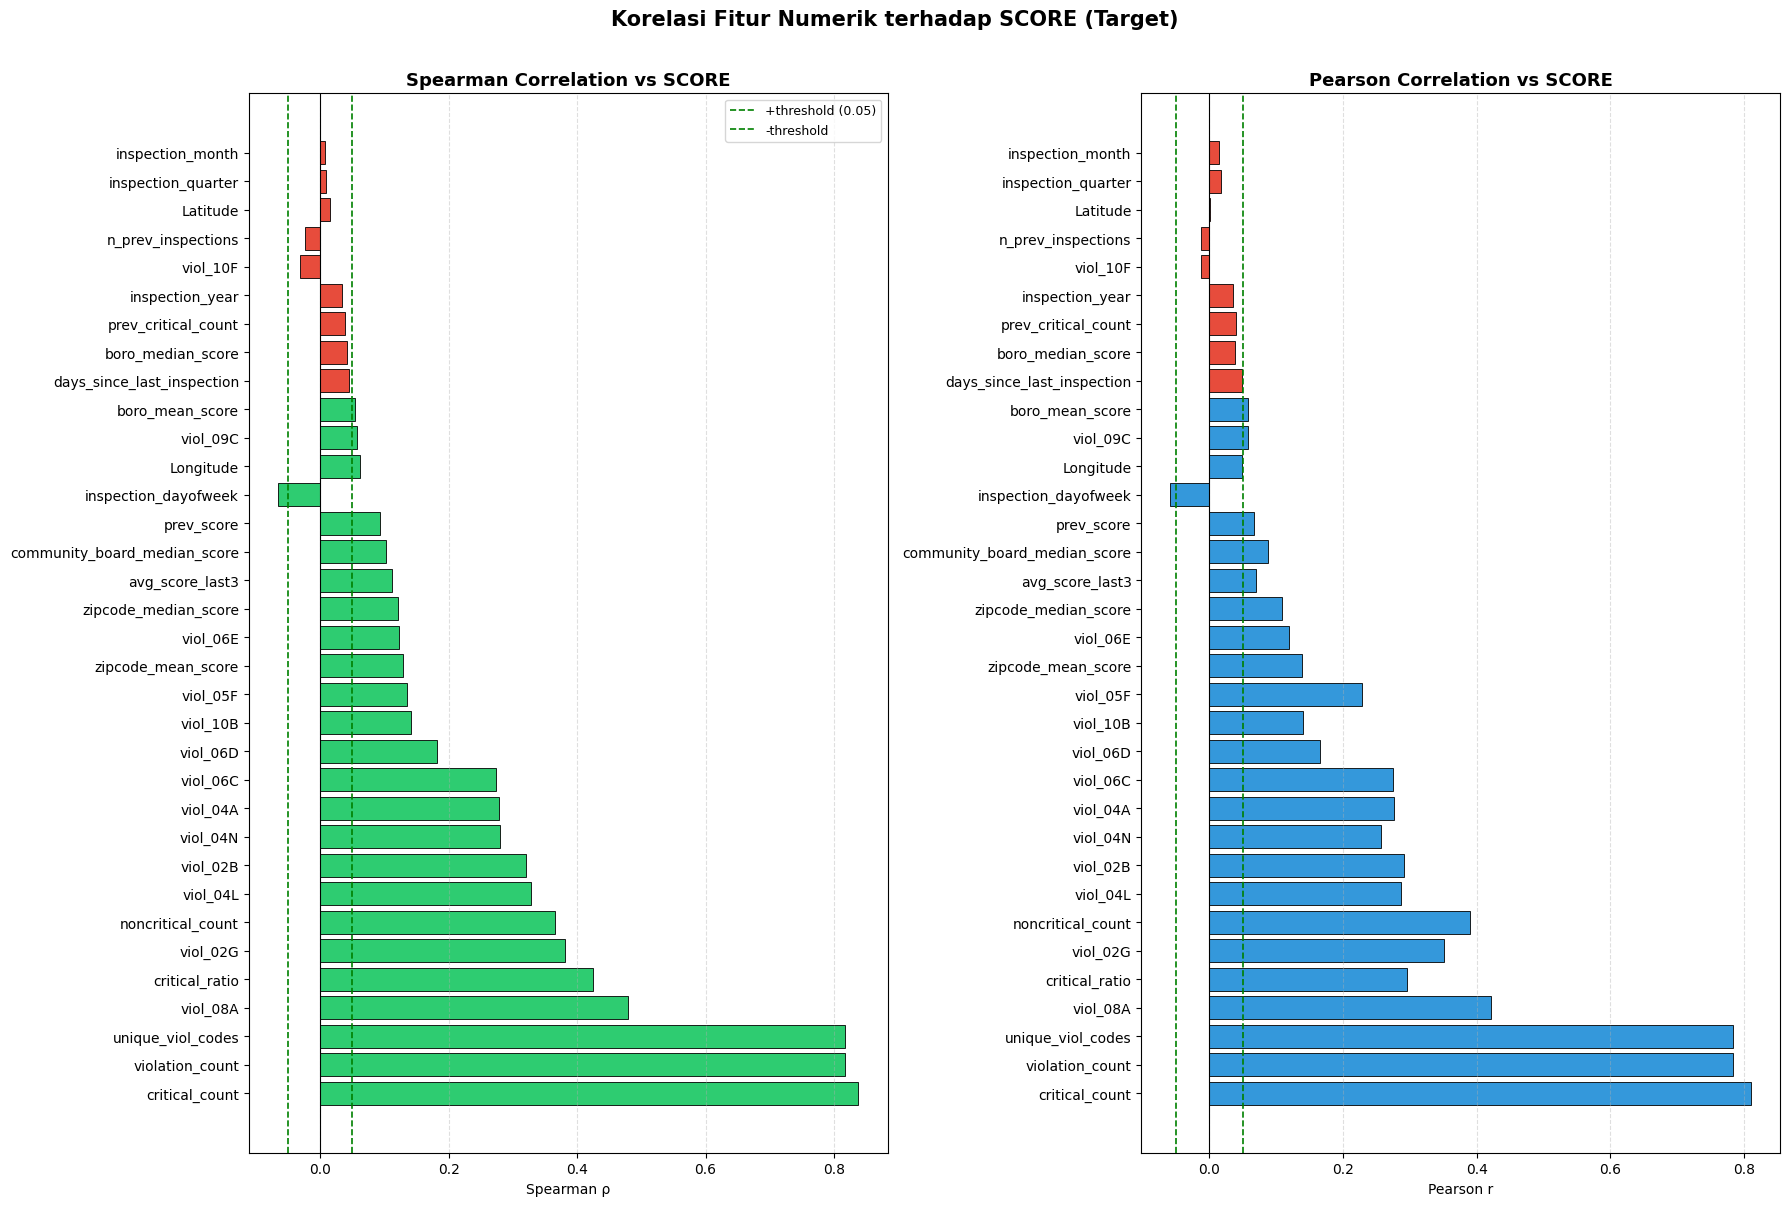


Fitur LEMAH (akan dipertimbangkan untuk di-drop):
['days_since_last_inspection', 'boro_median_score', 'prev_critical_count', 'inspection_year', 'viol_10F', 'n_prev_inspections', 'Latitude', 'inspection_quarter', 'inspection_month']

Fitur KUAT (dipertahankan):
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_06D', 'viol_10B', 'viol_05F', 'zipcode_mean_score', 'viol_06E', 'zipcode_median_score', 'avg_score_last3', 'community_board_median_score', 'prev_score', 'inspection_dayofweek', 'Longitude', 'viol_09C', 'boro_mean_score']


In [193]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_corr) * 0.35)))

colors_sp = ["#2ecc71" if k else "#e74c3c" for k in df_corr["keep"]]
axes[0].barh(df_corr["feature"], df_corr["spearman_r"], color=colors_sp, edgecolor="black", linewidth=0.6)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"+threshold ({SPEARMAN_THRESHOLD})")
axes[0].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"-threshold")
axes[0].set_title("Spearman Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Spearman ρ")
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

colors_pe = ["#3498db" if k else "#e74c3c" for k in df_corr["keep"]]
axes[1].barh(df_corr["feature"], df_corr["pearson_r"], color=colors_pe, edgecolor="black", linewidth=0.6)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].set_title("Pearson Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Pearson r")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Korelasi Fitur Numerik terhadap SCORE (Target)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nFitur LEMAH (akan dipertimbangkan untuk di-drop):")
print(df_corr[~df_corr["keep"]]["feature"].tolist())
print("\nFitur KUAT (dipertahankan):")
print(df_corr[df_corr["keep"]]["feature"].tolist())


In [194]:
cat_cols_to_check = [
    "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE", "ZIPCODE", "Community_Board"
]

eta_results = []
for col in cat_cols_to_check:
    tmp = df_base[[col, "SCORE"]].dropna().copy()
    tmp[col] = tmp[col].astype(str)

    groups = [grp["SCORE"].values for _, grp in tmp.groupby(col) if len(grp) >= 5]
    if len(groups) < 2:
        continue

    f_stat, p_val = stats.f_oneway(*groups)

    grand_mean = tmp["SCORE"].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((tmp["SCORE"] - grand_mean)**2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else 0

    eta_results.append({
        "feature":    col,
        "f_stat":     round(f_stat, 4),
        "p_value":    round(p_val, 6),
        "eta_squared": round(eta_sq, 6),
        "n_categories": tmp[col].nunique(),
    })

df_eta = (
    pd.DataFrame(eta_results)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

ETA_THRESHOLD = 0.01
df_eta["keep"] = df_eta["eta_squared"] >= ETA_THRESHOLD
df_eta["effect_size"] = df_eta["eta_squared"].apply(
    lambda x: "Large (η²≥0.14)" if x >= 0.14
    else "Medium (η²≥0.06)" if x >= 0.06
    else "Small (η²≥0.01)" if x >= 0.01
    else "Negligible"
)

print(f"Total fitur kategorikal diperiksa: {len(df_eta)}")
print()
df_eta


Total fitur kategorikal diperiksa: 5



,feature,f_stat,p_value,eta_squared,n_categories,keep,effect_size
0,CUISINE_DESCRIPTION,112.4816,0.0,0.023922,16,True,Small (η²≥0.01)
1,INSPECTION TYPE,288.1229,0.0,0.020494,6,True,Small (η²≥0.01)
2,ZIPCODE,6.5192,0.0,0.018733,230,True,Small (η²≥0.01)
3,Community_Board,11.8809,0.0,0.011102,70,True,Small (η²≥0.01)
4,BORO,45.3612,0.0,0.003283,6,False,Negligible


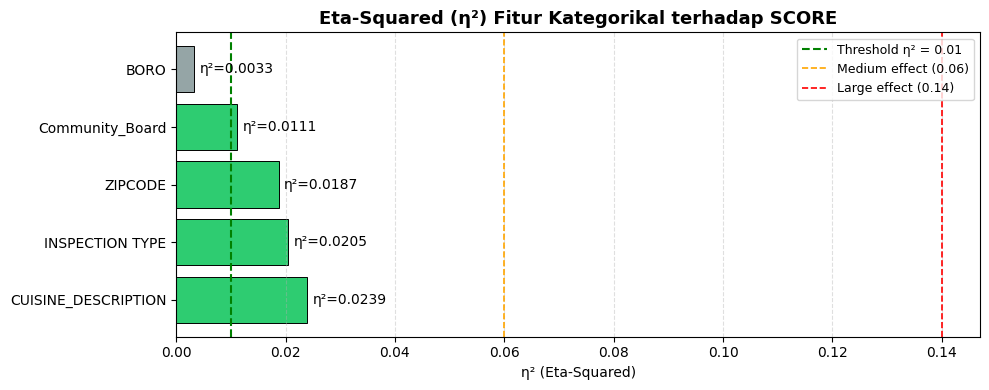

In [195]:
fig, ax = plt.subplots(figsize=(10, max(4, len(df_eta) * 0.7)))

color_map = {
    "Large (η²≥0.14)":   "#c0392b",
    "Medium (η²≥0.06)":  "#e67e22",
    "Small (η²≥0.01)":   "#2ecc71",
    "Negligible":         "#95a5a6",
}
bar_colors = [color_map[e] for e in df_eta["effect_size"]]

bars = ax.barh(df_eta["feature"], df_eta["eta_squared"],
               color=bar_colors, edgecolor="black", linewidth=0.7)
ax.axvline(ETA_THRESHOLD, color="green", linestyle="--", linewidth=1.5,
           label=f"Threshold η² = {ETA_THRESHOLD}")
ax.axvline(0.06, color="orange", linestyle="--", linewidth=1.2, label="Medium effect (0.06)")
ax.axvline(0.14, color="red",    linestyle="--", linewidth=1.2, label="Large effect (0.14)")

for bar, val in zip(bars, df_eta["eta_squared"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"η²={val:.4f}", va="center", fontsize=10)

ax.set_title("Eta-Squared (η²) Fitur Kategorikal terhadap SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("η² (Eta-Squared)")
ax.legend(fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [196]:
print("=" * 65)
print("  REKOMENDASI FITUR BERDASARKAN KORELASI")
print("=" * 65)

keep_num  = df_corr[df_corr["keep"]]["feature"].tolist()
drop_num  = df_corr[~df_corr["keep"]]["feature"].tolist()
keep_cat  = df_eta[df_eta["keep"]]["feature"].tolist()
drop_cat  = df_eta[~df_eta["keep"]]["feature"].tolist()

print(f"\nFitur NUMERIK dipertahankan ({len(keep_num)}):")
for f in keep_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur NUMERIK lemah — pertimbangkan DROP ({len(drop_num)}):")
for f in drop_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur KATEGORIKAL dipertahankan ({len(keep_cat)}):")
for f in keep_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

print(f"\nFitur KATEGORIKAL lemah — pertimbangkan DROP ({len(drop_cat)}):")
for f in drop_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

recommended_num = keep_num
recommended_cat = keep_cat
print(f"\n{'='*65}")
print(f"  TOTAL FITUR DIREKOMENDASIKAN: {len(recommended_num) + len(recommended_cat)}")
print(f"  Numerik: {len(recommended_num)}  |  Kategorikal: {len(recommended_cat)}")
print(f"{'='*65}")


  REKOMENDASI FITUR BERDASARKAN KORELASI

Fitur NUMERIK dipertahankan (25):
   critical_count                           ρ=+0.8381  p=0.0000
   violation_count                          ρ=+0.8176  p=0.0000
   unique_viol_codes                        ρ=+0.8176  p=0.0000
   viol_08A                                 ρ=+0.4795  p=0.0000
   critical_ratio                           ρ=+0.4245  p=0.0000
   viol_02G                                 ρ=+0.3808  p=0.0000
   noncritical_count                        ρ=+0.3651  p=0.0000
   viol_04L                                 ρ=+0.3289  p=0.0000
   viol_02B                                 ρ=+0.3208  p=0.0000
   viol_04N                                 ρ=+0.2806  p=0.0000
   viol_04A                                 ρ=+0.2784  p=0.0000
   viol_06C                                 ρ=+0.2740  p=0.0000
   viol_06D                                 ρ=+0.1819  p=0.0000
   viol_10B                                 ρ=+0.1419  p=0.0000
   viol_05F                 

In [197]:
FINAL_NUM_FEATURES = recommended_num
FINAL_CAT_FEATURES = recommended_cat

print("Daftar fitur numerik final:")
print(FINAL_NUM_FEATURES)
print()
print("Daftar fitur kategorikal final:")
print(FINAL_CAT_FEATURES)


Daftar fitur numerik final:
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_06D', 'viol_10B', 'viol_05F', 'zipcode_mean_score', 'viol_06E', 'zipcode_median_score', 'avg_score_last3', 'community_board_median_score', 'prev_score', 'inspection_dayofweek', 'Longitude', 'viol_09C', 'boro_mean_score']

Daftar fitur kategorikal final:
['CUISINE_DESCRIPTION', 'INSPECTION TYPE', 'ZIPCODE', 'Community_Board']


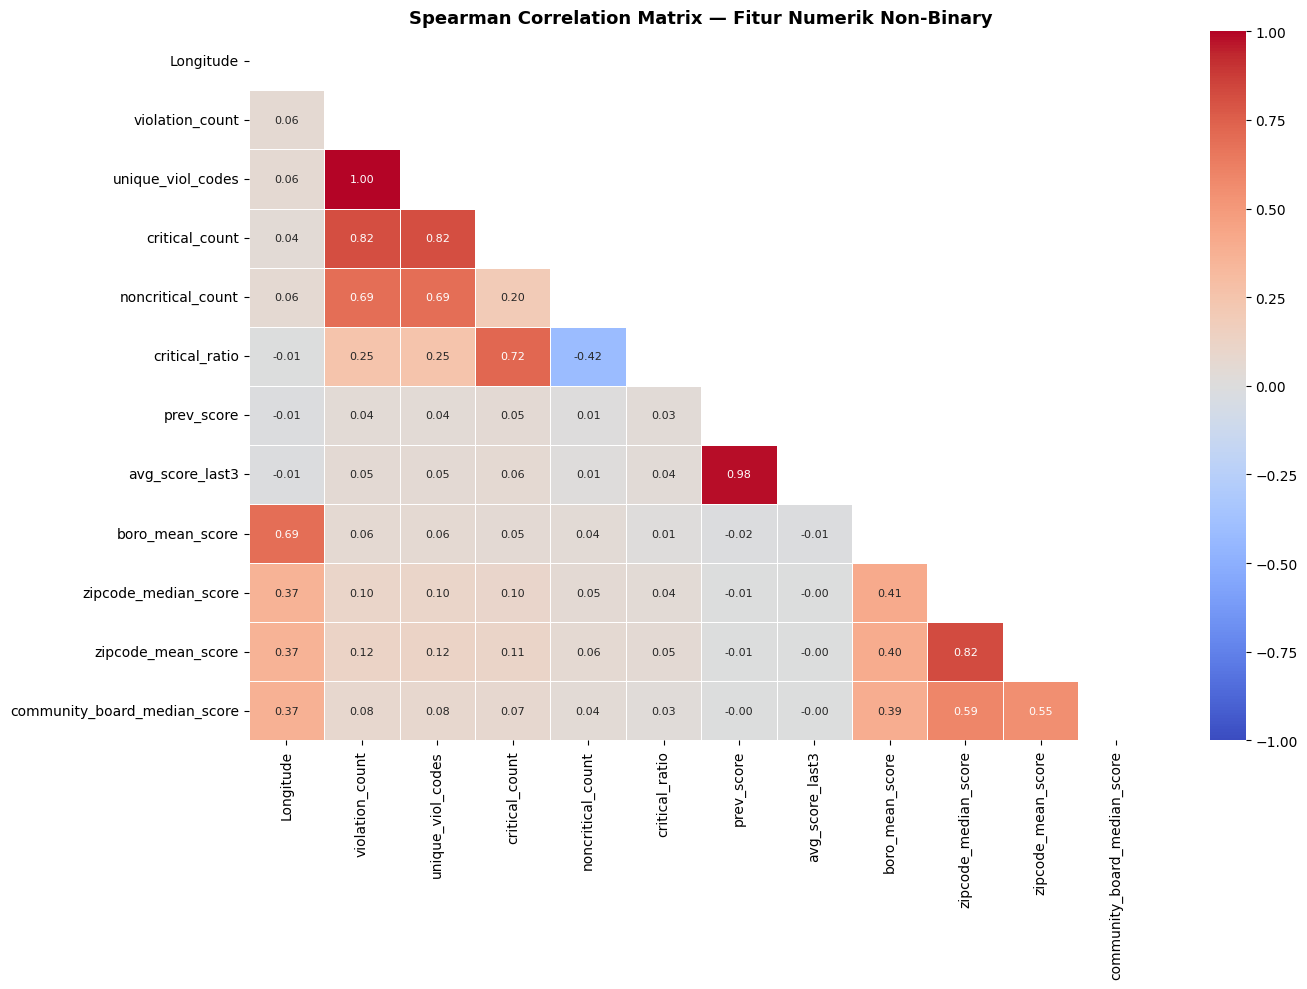

  VIF — Variance Inflation Factor
                     feature        VIF           status
             violation_count        inf   🔴 Tinggi (>10)
           unique_viol_codes        inf   🔴 Tinggi (>10)
             avg_score_last3 234.350361   🔴 Tinggi (>10)
                  prev_score 234.303073   🔴 Tinggi (>10)
              critical_count  13.224771   🔴 Tinggi (>10)
           noncritical_count   8.281899 🟠 Moderat (5-10)
              critical_ratio   5.453991 🟠 Moderat (5-10)
          zipcode_mean_score   4.669839      ✅ Aman (<5)
        zipcode_median_score   4.574282      ✅ Aman (<5)
             boro_mean_score   2.046614      ✅ Aman (<5)
                   Longitude   1.855732      ✅ Aman (<5)
community_board_median_score   1.445947      ✅ Aman (<5)

🔴 Fitur VIF > 10 : 5
🟠 Fitur VIF 5-10 : 2
✅ Fitur VIF < 5  : 5


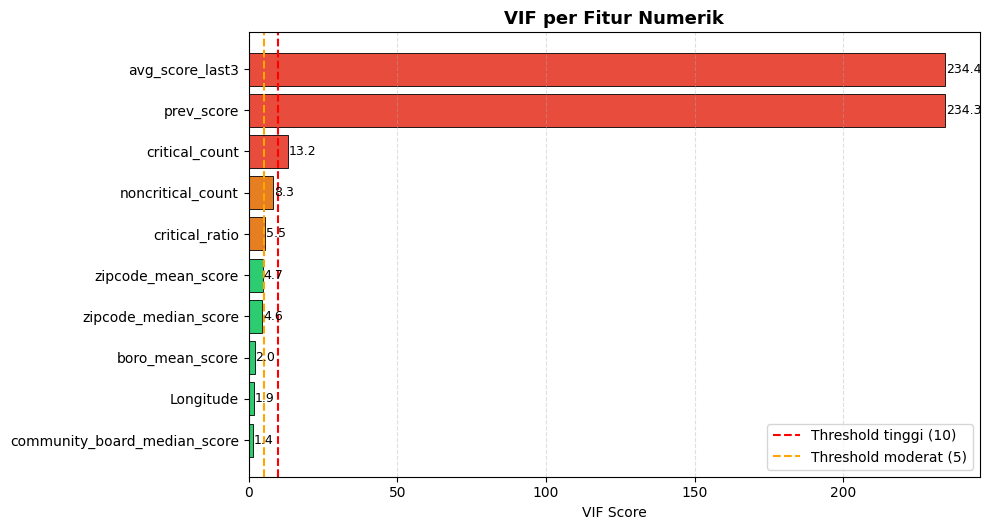

In [285]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

num_only = [c for c in X_train.columns
            if not any(c.startswith(p) for p in ["cuisine_", "instype_", "viol_"])
            and c != "has_critical"]

corr_matrix = X_train[num_only].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Spearman Correlation Matrix — Fitur Numerik Non-Binary",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

X_vif = X_train[num_only].copy().dropna()

X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i + 1)
            for i in range(len(X_vif.columns))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["status"] = vif_data["VIF"].apply(
    lambda v: "🔴 Tinggi (>10)"   if v > 10
    else      "🟠 Moderat (5-10)" if v > 5
    else      "✅ Aman (<5)"
)

print("=" * 50)
print("  VIF — Variance Inflation Factor")
print("=" * 50)
print(vif_data.to_string(index=False))
print(f"\n🔴 Fitur VIF > 10 : {(vif_data['VIF'] > 10).sum()}")
print(f"🟠 Fitur VIF 5-10 : {((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()}")
print(f"✅ Fitur VIF < 5  : {(vif_data['VIF'] <= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, max(5, len(vif_data) * 0.45)))

colors = ["#e74c3c" if v > 10 else "#e67e22" if v > 5 else "#2ecc71"
          for v in vif_data["VIF"]]
bars = ax.barh(vif_data["feature"], vif_data["VIF"],
               color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(10, color="red",    linestyle="--", linewidth=1.5, label="Threshold tinggi (10)")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="Threshold moderat (5)")

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)

ax.set_title("VIF per Fitur Numerik", fontsize=13, fontweight="bold")
ax.set_xlabel("VIF Score")
ax.legend(); ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 5 - Apply Drop Fitur Lemah Berdasarkan Correlation Analysis ##

**Keputusan drop berdasarkan hasil korelasi:**

| Fitur | Alasan Drop |
|---|---|
| `inspection_month`, `inspection_quarter`, `inspection_year` | ρ < 0.04, tidak ada pola temporal signifikan |
| `inspection_dayofweek` | ρ = -0.066, lolos tipis tapi makna meragukan |
| `Latitude` | ρ = 0.016, sangat lemah — Longitude lebih diskriminatif |
| `BORO` | η² = 0.003 (Negligible) — sudah ter-capture di `boro_mean_score` |
| `boro_median_score` | ρ = 0.042, di bawah threshold — pakai `boro_mean_score` saja |
| `prev_critical_count` | ρ = 0.038, redundan dengan `critical_count` saat ini |
| `n_prev_inspections` | ρ = -0.023, tidak prediktif |
| `days_since_last_inspection` | ρ = 0.045, borderline dan tidak informatif |
| `viol_10F` | ρ = -0.031, frekuensi tinggi di EDA tapi tidak diskriminatif untuk score |
| `ever_had_critical` | Boolean lemah, sudah di-cover oleh `has_critical` & `critical_count` |


In [198]:
cols_to_drop = [
    "inspection_month",
    "inspection_quarter",
    "inspection_year",
    "inspection_dayofweek",
    "Latitude",
    "boro_median_score",
    "BORO",
    "prev_critical_count",
    "n_prev_inspections",
    "days_since_last_inspection",
    "ever_had_critical",
    "viol_10F",
]

cols_to_drop_exist = [c for c in cols_to_drop if c in df_base.columns]
cols_not_found     = [c for c in cols_to_drop if c not in df_base.columns]

df_base = df_base.drop(columns=cols_to_drop_exist)

print(f"Kolom di-drop ({len(cols_to_drop_exist)}): {cols_to_drop_exist}")
if cols_not_found:
    print(f"Tidak ditemukan (skip): {cols_not_found}")
print(f"\nShape df_base setelah drop: {df_base.shape}")
print(f"\nKolom tersisa ({len(df_base.columns)}):")
print(df_base.columns.tolist())


Kolom di-drop (12): ['inspection_month', 'inspection_quarter', 'inspection_year', 'inspection_dayofweek', 'Latitude', 'boro_median_score', 'BORO', 'prev_critical_count', 'n_prev_inspections', 'days_since_last_inspection', 'ever_had_critical', 'viol_10F']

Shape df_base setelah drop: (68860, 32)

Kolom tersisa (32):
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'ZIPCODE', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score']


## Step 6 - Advanced Preprocessing: Encoding Variabel Kategorikal ##

**Strategi encoding berdasarkan hasil korelasi:**

| Fitur | Strategi | Alasan |
|---|---|---|
| `CUISINE_DESCRIPTION` | **One-Hot Encoding** | 16 kategori (top 15 + Other), η²=0.024 |
| `INSPECTION TYPE` | **One-Hot Encoding** | 6 kategori (top 5 + Other), η²=0.021 |
| `ZIPCODE` | **Drop raw** → sudah ada `zipcode_mean_score` & `zipcode_median_score` | Ratusan kategori, encoding numeriknya lebih informatif |
| `Community_Board` | **Drop raw** → sudah ada `community_board_median_score` | Sama seperti ZIPCODE |

**Catatan:** `CAMIS` dan `INSPECTION DATE` adalah identifier — tidak ikut di-encode, di-drop sebelum modeling.


In [199]:
ohe_cols = ["CUISINE_DESCRIPTION", "INSPECTION TYPE"]

df_encoded = pd.get_dummies(
    df_base,
    columns=ohe_cols,
    prefix={"CUISINE_DESCRIPTION": "cuisine", "INSPECTION TYPE": "instype"},
    drop_first=False,   
    dtype=int           
)

print(f"Shape sebelum OHE: {df_base.shape}")
print(f"Shape setelah OHE: {df_encoded.shape}")
print(f"Kolom baru dari OHE ({df_encoded.shape[1] - df_base.shape[1]}):")
new_ohe_cols = [c for c in df_encoded.columns if c.startswith("cuisine_") or c.startswith("instype_")]
print(new_ohe_cols)

Shape sebelum OHE: (68860, 32)
Shape setelah OHE: (68860, 52)
Kolom baru dari OHE (20):
['cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [200]:
raw_cat_to_drop = ["ZIPCODE", "Community_Board"]
id_cols         = ["CAMIS", "INSPECTION DATE"]

df_ids = df_encoded[id_cols].copy()

df_encoded = df_encoded.drop(
    columns=[c for c in raw_cat_to_drop + id_cols if c in df_encoded.columns]
)

print(f"Shape df_encoded setelah drop kolom raw: {df_encoded.shape}")
print()
print("Kolom final df_encoded:")
print(df_encoded.columns.tolist())

Shape df_encoded setelah drop kolom raw: (68860, 48)

Kolom final df_encoded:
['SCORE', 'Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Oth

In [201]:
df_encoded["has_critical"] = df_encoded["has_critical"].astype(int)

non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()

if non_numeric:
    print(f"Masih ada kolom non-numerik: {non_numeric}")
    print("Perlu ditangani sebelum modeling!")
else:
    print("Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling")

print(f"\nShape final: {df_encoded.shape}")
print(f"Missing values total: {df_encoded.isna().sum().sum()}")
print()
print("=== Dtypes summary ===")
print(df_encoded.dtypes.value_counts())
print()
print("=== Preview 5 baris pertama ===")
df_encoded.head()

Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling

Shape final: (68860, 48)
Missing values total: 0

=== Dtypes summary ===
float64    25
int64      23
Name: count, dtype: int64

=== Preview 5 baris pertama ===


,SCORE,Longitude,violation_count,unique_viol_codes,critical_count,noncritical_count,has_critical,critical_ratio,viol_02B,viol_02G,viol_04A,viol_04L,viol_04N,viol_05F,viol_06C,viol_06D,viol_06E,viol_08A,viol_09C,viol_10B,prev_score,avg_score_last3,boro_mean_score,zipcode_median_score,zipcode_mean_score,community_board_median_score,cuisine_American,cuisine_Bakery Products/Desserts,cuisine_Caribbean,cuisine_Chicken,cuisine_Chinese,cuisine_Coffee/Tea,cuisine_Donuts,cuisine_Hamburgers,cuisine_Italian,cuisine_Japanese,"cuisine_Juice, Smoothies, Fruit Salads",cuisine_Latin American,cuisine_Mexican,cuisine_Other,cuisine_Pizza,cuisine_Spanish,instype_Cycle Inspection / Initial Inspection,instype_Cycle Inspection / Re-inspection,instype_Cycle Inspection / Reopening Inspection,instype_Other,instype_Pre-permit (Operational) / Initial Inspection,instype_Pre-permit (Operational) / Re-inspection
0,38.0,-73.855972,3.0,3.0,2.0,1.0,1,0.666667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.000000,13.000000,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,12.0,-73.855972,3.0,3.0,1.0,2.0,1,0.333333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.663562,3.663562,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,10.0,-73.855972,3.0,3.0,1.0,2.0,1,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.564949,3.258097,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,7.0,-73.855972,2.0,2.0,1.0,1.0,1,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.397895,3.044522,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,10.0,-73.984310,2.0,2.0,2.0,0.0,1,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,13.000000,13.000000,17.384430,12.0,16.972575,12.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [202]:
from scipy.stats.mstats import winsorize

cols_to_winsorize = [
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio"
]

for col in cols_to_winsorize:
    upper = df_encoded[col].quantile(0.99)
    df_encoded[col] = df_encoded[col].clip(upper=upper)
    print(f"{col:<25} capped at P99 = {upper:.2f}")

print("\nWinsorize fitur numerik selesai")

violation_count           capped at P99 = 10.00
critical_count            capped at P99 = 7.00
noncritical_count         capped at P99 = 4.00
unique_viol_codes         capped at P99 = 10.00
critical_ratio            capped at P99 = 1.00

Winsorize fitur numerik selesai


In [203]:
skew_df = (
    df_encoded[[c for c in df_encoded.columns
                if not any(c.startswith(p) for p in 
                          ["cuisine_", "instype_", "viol_"])
                and c not in ["has_critical", "SCORE"]]]
    .skew()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "abs_skewness"})
)

skew_df["perlu_log"] = skew_df["abs_skewness"] > 1.0  

print(skew_df.to_string(index=False))

                     feature  abs_skewness  perlu_log
        zipcode_median_score      2.384295       True
community_board_median_score      2.261785       True
              critical_count      1.120576       True
             violation_count      1.030928       True
           unique_viol_codes      1.030928       True
             boro_mean_score      0.784905      False
           noncritical_count      0.544258      False
             avg_score_last3      0.401437      False
                  prev_score      0.384908      False
                   Longitude      0.206318      False
          zipcode_mean_score      0.149565      False
              critical_ratio      0.129132      False


In [204]:
for col in ["critical_count", "violation_count", "unique_viol_codes"]:
    df_encoded[col] = np.log1p(df_encoded[col])
    print(f"{col} → log1p applied")

critical_count → log1p applied
violation_count → log1p applied
unique_viol_codes → log1p applied


Total fitur masuk modeling: 47
Fitur dengan |ρ| ≥ 0.05: 33
Fitur dengan |ρ| < 0.05: 14



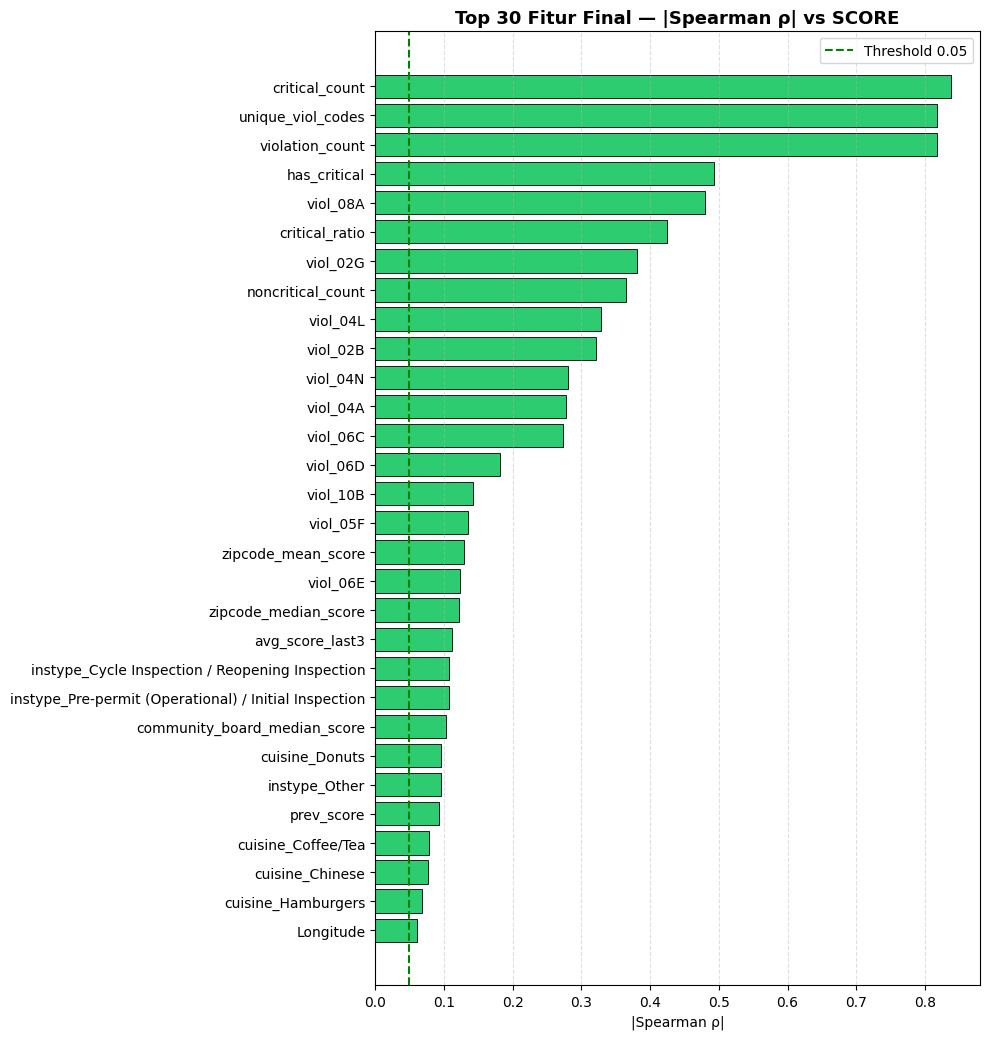


=== Top 10 fitur paling prediktif ===
          feature  abs_spearman_rho
   critical_count          0.838132
unique_viol_codes          0.817547
  violation_count          0.817547
     has_critical          0.492786
         viol_08A          0.479486
   critical_ratio          0.424459
         viol_02G          0.380793
noncritical_count          0.364986
         viol_04L          0.328939
         viol_02B          0.320815


In [205]:
final_corr = (
    df_encoded.corr(method="spearman")["SCORE"]
    .drop("SCORE")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "SCORE": "abs_spearman_rho"})
)

print(f"Total fitur masuk modeling: {len(final_corr)}")
print(f"Fitur dengan |ρ| ≥ 0.05: {(final_corr['abs_spearman_rho'] >= 0.05).sum()}")
print(f"Fitur dengan |ρ| < 0.05: {(final_corr['abs_spearman_rho'] < 0.05).sum()}")
print()

top_n = min(30, len(final_corr))
plot_df = final_corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
colors = ["#2ecc71" if v >= 0.05 else "#e74c3c" for v in plot_df["abs_spearman_rho"]]
ax.barh(plot_df["feature"], plot_df["abs_spearman_rho"],
        color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0.05, color="green", linestyle="--", linewidth=1.5, label="Threshold 0.05")
ax.set_title(f"Top {top_n} Fitur Final — |Spearman ρ| vs SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("|Spearman ρ|")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 fitur paling prediktif ===")
print(final_corr.head(10).to_string(index=False))

## Step 7 - Advanced Preprocessing: Handling Outlier pada SCORE ##

**Konteks dari EDA:**
- Distribusi SCORE **right-skewed** — mayoritas score berkumpul di 0–25, ada ekor panjang ke kanan
- Outlier score tinggi tetap **informatif** — bukan noise, melainkan inspeksi berisiko tinggi

**Strategi: Winsorize dulu → lalu Log1p Transform**

| Teknik | Fungsi | Urutan |
|---|---|---|
| **Winsorize (P99)** | Potong nilai ekstrem agar tidak mendominasi log scale | 1️⃣ |
| **Log1p Transform** | Perbaiki right-skewness distribusi → mendekati normal | 2️⃣ |

Mengapa log1p dan bukan log biasa? Karena SCORE bisa bernilai **0** → `log(0) = -inf`.
`log1p(x) = log(x + 1)` aman untuk nilai 0.

⚠️ **Konsekuensi:** Prediksi model akan dalam skala log → saat evaluasi dan interpretasi,
hasil prediksi harus dikembalikan ke skala asli dengan `np.expm1(y_pred)`.


=== Statistik SCORE (sebelum handling) ===
Min    : 0.0
Q1     : 9.0
Median : 13.0
Mean   : 18.12
Q3     : 24.0
P95    : 47.0
P99    : 73.0
Max    : 203.0
Skewness: 2.209

Outlier (IQR): 3,628 baris (5.3%)
Outlier ekstrem (>P99=73.0): 654 baris


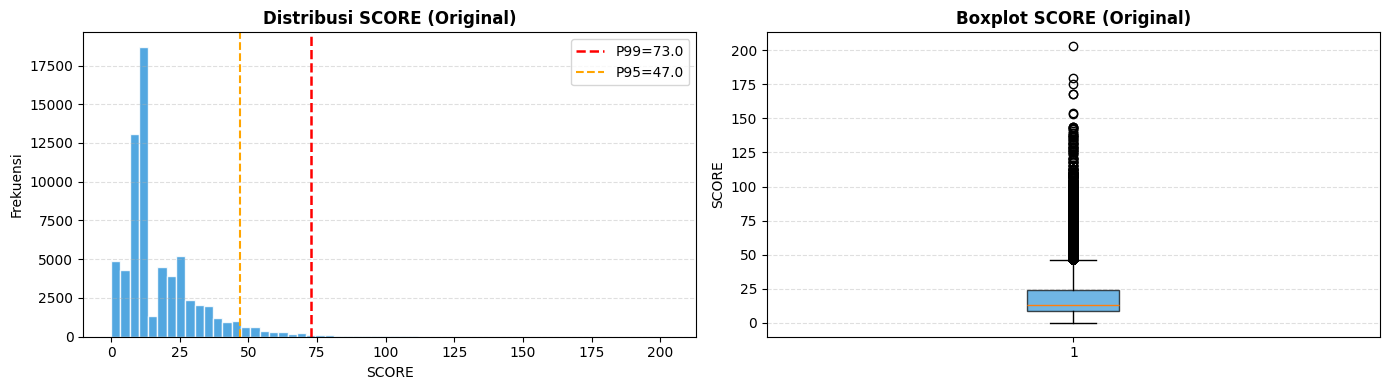

In [206]:
score = df_encoded["SCORE"]

q1  = score.quantile(0.25)
q3  = score.quantile(0.75)
iqr = q3 - q1
p99 = score.quantile(0.99)
p95 = score.quantile(0.95)

print("=== Statistik SCORE (sebelum handling) ===")
print(f"Min    : {score.min():.1f}")
print(f"Q1     : {q1:.1f}")
print(f"Median : {score.median():.1f}")
print(f"Mean   : {score.mean():.2f}")
print(f"Q3     : {q3:.1f}")
print(f"P95    : {p95:.1f}")
print(f"P99    : {p99:.1f}")
print(f"Max    : {score.max():.1f}")
print(f"Skewness: {score.skew():.3f}")
print(f"\nOutlier (IQR): {(score > q3 + 1.5*iqr).sum():,} baris ({(score > q3 + 1.5*iqr).mean()*100:.1f}%)")
print(f"Outlier ekstrem (>P99={p99:.1f}): {(score > p99).sum():,} baris")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(score, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(p99, color="red",    linestyle="--", linewidth=1.8, label=f"P99={p99:.1f}")
axes[0].axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95={p95:.1f}")
axes[0].set_title("Distribusi SCORE (Original)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SCORE"); axes[0].set_ylabel("Frekuensi")
axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].boxplot(score, vert=True, patch_artist=True, boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Boxplot SCORE (Original)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("SCORE"); axes[1].grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [207]:
CAP_PERCENTILE = 0.99
score_cap = df_encoded["SCORE"].quantile(CAP_PERCENTILE)
df_encoded["SCORE"] = df_encoded["SCORE"].clip(upper=score_cap)

print(f"[Winsorize] Cap di P99 = {score_cap:.1f}")
print(f"Baris yang di-cap: {(df_encoded['SCORE'] == score_cap).sum():,}")
print(f"Skewness setelah winsorize: {df_encoded['SCORE'].skew():.3f}")
print()


df_encoded["SCORE"] = np.log1p(df_encoded["SCORE"])

print(f"[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)")
print(f"Skewness setelah log1p      : {df_encoded['SCORE'].skew():.3f}")
print(f"Range SCORE sekarang        : [{df_encoded['SCORE'].min():.3f}, {df_encoded['SCORE'].max():.3f}]")
print()


[Winsorize] Cap di P99 = 73.0
Baris yang di-cap: 700
Skewness setelah winsorize: 1.621

[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)
Skewness setelah log1p      : -0.714
Range SCORE sekarang        : [0.000, 4.304]



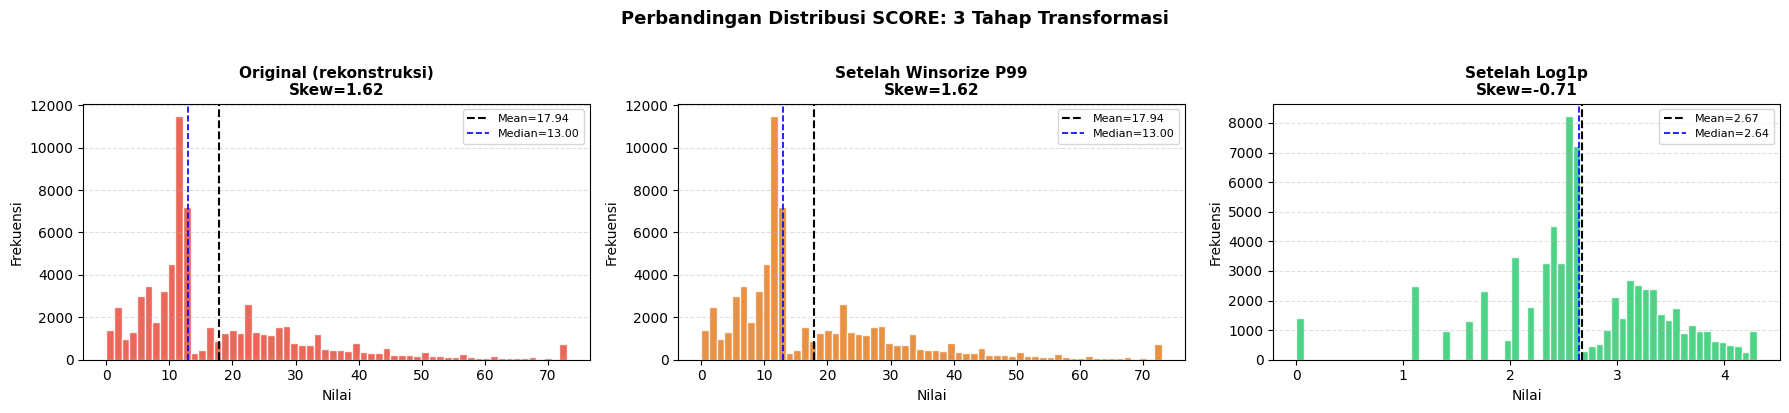

In [208]:
score_original  = df_encoded["SCORE"].apply(np.expm1).clip(upper=score_cap)  
score_winsorize = score_original 
score_log1p     = df_encoded["SCORE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

data_stages = [
    (df_encoded["SCORE"].apply(np.expm1), "Original (rekonstruksi)", "#e74c3c"),
    (score_winsorize,                      f"Setelah Winsorize P99",   "#e67e22"),
    (score_log1p,                          "Setelah Log1p",            "#2ecc71"),
]

for ax, (data, title, color) in zip(axes, data_stages):
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="blue",   linestyle="--", linewidth=1.2,
               label=f"Median={data.median():.2f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Nilai"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_title(f"{title}\nSkew={data.skew():.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Perbandingan Distribusi SCORE: 3 Tahap Transformasi",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 8 - Advanced Preprocessing: Train-Test Split (Temporal) ##

**Mengapa 3-Way Temporal Split (Train / Validation / Test)?**

| Set | Proporsi | Fungsi |
|---|---|---|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Tuning hyperparameter, pilih model terbaik |
| **Test** | 15% | Evaluasi final — **hanya disentuh sekali di akhir** |

Kalau hanya pakai train/test dan tuning dilakukan berdasarkan test set → test set "bocor" ke proses
training secara tidak langsung → hasil evaluasi **overly optimistic**, tidak mencerminkan performa di data baru.

Split tetap **temporal** dan berurutan karena data ini time-series inspeksi:
```
[────── Train (70%) ──────────][── Val (15%) ──][── Test (15%) ──]
 terlama                                                  terbaru
```

⚠️  **Target encoding di-refit dari train saja**, lalu di-apply ke val dan test.


In [209]:
df_split = df_encoded.copy()
df_split["INSPECTION DATE"] = pd.to_datetime(df_ids["INSPECTION DATE"].values)
df_split["CAMIS"]           = df_ids["CAMIS"].values
df_split = df_split.sort_values("INSPECTION DATE").reset_index(drop=True)

n = len(df_split)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_split.iloc[:train_end].copy()
val_df   = df_split.iloc[train_end:val_end].copy()
test_df  = df_split.iloc[val_end:].copy()

print(f"Total data       : {n:,}")
print(f"\nTrain  : {len(train_df):,} baris ({len(train_df)/n*100:.1f}%)")
print(f"  Periode: {train_df['INSPECTION DATE'].min().date()} → {train_df['INSPECTION DATE'].max().date()}")
print(f"\nVal    : {len(val_df):,} baris ({len(val_df)/n*100:.1f}%)")
print(f"  Periode: {val_df['INSPECTION DATE'].min().date()} → {val_df['INSPECTION DATE'].max().date()}")
print(f"\nTest   : {len(test_df):,} baris ({len(test_df)/n*100:.1f}%)")
print(f"  Periode: {test_df['INSPECTION DATE'].min().date()} → {test_df['INSPECTION DATE'].max().date()}")

Total data       : 68,860

Train  : 48,202 baris (70.0%)
  Periode: 2023-03-03 → 2025-05-09

Val    : 10,329 baris (15.0%)
  Periode: 2025-05-09 → 2025-10-07

Test   : 10,329 baris (15.0%)
  Periode: 2025-10-07 → 2026-02-28


In [210]:
te_map = {
    "zipcode_mean_score":            ("ZIPCODE",         "mean"),
    "zipcode_median_score":          ("ZIPCODE",         "median"),
    "boro_mean_score":               ("BORO",            "mean"),
    "community_board_median_score":  ("Community_Board", "median"),
}

camis_geo = (
    df_ins[["CAMIS", "ZIPCODE", "BORO", "Community_Board"]]
    .copy()
    .astype(str)
    .replace("nan", pd.NA)        
    .dropna(subset=["CAMIS"])     
    .groupby("CAMIS", as_index=False)
    .first()                    
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

for geo_col in ["ZIPCODE", "BORO", "Community_Board"]:
    camis_to_geo = camis_geo.set_index("CAMIS")[geo_col]
    for df_ in [train_df, val_df, test_df]:
        df_[geo_col] = df_["CAMIS"].map(camis_to_geo)

global_median_train = train_df["SCORE"].median()

for new_col, (geo_col, agg_fn) in te_map.items():
    if new_col not in train_df.columns:
        continue
    stats_dict = (
        train_df.dropna(subset=[geo_col])
        .groupby(geo_col)["SCORE"]
        .agg(agg_fn)
        .to_dict()
    )
    for df_ in [train_df, val_df, test_df]:
        df_[new_col] = df_[geo_col].map(stats_dict).fillna(global_median_train)

geo_temp_cols = ["ZIPCODE", "BORO", "Community_Board"]
for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=geo_temp_cols, errors="ignore", inplace=True)

print("\u2705 Target encoding di-refit dari train set saja, applied ke val & test")
print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")


✅ Target encoding di-refit dari train set saja, applied ke val & test

Train: (48202, 50) | Val: (10329, 50) | Test: (10329, 50)


In [211]:
drop_final = ["INSPECTION DATE", "CAMIS"]

X_train = train_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_train = train_df["SCORE"]

X_val   = val_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_val   = val_df["SCORE"]

X_test  = test_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_test  = test_df["SCORE"]

print("=" * 55)
print("  HASIL AKHIR PREPROCESSING")
print("=" * 55)
print(f"X_train : {X_train.shape}  | y mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"X_val   : {X_val.shape}   | y mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"X_test  : {X_test.shape}   | y mean={y_test.mean():.3f}, std={y_test.std():.3f}")
print(f"\nJumlah fitur masuk modeling: {X_train.shape[1]}")
print(f"\ny dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli")
print(f"\nFeature list:")
print(X_train.columns.tolist())


  HASIL AKHIR PREPROCESSING
X_train : (48202, 47)  | y mean=2.667, std=0.769
X_val   : (10329, 47)   | y mean=2.673, std=0.878
X_test  : (10329, 47)   | y mean=2.704, std=0.760

Jumlah fitur masuk modeling: 47

y dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli

Feature list:
['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican

## Step 9 - Advanced Preprocessing: Feature Scaling ##

**Strategi Scaling:**

| Kolom | Scaler | Alasan |
|---|---|---|
| `SCORE` (target) | **Tidak di-scale** | Target regresi dibiarkan asli agar prediksi tetap interpretable |
| Fitur numerik kontinyu (score historis, koordinat, dll) | **RobustScaler** | Tahan terhadap outlier — menggunakan median & IQR bukan mean & std |
| Fitur count (violation_count, critical_count, dll) | **RobustScaler** | Distribusinya skewed, RobustScaler lebih aman |
| Fitur binary OHE (`cuisine_*`, `instype_*`, `viol_*`, `has_critical`) | **Tidak di-scale** | Sudah 0/1, scaling justru merusak interpretasi |

**Mengapa RobustScaler bukan StandardScaler?**
SCORE dan violation features punya outlier signifikan. StandardScaler akan terpengaruh mean & std yang terdistorsi outlier, sehingga fitur normal jadi ter-compress. RobustScaler memakai median & IQR sehingga lebih stabil.


In [212]:
from sklearn.preprocessing import RobustScaler

binary_cols = (
    [c for c in X_train.columns if c.startswith("cuisine_")]
    + [c for c in X_train.columns if c.startswith("instype_")]
    + [c for c in X_train.columns if c.startswith("viol_")]
    + ["has_critical"]
)
binary_cols = [c for c in binary_cols if c in X_train.columns]

scale_cols = [
    c for c in X_train.select_dtypes(include="number").columns
    if c not in binary_cols
]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])   
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])          
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])         

print(f"✅ RobustScaler di-fit dari train, applied ke val & test")
print(f"Kolom di-scale ({len(scale_cols)}): {scale_cols}")

✅ RobustScaler di-fit dari train, applied ke val & test
Kolom di-scale (12): ['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'critical_ratio', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score']


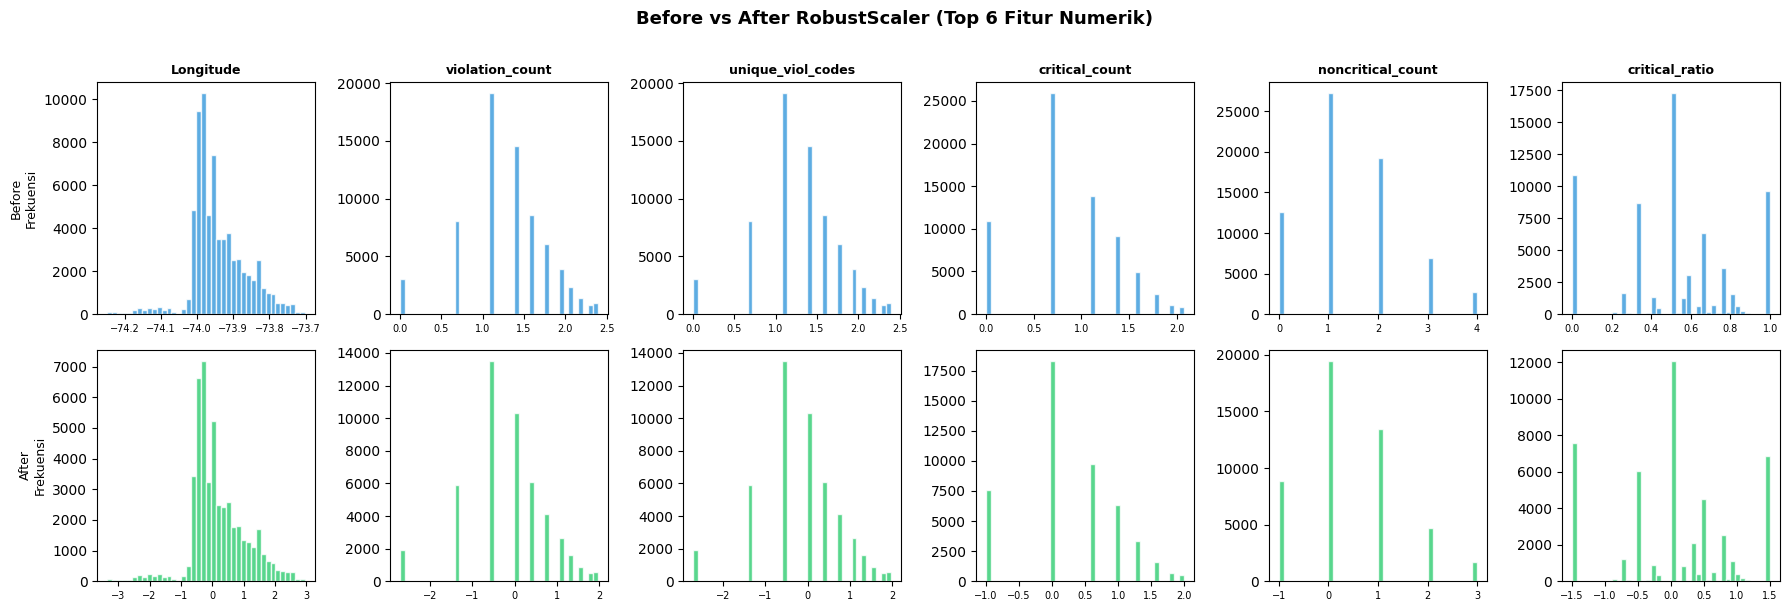

In [213]:
top6_scale = [c for c in X_train.columns if c in scale_cols][:6]

df_before = df_encoded[top6_scale].copy()

fig, axes = plt.subplots(2, len(top6_scale), figsize=(18, 6))

for i, col in enumerate(top6_scale):
    axes[0, i].hist(df_before[col].dropna(), bins=40,
                    color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col, fontsize=9, fontweight="bold")
    axes[0, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[0, i].set_ylabel("Before\nFrekuensi", fontsize=9)

    axes[1, i].hist(X_train[col].dropna(), bins=40,
                    color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[1, i].set_ylabel("After\nFrekuensi", fontsize=9)

plt.suptitle("Before vs After RobustScaler (Top 6 Fitur Numerik)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

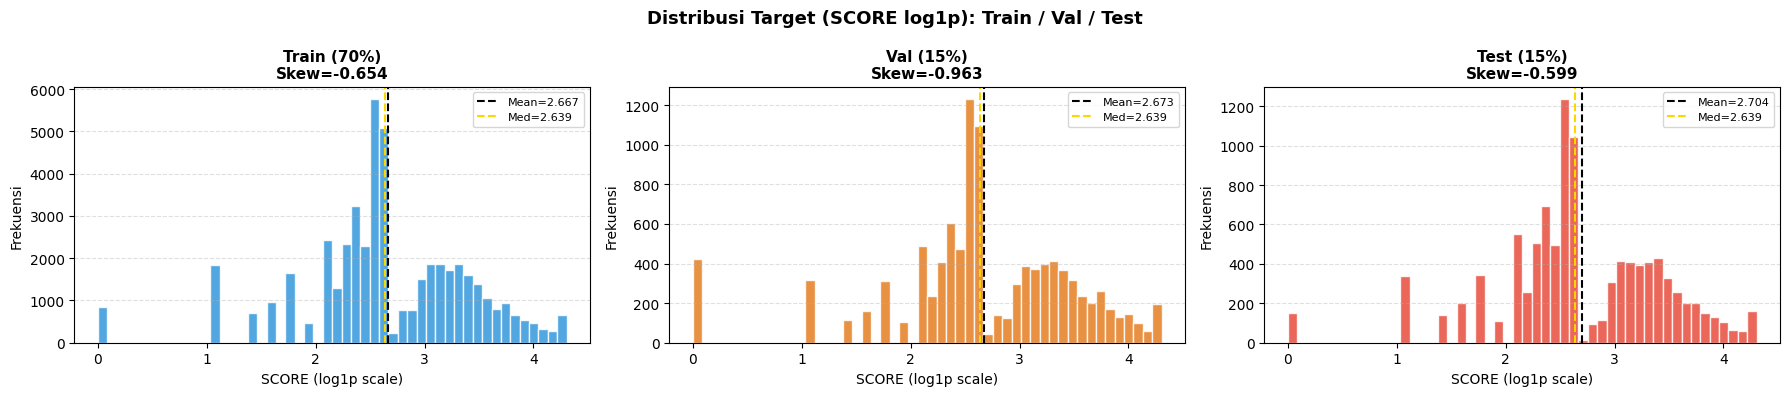

Cek: distribusi ketiga set harus mirip
Train skewness : -0.654
Val   skewness : -0.963
Test  skewness : -0.599


In [214]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sets = [
    (y_train, "Train (70%)",  "#3498db"),
    (y_val,   "Val (15%)",    "#e67e22"),
    (y_test,  "Test (15%)",   "#e74c3c"),
]

for ax, (data, label, color) in zip(axes, sets):
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gold",  linestyle="--", linewidth=1.5,
               label=f"Med={data.median():.3f}")
    ax.set_title(f"{label}\nSkew={data.skew():.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("SCORE (log1p scale)"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Target (SCORE log1p): Train / Val / Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Cek: distribusi ketiga set harus mirip")
print(f"Train skewness : {y_train.skew():.3f}")
print(f"Val   skewness : {y_val.skew():.3f}")
print(f"Test  skewness : {y_test.skew():.3f}")


# Modeling ##

**Roadmap Modeling:**

| Tahap | Model | Tujuan |
|---|---|---|
| **1** | Ridge, Lasso, ElasticNet | Atasi overfitting Linear Regression, feature selection implisit |
| **2** | Random Forest, XGBoost, LightGBM | Model non-linear yang lebih powerful untuk data tabular |
| **3** | Perbandingan semua model | Pilih model terbaik berdasarkan Val R² dan gap overfitting |

**Metrik Evaluasi:**
- **RMSE** (log1p scale) — sensitif terhadap error besar
- **MAE** (log1p scale) — lebih robust terhadap outlier
- **R²** — proporsi variansi yang dijelaskan model
- **Gap Train-Val R²** — indikator overfitting (target ≤ 0.05)

⚠️ Semua tuning dilakukan terhadap **Val set**. **Test set hanya digunakan di akhir.**


In [215]:
import re

def clean_col_name(col):
    return re.sub(r'[^A-Za-z0-9_]', '_', col)

X_train.columns = [clean_col_name(c) for c in X_train.columns]
X_val.columns   = [clean_col_name(c) for c in X_val.columns]
X_test.columns  = [clean_col_name(c) for c in X_test.columns]

print("✅ Nama kolom dibersihkan — semua model akan pakai nama kolom yang sama")
print(X_train.columns.tolist())

✅ Nama kolom dibersihkan — semua model akan pakai nama kolom yang sama
['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'cuisine_American', 'cuisine_Bakery_Products_Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee_Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice__Smoothies__Fruit_Salads', 'cuisine_Latin_American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle_Inspection___Initial_Inspection', 'instype_Cycle_Inspection___Re_inspection', 'instype_Cycle_Inspection___Reopening_Inspection', 'instype_Other', 'instype_Pr

In [216]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

def evaluate(model, X_tr, y_tr, X_vl, y_vl, name):
    """Evaluasi model di train dan val, return dict hasil."""
    y_tr_pred = model.predict(X_tr)
    y_vl_pred = model.predict(X_vl)

    train_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    val_rmse   = np.sqrt(mean_squared_error(y_vl, y_vl_pred))
    train_r2   = r2_score(y_tr, y_tr_pred)
    val_r2     = r2_score(y_vl, y_vl_pred)

    train_mae_orig = mean_absolute_error(np.expm1(y_tr), np.expm1(y_tr_pred))
    val_mae_orig   = mean_absolute_error(np.expm1(y_vl), np.expm1(y_vl_pred))

    res = {
        "Model":      name,
        "Train RMSE": train_rmse,
        "Val RMSE":   val_rmse,
        "Train MAE":  train_mae_orig,   # skala SCORE asli
        "Val MAE":    val_mae_orig,     # skala SCORE asli
        "Train R²":   train_r2,
        "Val R²":     val_r2,
    }
    res["Gap R²"] = res["Train R²"] - res["Val R²"]

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Train RMSE : {train_rmse:.4f}  |  Val RMSE : {val_rmse:.4f}  (log1p scale)")
    print(f"  Train MAE  : {train_mae_orig:.4f}  |  Val MAE  : {val_mae_orig:.4f}  (skala SCORE asli)")
    print(f"  Train R²   : {train_r2:.4f}  |  Val R²   : {val_r2:.4f}")
    print(f"  Gap R²     : {res['Gap R²']:.4f}  {'✅' if res['Gap R²'] <= 0.05 else '⚠️  overfitting'}")
    return res

all_results = [] 
print("Helper dan library siap")


Helper dan library siap


## Step 1 — Regularized Linear Models (Ridge / Lasso / ElasticNet) ##

**Strategi tuning alpha:**
- `alpha` mengontrol kekuatan regularisasi — semakin besar, semakin model di-constrain
- Dicoba rentang dari sangat kecil (0.01) sampai besar (1000) dalam skala logaritmik
- Pilih `alpha` yang memberikan **Val R² tertinggi** dengan **gap terkecil**

| Model | Penalti | Efek |
|---|---|---|
| **Ridge** | L2 (kuadrat koefisien) | Shrink semua koefisien, tidak ada yang jadi 0 |
| **Lasso** | L1 (nilai absolut) | Beberapa koefisien jadi 0 → implicit feature selection |
| **ElasticNet** | L1 + L2 | Kombinasi keduanya, lebih stabil dari Lasso jika ada fitur berkorelasi |


In [217]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = np.logspace(-2, 4, 50) 

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="r2")
ridge_cv.fit(X_train, y_train)

print(f"Ridge — Best alpha: {ridge_cv.alpha_:.4f}")

ridge_best = Ridge(alpha=ridge_cv.alpha_)
ridge_best.fit(X_train, y_train)
res_ridge = evaluate(ridge_best, X_train, y_train, X_val, y_val, "Ridge")
all_results.append(res_ridge)

Ridge — Best alpha: 8.6851
  Ridge
  Train RMSE : 0.3629  |  Val RMSE : 0.5001  (log1p scale)
  Train MAE  : 3.4398  |  Val MAE  : 3.7886  (skala SCORE asli)
  Train R²   : 0.7772  |  Val R²   : 0.6756
  Gap R²     : 0.1016  ⚠️  overfitting


In [218]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)

print(f"Lasso — Best alpha: {lasso_cv.alpha_:.6f}")

n_zero = (np.abs(lasso_cv.coef_) < 1e-6).sum()
print(f"Fitur di-eliminasi Lasso: {n_zero} / {X_train.shape[1]}")
print(f"Fitur aktif             : {X_train.shape[1] - n_zero}")

lasso_best = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X_train, y_train)
res_lasso = evaluate(lasso_best, X_train, y_train, X_val, y_val, "Lasso")
all_results.append(res_lasso)

Lasso — Best alpha: 0.010000
Fitur di-eliminasi Lasso: 36 / 47
Fitur aktif             : 11
  Lasso
  Train RMSE : 0.3897  |  Val RMSE : 0.5035  (log1p scale)
  Train MAE  : 3.6529  |  Val MAE  : 4.0162  (skala SCORE asli)
  Train R²   : 0.7431  |  Val R²   : 0.6712
  Gap R²     : 0.0720  ⚠️  overfitting


In [219]:
enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],  
    cv=5,
    max_iter=10000,
    random_state=42
)
enet_cv.fit(X_train, y_train)

print(f"ElasticNet — Best alpha  : {enet_cv.alpha_:.6f}")
print(f"ElasticNet — Best l1_ratio: {enet_cv.l1_ratio_:.2f}")

enet_best = ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000)
enet_best.fit(X_train, y_train)
res_enet = evaluate(enet_best, X_train, y_train, X_val, y_val, "ElasticNet")
all_results.append(res_enet)


ElasticNet — Best alpha  : 0.010000
ElasticNet — Best l1_ratio: 0.10
  ElasticNet
  Train RMSE : 0.3738  |  Val RMSE : 0.4931  (log1p scale)
  Train MAE  : 3.4290  |  Val MAE  : 3.7706  (skala SCORE asli)
  Train R²   : 0.7636  |  Val R²   : 0.6846
  Gap R²     : 0.0790  ⚠️  overfitting


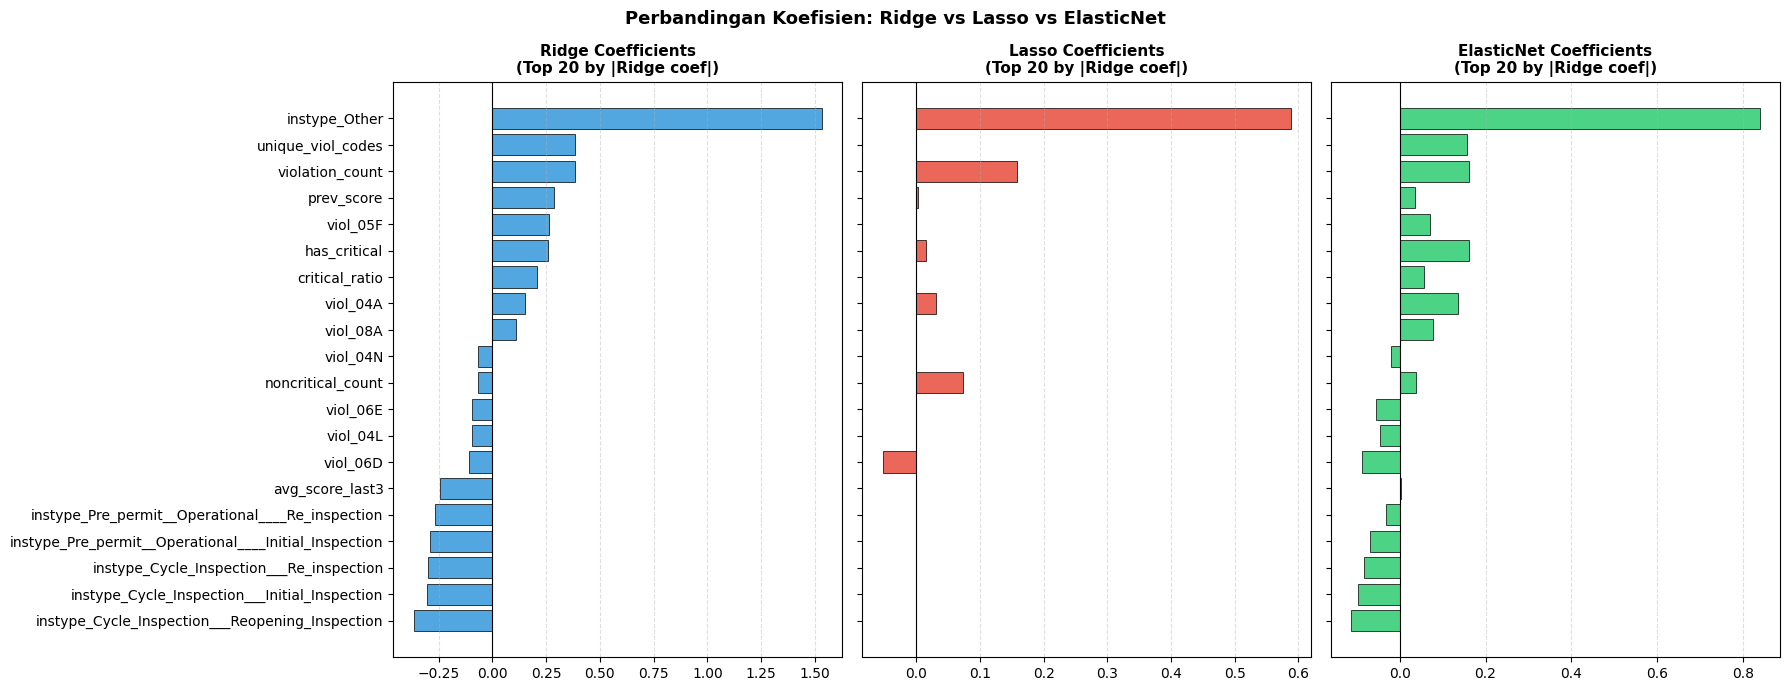

In [220]:
feat_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    "feature": feat_names,
    "Ridge":   ridge_best.coef_,
    "Lasso":   lasso_best.coef_,
    "ElasticNet": enet_best.coef_,
})

top20 = coef_df.reindex(coef_df["Ridge"].abs().nlargest(20).index)
top20 = top20.sort_values("Ridge")

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
for ax, col, color in zip(axes, ["Ridge", "Lasso", "ElasticNet"],
                           ["#3498db", "#e74c3c", "#2ecc71"]):
    bars = ax.barh(top20["feature"], top20[col], color=color,
                   edgecolor="black", linewidth=0.6, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{col} Coefficients\n(Top 20 by |Ridge coef|)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Perbandingan Koefisien: Ridge vs Lasso vs ElasticNet",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 2 — Tree-Based Models (Random Forest / XGBoost / LightGBM) ##

**Mengapa tree-based lebih cocok untuk data tabular ini?**
- Tidak asumsi linearitas — hubungan `critical_count` vs `SCORE` mungkin non-linear
- Otomatis menangani interaksi antar fitur (contoh: `critical_count` tinggi + `INSPECTION TYPE` tertentu)
- Lebih robust terhadap outlier dan skewness residual
- Tidak butuh scaling — fitur binary OHE dan numerik bisa masuk langsung

**Catatan:** Karena SCORE sudah di-log1p, tree model tetap dilatih di skala log1p. Konsisten dengan linear model.


In [221]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    max_features=0.6,      
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
res_rf = evaluate(rf, X_train, y_train, X_val, y_val, "Random Forest")
all_results.append(res_rf)


  Random Forest
  Train RMSE : 0.2692  |  Val RMSE : 0.3489  (log1p scale)
  Train MAE  : 2.5959  |  Val MAE  : 3.2227  (skala SCORE asli)
  Train R²   : 0.8774  |  Val R²   : 0.8421
  Gap R²     : 0.0353  ✅


In [222]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,          
    reg_lambda=1.0,         
    early_stopping_rounds=30,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f"XGBoost — Best iteration: {xgb_model.best_iteration}")
res_xgb = evaluate(xgb_model, X_train, y_train, X_val, y_val, "XGBoost")
all_results.append(res_xgb)


XGBoost — Best iteration: 145
  XGBoost
  Train RMSE : 0.2962  |  Val RMSE : 0.3484  (log1p scale)
  Train MAE  : 2.9155  |  Val MAE  : 3.1508  (skala SCORE asli)
  Train R²   : 0.8516  |  Val R²   : 0.8426
  Gap R²     : 0.0090  ✅


In [223]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
)
print(f"LightGBM — Best iteration: {lgb_model.best_iteration_}")
res_lgb = evaluate(lgb_model, X_train, y_train, X_val, y_val, "LightGBM")
all_results.append(res_lgb)


LightGBM — Best iteration: 180
  LightGBM
  Train RMSE : 0.2953  |  Val RMSE : 0.3459  (log1p scale)
  Train MAE  : 2.8875  |  Val MAE  : 3.1499  (skala SCORE asli)
  Train R²   : 0.8525  |  Val R²   : 0.8448
  Gap R²     : 0.0077  ✅


In [224]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,       
    subsample=0.8,
    colsample_bylevel=0.8,
    early_stopping_rounds=30,
    eval_metric="RMSE",
    random_seed=42,
    verbose=0              
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

print(f"CatBoost — Best iteration: {cat_model.get_best_iteration()}")
res_cat = evaluate(cat_model, X_train, y_train, X_val, y_val, "CatBoost")
all_results.append(res_cat)

CatBoost — Best iteration: 374
  CatBoost
  Train RMSE : 0.3059  |  Val RMSE : 0.3479  (log1p scale)
  Train MAE  : 2.9812  |  Val MAE  : 3.1562  (skala SCORE asli)
  Train R²   : 0.8417  |  Val R²   : 0.8430
  Gap R²     : -0.0013  ✅


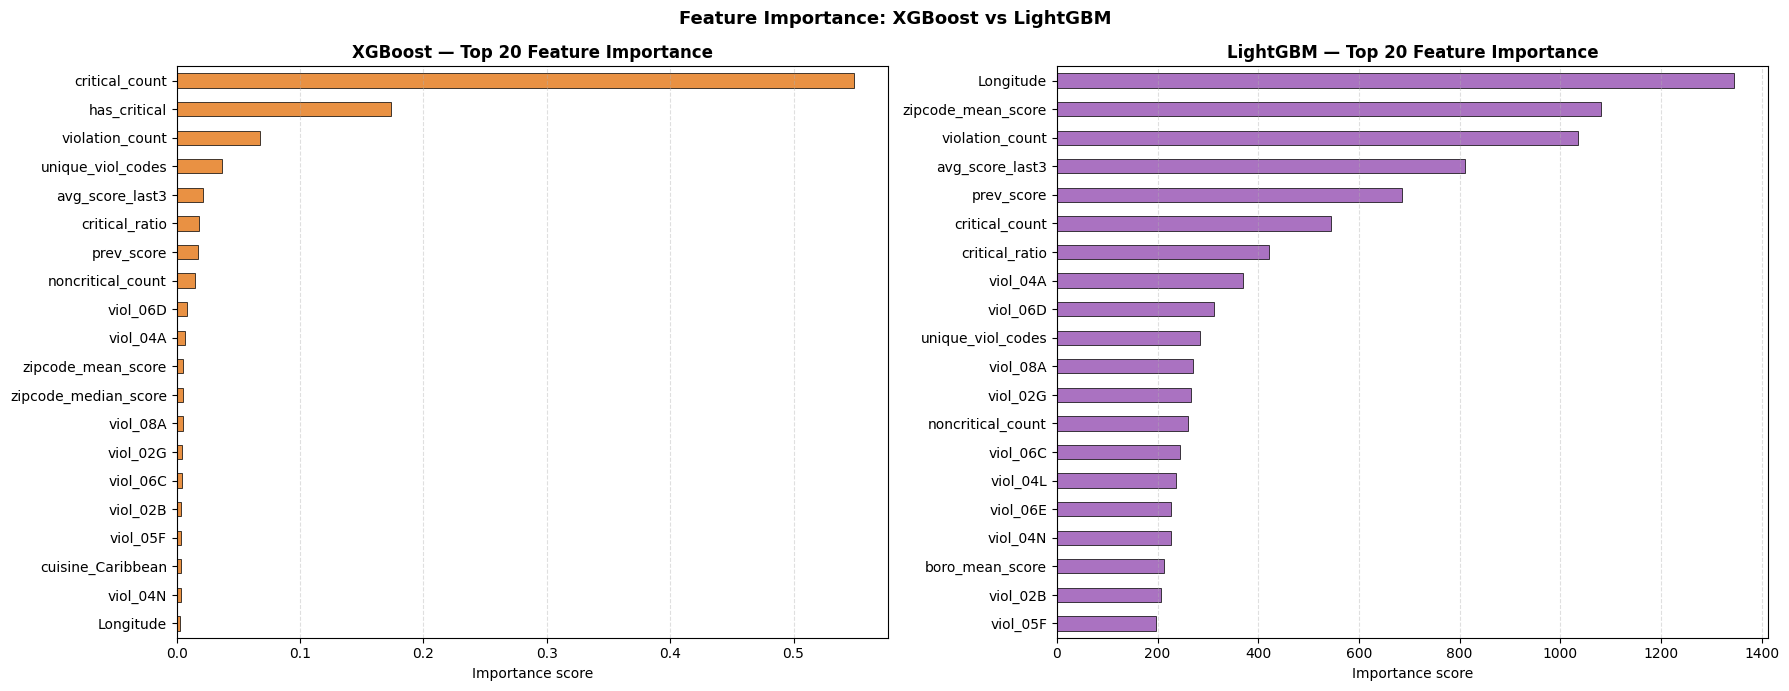

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, name, color in zip(
    axes,
    [xgb_model, lgb_model],
    ["XGBoost", "LightGBM"],
    ["#e67e22", "#9b59b6"]
):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top20_imp = importances.nlargest(20).sort_values()

    top20_imp.plot(kind="barh", ax=ax, color=color, edgecolor="black",
                   linewidth=0.6, alpha=0.85)
    ax.set_title(f"{name} — Top 20 Feature Importance",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_xlabel("Importance score")

plt.suptitle("Feature Importance: XGBoost vs LightGBM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 3 — Perbandingan Semua Model & Evaluasi Final di Test Set ##

In [259]:
df_results = pd.DataFrame(all_results).set_index("Model")
df_results = df_results.round(4).sort_values("Val MAE", ascending=True)

print("=" * 70)
print("  PERBANDINGAN SEMUA MODEL (diurutkan Val MAE)")
print("=" * 70)
print(df_results[["Train R²", "Val R²", "Gap R²", "Val RMSE", "Val MAE"]].to_string())

best_model_name = df_results["Val MAE"].idxmin()
print(f"\n🏆 Model terbaik di Val set: {best_model_name}")
print(f"   Val R²   : {df_results.loc[best_model_name, 'Val R²']:.4f}")
print(f"   Val RMSE : {df_results.loc[best_model_name, 'Val RMSE']:.4f}")
print(f"   Val MAE  : {df_results.loc[best_model_name, 'Val MAE']:.4f}")
print(f"   Gap R²   : {df_results.loc[best_model_name, 'Gap R²']:.4f}")


  PERBANDINGAN SEMUA MODEL (diurutkan Val MAE)
               Train R²  Val R²  Gap R²  Val RMSE  Val MAE
Model                                                     
LightGBM         0.8525  0.8448  0.0077    0.3459   3.1499
XGBoost          0.8516  0.8426  0.0090    0.3484   3.1508
CatBoost         0.8417  0.8430 -0.0013    0.3479   3.1562
Random Forest    0.8774  0.8421  0.0353    0.3489   3.2227
ElasticNet       0.7636  0.6846  0.0790    0.4931   3.7706
Ridge            0.7772  0.6756  0.1016    0.5001   3.7886
Lasso            0.7431  0.6712  0.0720    0.5035   4.0162

🏆 Model terbaik di Val set: LightGBM
   Val R²   : 0.8448
   Val RMSE : 0.3459
   Val MAE  : 3.1499
   Gap R²   : 0.0077


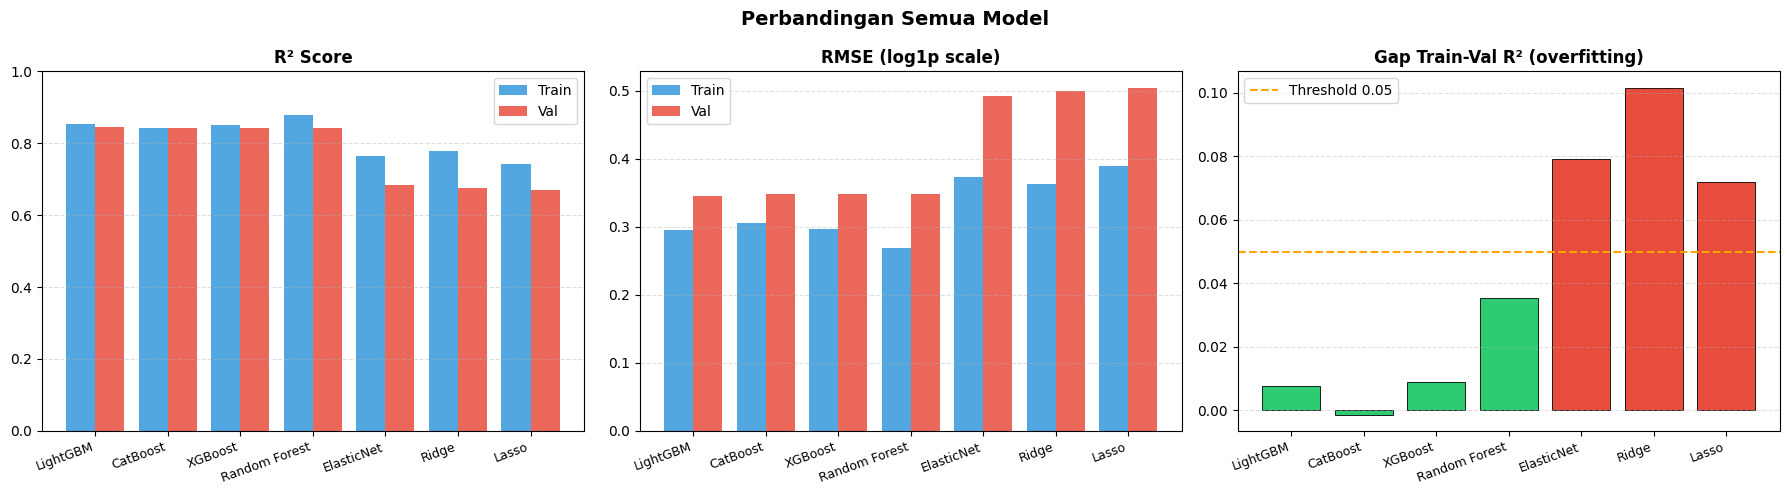

In [227]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models   = df_results.index.tolist()
x        = np.arange(len(models))
colors_t = "#3498db"
colors_v = "#e74c3c"

axes[0].bar(x - 0.2, df_results["Train R²"], 0.4, label="Train", color=colors_t, alpha=0.85)
axes[0].bar(x + 0.2, df_results["Val R²"],   0.4, label="Val",   color=colors_v, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[0].set_title("R² Score", fontweight="bold"); axes[0].legend()
axes[0].set_ylim(0, 1); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].bar(x - 0.2, df_results["Train RMSE"], 0.4, label="Train", color=colors_t, alpha=0.85)
axes[1].bar(x + 0.2, df_results["Val RMSE"],   0.4, label="Val",   color=colors_v, alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[1].set_title("RMSE (log1p scale)", fontweight="bold"); axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

gap_colors = ["#2ecc71" if g <= 0.05 else "#e74c3c" for g in df_results["Gap R²"]]
axes[2].bar(x, df_results["Gap R²"], color=gap_colors, edgecolor="black", linewidth=0.6)
axes[2].axhline(0.05, color="orange", linestyle="--", linewidth=1.5, label="Threshold 0.05")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[2].set_title("Gap Train-Val R² (overfitting)", fontweight="bold"); axes[2].legend()
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Perbandingan Semua Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [228]:
model_map = {
    "Ridge":        ridge_best,
    "Lasso":        lasso_best,
    "ElasticNet":   enet_best,
    "Random Forest": rf,
    "XGBoost":      xgb_model,
    "LightGBM":     lgb_model,
    "CatBoost":    cat_model,
}

best_model = model_map[best_model_name]
X_test_fixed = X_test.copy()
X_test_fixed.columns = best_model.feature_names_in_

y_test_pred = best_model.predict(X_test_fixed)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)

y_test_orig      = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred)
test_rmse_orig   = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
test_mae_orig    = mean_absolute_error(y_test_orig, y_test_pred_orig)

print("=" * 55)
print(f"  EVALUASI FINAL: {best_model_name}")
print("=" * 55)
print(f"  Test R²        : {test_r2:.4f}")
print(f"  Test RMSE      : {test_rmse:.4f}  (log1p scale)")
print(f"  Test MAE       : {test_mae:.4f}  (log1p scale)")
print(f"  Test RMSE      : {test_rmse_orig:.2f}   (skala SCORE asli)")
print(f"  Test MAE       : {test_mae_orig:.2f}   (skala SCORE asli)")

  EVALUASI FINAL: LightGBM
  Test R²        : 0.8361
  Test RMSE      : 0.3077  (log1p scale)
  Test MAE       : 0.1676  (log1p scale)
  Test RMSE      : 6.55   (skala SCORE asli)
  Test MAE       : 3.04   (skala SCORE asli)


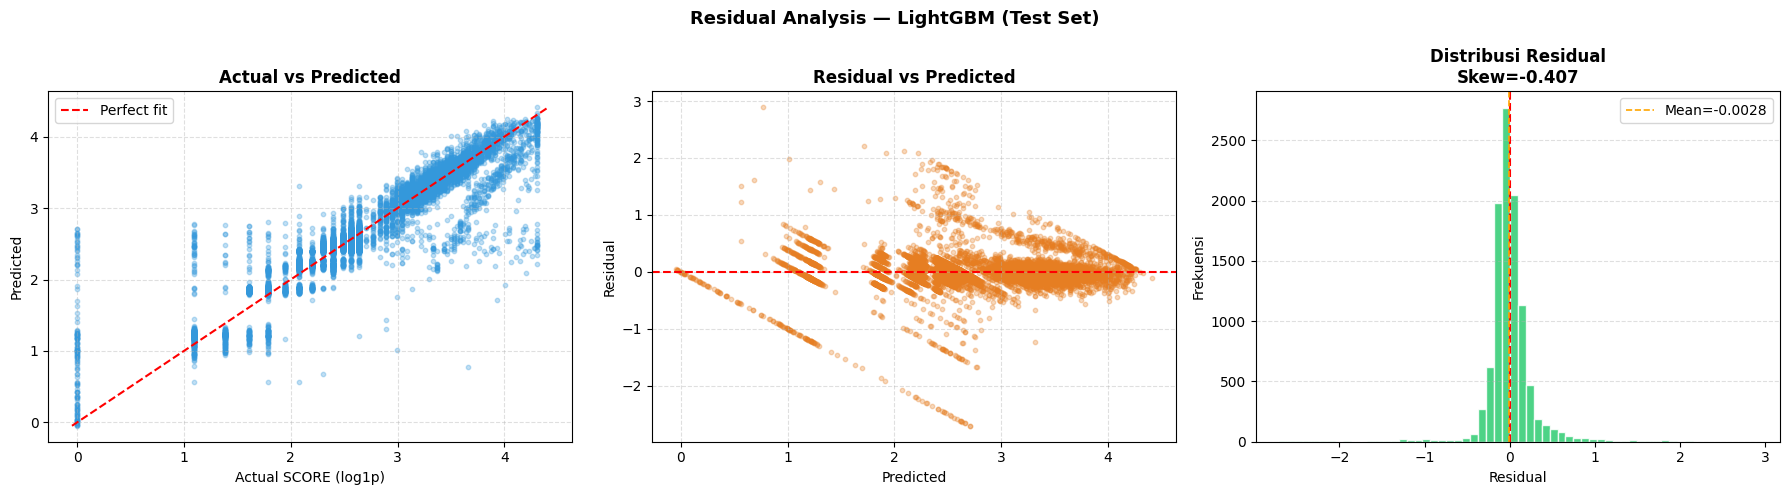

In [229]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color="#3498db")
mn = min(y_test.min(), y_test_pred.min())
mx = max(y_test.max(), y_test_pred.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual SCORE (log1p)"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted", fontweight="bold"); axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].scatter(y_test_pred, residuals, alpha=0.3, s=10, color="#e67e22")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Predicted", fontweight="bold")
axes[1].grid(linestyle="--", alpha=0.4)

axes[2].hist(residuals, bins=60, color="#2ecc71", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].axvline(residuals.mean(), color="orange", linestyle="--", linewidth=1.2,
                label=f"Mean={residuals.mean():.4f}")
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Frekuensi")
axes[2].set_title(f"Distribusi Residual\nSkew={residuals.skew():.3f}", fontweight="bold")
axes[2].legend(); axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(f"Residual Analysis — {best_model_name} (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Computing learning curve: Random Forest...
Computing learning curve: XGBoost...
Computing learning curve: LightGBM...
Computing learning curve: CatBoost...


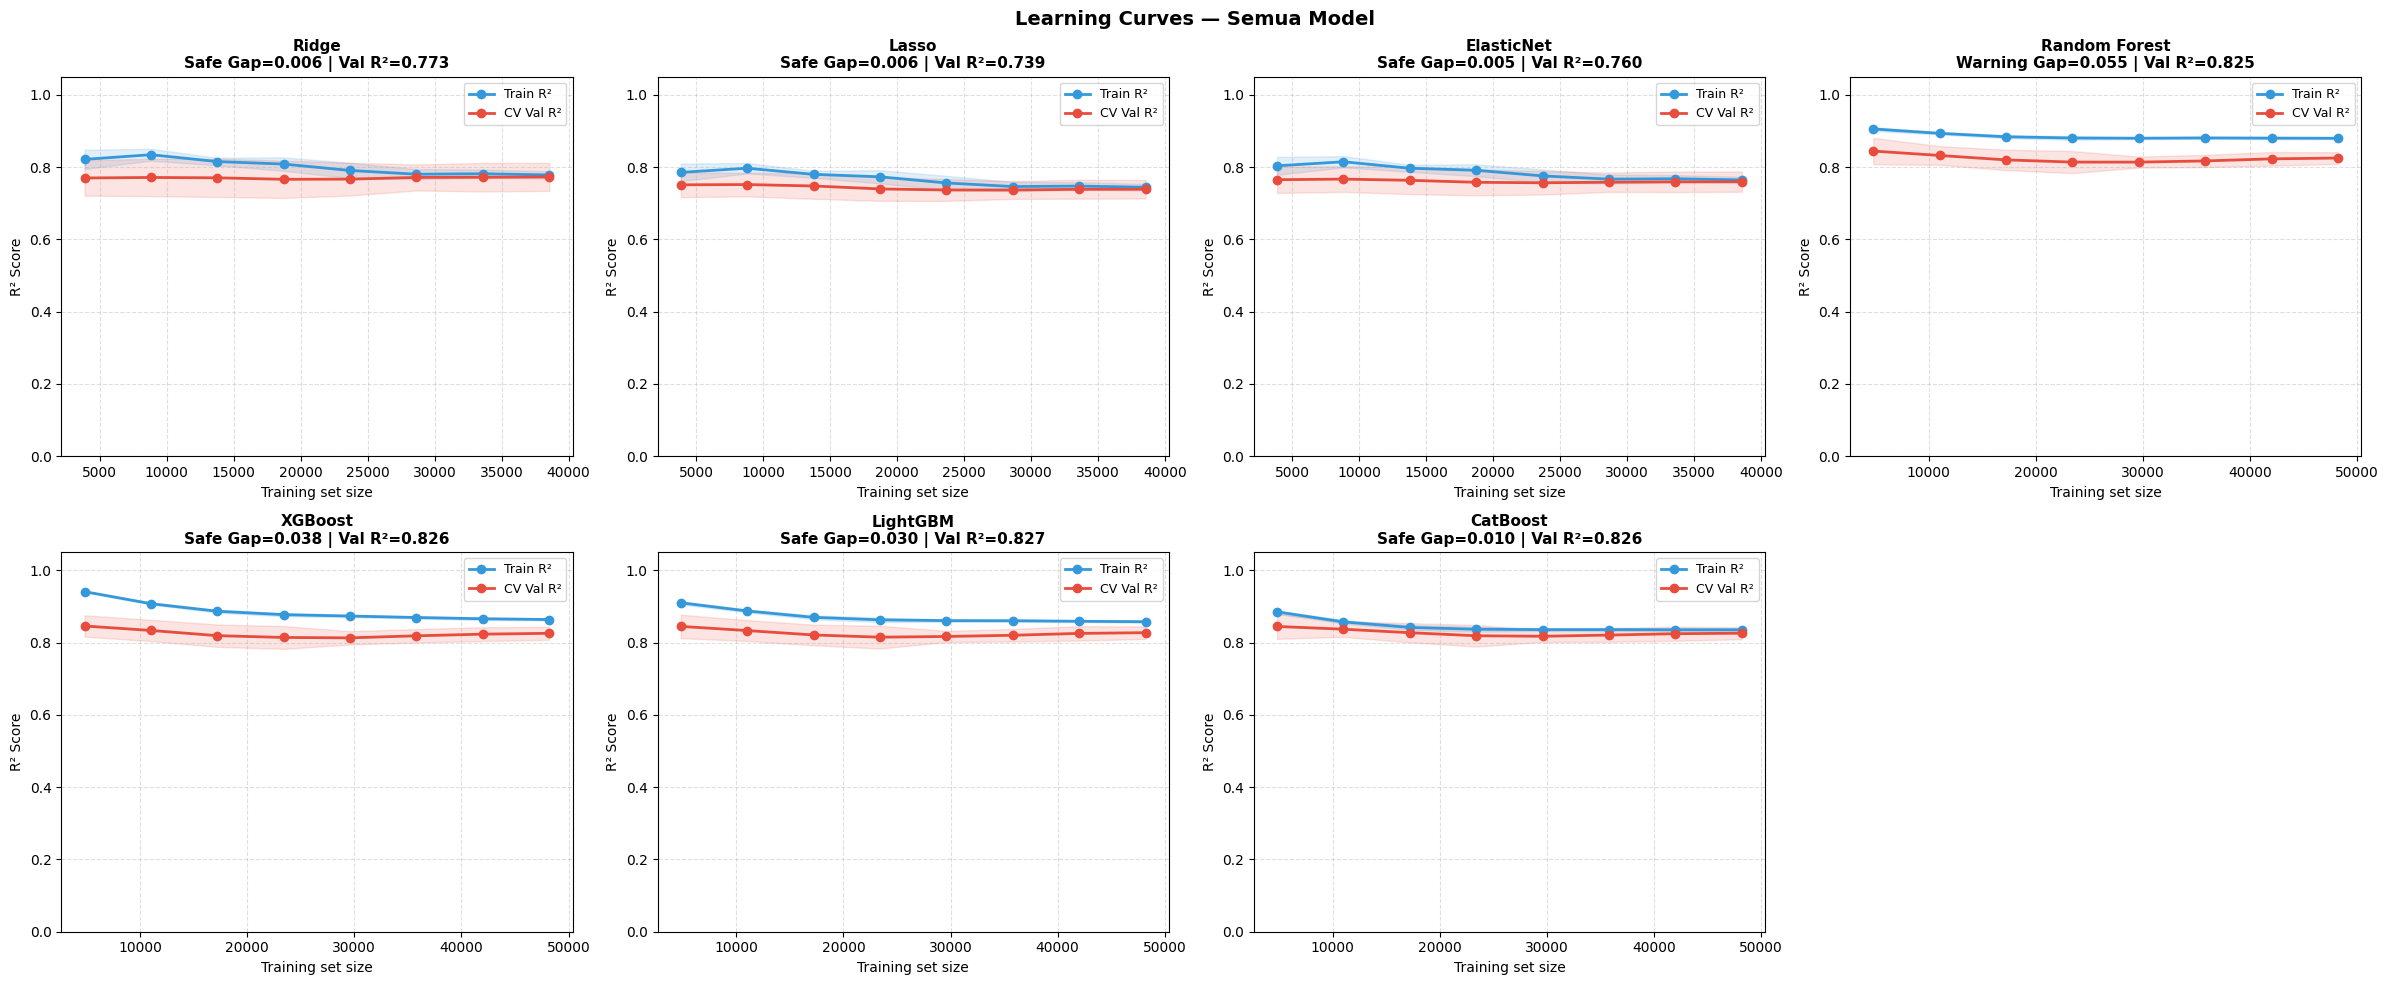

In [230]:
from sklearn.model_selection import learning_curve, KFold

train_sizes_abs = np.linspace(0.1, 1.0, 8)

def manual_learning_curve(model_class, model_params, X, y, train_sizes):
    kf = KFold(n_splits=5, shuffle=False)
    results = []

    for frac in train_sizes:
        n = int(len(X) * frac)
        X_sub = X.iloc[:n]
        y_sub = y.iloc[:n]

        tr_scores, vl_scores = [], []
        for tr_idx, vl_idx in kf.split(X_sub):
            X_tr, X_vl = X_sub.iloc[tr_idx], X_sub.iloc[vl_idx]
            y_tr, y_vl = y_sub.iloc[tr_idx], y_sub.iloc[vl_idx]

            m = model_class(**model_params)
            m.fit(X_tr, y_tr)  

            tr_scores.append(r2_score(y_tr, m.predict(X_tr)))
            vl_scores.append(r2_score(y_vl, m.predict(X_vl)))

        results.append((n, np.mean(tr_scores), np.std(tr_scores),
                           np.mean(vl_scores), np.std(vl_scores)))

    return zip(*results)  
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

def plot_lc(ax, sizes, tr_mean, tr_std, vl_mean, vl_std, name):
    tr_mean, tr_std = np.array(tr_mean), np.array(tr_std)
    vl_mean, vl_std = np.array(vl_mean), np.array(vl_std)

    ax.plot(sizes, tr_mean, "o-", color="#3498db", linewidth=2, label="Train R²")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#3498db")
    ax.plot(sizes, vl_mean, "o-", color="#e74c3c", linewidth=2, label="CV Val R²")
    ax.fill_between(sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color="#e74c3c")

    gap    = tr_mean[-1] - vl_mean[-1]
    status = "Safe" if gap <= 0.05 else "Warning"
    ax.set_title(f"{name}\n{status} Gap={gap:.3f} | Val R²={vl_mean[-1]:.3f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Training set size"); ax.set_ylabel("R² Score")
    ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.4); ax.set_ylim(0, 1.05)

for ax, (name, model) in zip(axes.flatten()[:3],
    [("Ridge", ridge_best), ("Lasso", lasso_best), ("ElasticNet", enet_best)]):
    sz, tr_s, vl_s = learning_curve(model, X_train, y_train,
                                     train_sizes=train_sizes_abs, cv=5,
                                     scoring="r2", n_jobs=-1, shuffle=False)
    plot_lc(ax, sz, tr_s.mean(1), tr_s.std(1), vl_s.mean(1), vl_s.std(1), name)

tree_configs = [
    ("Random Forest", RandomForestRegressor,
     dict(n_estimators=100, max_depth=15, min_samples_leaf=5,
          max_features=0.6, n_jobs=-1, random_state=42)),
    ("XGBoost", xgb.XGBRegressor,
     dict(n_estimators=200, learning_rate=0.05, max_depth=6,
          subsample=0.8, colsample_bytree=0.8, random_state=42,
          n_jobs=-1, verbosity=0)),
    ("LightGBM", lgb.LGBMRegressor,
     dict(n_estimators=200, learning_rate=0.05, num_leaves=63,
          max_depth=7, subsample=0.8, colsample_bytree=0.8,
          random_state=42, n_jobs=-1, verbose=-1)),
    ("CatBoost", CatBoostRegressor,
     dict(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
          subsample=0.8, colsample_bylevel=0.8, random_seed=42, verbose=0)),
]

for ax, (name, cls, params) in zip(axes.flatten()[3:], tree_configs):
    print(f"Computing learning curve: {name}...")
    sz, tr_m, tr_s, vl_m, vl_s = manual_learning_curve(cls, params, X_train, y_train, train_sizes_abs)
    plot_lc(ax, list(sz), list(tr_m), list(tr_s), list(vl_m), list(vl_s), name)

axes[1, 3].set_visible(False)

plt.suptitle("Learning Curves — Semua Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Hyperparameter Tuning — Optuna ##

**Strategi tuning:**
- Library: **Optuna** — framework modern berbasis Bayesian Optimization, lebih efisien dari GridSearch/RandomSearch karena memprioritaskan area parameter yang menjanjikan
- Semua model di-tune terhadap **Val R²** (bukan train)
- Setiap trial menggunakan parameter berbeda, Optuna belajar dari trial sebelumnya untuk memilih parameter berikutnya
- `n_trials=50` per model — cukup untuk menemukan kombinasi yang baik tanpa terlalu lama

**Parameter yang di-tune per model:**

| Model | Parameter |
|---|---|
| **Random Forest** | n_estimators, max_depth, min_samples_leaf, max_features |
| **XGBoost** | n_estimators, learning_rate, max_depth, subsample, colsample_bytree, reg_alpha, reg_lambda |
| **LightGBM** | n_estimators, learning_rate, num_leaves, max_depth, subsample, colsample_bytree, reg_alpha, reg_lambda, min_child_samples |
| **CatBoost** | iterations, learning_rate, depth, l2_leaf_reg, subsample, colsample_bylevel |


In [233]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING) 

print("✅ Optuna siap")
print(f"   Versi: {optuna.__version__}")

✅ Optuna siap
   Versi: 4.8.0


**Helper Method**

In [234]:
def run_optuna(study_name, objective_fn, n_trials=50):
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        study_name=study_name
    )
    study.optimize(objective_fn, n_trials=n_trials, show_progress_bar=True)

    print(f"\n{'='*55}")
    print(f"  {study_name} — Best Trial")
    print(f"{'='*55}")
    print(f"  Val R²  : {study.best_value:.4f}")
    print(f"  Params  : {study.best_params}")
    return study

tuned_results = []  
print("✅ Helper siap")


✅ Helper siap


## Tuning 1 — Random Forest ##

In [235]:
def rf_objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth":       trial.suggest_int("max_depth", 5, 20),
        "min_samples_leaf":trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features":    trial.suggest_float("max_features", 0.3, 1.0),
        "n_jobs":          -1,
        "random_state":    42,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    return r2_score(y_val, model.predict(X_val))

study_rf = run_optuna("Random Forest", rf_objective, n_trials=50)

Best trial: 39. Best value: 0.843868: 100%|██████████| 50/50 [01:23<00:00,  1.67s/it]


  Random Forest — Best Trial
  Val R²  : 0.8439
  Params  : {'n_estimators': 350, 'max_depth': 14, 'min_samples_leaf': 4, 'max_features': 0.4038974033605004}


In [238]:
rf_tuned = RandomForestRegressor(
    **study_rf.best_params,
    n_jobs=-1,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
res_rf_tuned = evaluate(rf_tuned, X_train, y_train, X_val, y_val, "Random Forest (Tuned)")
tuned_results.append(res_rf_tuned)

  Random Forest (Tuned)
  Train RMSE : 0.2746  |  Val RMSE : 0.3470  (log1p scale)
  Train MAE  : 2.6533  |  Val MAE  : 3.2078  (skala SCORE asli)
  Train R²   : 0.8724  |  Val R²   : 0.8439
  Gap R²     : 0.0285  ✅


## Tuning 2 — XGBoost ##

In [243]:
def xgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "early_stopping_rounds": 20,   
        "random_state":      42,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    return r2_score(y_val, model.predict(X_val))

study_xgb = run_optuna("XGBoost", xgb_objective, n_trials=50)

Best trial: 43. Best value: 0.844621: 100%|██████████| 50/50 [00:18<00:00,  2.64it/s]


  XGBoost — Best Trial
  Val R²  : 0.8446
  Params  : {'n_estimators': 200, 'learning_rate': 0.15669196746451047, 'max_depth': 5, 'subsample': 0.5251892386896251, 'colsample_bytree': 0.7792481148182488, 'reg_alpha': 2.760677211093984, 'reg_lambda': 4.36886548638104}


In [244]:
best_params_xgb = {k: v for k, v in study_xgb.best_params.items()
                   if k != "early_stopping_rounds"}

xgb_tuned = xgb.XGBRegressor(
    **best_params_xgb,
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {xgb_tuned.best_iteration}")
res_xgb_tuned = evaluate(xgb_tuned, X_train, y_train, X_val, y_val, "XGBoost (Tuned)")
tuned_results.append(res_xgb_tuned)

Best iteration: 58
  XGBoost (Tuned)
  Train RMSE : 0.3063  |  Val RMSE : 0.3461  (log1p scale)
  Train MAE  : 3.0066  |  Val MAE  : 3.1743  (skala SCORE asli)
  Train R²   : 0.8412  |  Val R²   : 0.8446
  Gap R²     : -0.0034  ✅


## Tuning 3 — LightGBM ##

In [245]:
def lgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "random_state":      42,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )
    return r2_score(y_val, model.predict(X_val))

study_lgb = run_optuna("LightGBM", lgb_objective, n_trials=50)

Best trial: 48. Best value: 0.84514: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s] 


  LightGBM — Best Trial
  Val R²  : 0.8451
  Params  : {'n_estimators': 550, 'learning_rate': 0.163403485480321, 'num_leaves': 36, 'max_depth': 9, 'subsample': 0.6726608236141243, 'colsample_bytree': 0.6519948792121484, 'reg_alpha': 3.7927184863587526, 'reg_lambda': 0.07788794432316737, 'min_child_samples': 6}


In [246]:
lgb_tuned = lgb.LGBMRegressor(
    **study_lgb.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(period=-1)]
)
print(f"Best iteration: {lgb_tuned.best_iteration_}")
res_lgb_tuned = evaluate(lgb_tuned, X_train, y_train, X_val, y_val, "LightGBM (Tuned)")
tuned_results.append(res_lgb_tuned)

Best iteration: 56
  LightGBM (Tuned)
  Train RMSE : 0.2976  |  Val RMSE : 0.3456  (log1p scale)
  Train MAE  : 2.9654  |  Val MAE  : 3.1493  (skala SCORE asli)
  Train R²   : 0.8502  |  Val R²   : 0.8451
  Gap R²     : 0.0051  ✅


## Tuning 4 — CatBoost ##

In [237]:
from catboost import CatBoostRegressor

def cat_objective(trial):
    params = {
        "iterations":        trial.suggest_int("iterations", 100, 600, step=50),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":             trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "random_seed":       42,
        "verbose":           0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20,
        verbose=0
    )
    return r2_score(y_val, model.predict(X_val))

study_cat = run_optuna("CatBoost", cat_objective, n_trials=50)

Best trial: 21. Best value: 0.845644: 100%|██████████| 50/50 [02:19<00:00,  2.79s/it]


  CatBoost — Best Trial
  Val R²  : 0.8456
  Params  : {'iterations': 600, 'learning_rate': 0.07134874761876797, 'depth': 10, 'l2_leaf_reg': 7.671747852246662, 'subsample': 0.8376835233192436, 'colsample_bylevel': 0.874239735654594}


In [247]:
cat_tuned = CatBoostRegressor(
    **study_cat.best_params,
    early_stopping_rounds=30,
    random_seed=42,
    verbose=0
)
cat_tuned.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=0
)
print(f"Best iteration: {cat_tuned.get_best_iteration()}")
res_cat_tuned = evaluate(cat_tuned, X_train, y_train, X_val, y_val, "CatBoost (Tuned)")
tuned_results.append(res_cat_tuned)

Best iteration: 259
  CatBoost (Tuned)
  Train RMSE : 0.2924  |  Val RMSE : 0.3450  (log1p scale)
  Train MAE  : 2.8850  |  Val MAE  : 3.1597  (skala SCORE asli)
  Train R²   : 0.8553  |  Val R²   : 0.8456
  Gap R²     : 0.0097  ✅


## Save Hasil Tuning

In [263]:
import pickle

with open("./models/tuned_models.pkl", "wb") as f:
    pickle.dump({
        "rf_tuned":      rf_tuned,
        "xgb_tuned":     xgb_tuned,
        "lgb_tuned":     lgb_tuned,
        "cat_tuned":     cat_tuned,
        "tuned_results": tuned_results,
    }, f)
print("✅ Tersimpan")

with open("./models/tuned_models.pkl", "rb") as f:
    saved = pickle.load(f)

rf_tuned      = saved["rf_tuned"]
xgb_tuned     = saved["xgb_tuned"]
lgb_tuned     = saved["lgb_tuned"]
cat_tuned     = saved["cat_tuned"]
tuned_results = saved["tuned_results"]
print("✅ Di-load")

✅ Tersimpan
✅ Di-load


## Perbandingan Before vs After Tuning ##

In [252]:
before_tree = {r["Model"]: r for r in all_results
               if r["Model"] in ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]}

print("=" * 120)
print("  BEFORE vs AFTER TUNING — Tree-Based Models")
print("=" * 120)
print(f"{'Model':<25} {'B.Val R²':>9} {'A.Val R²':>9} {'Δ R²':>7} "
      f"{'B.RMSE':>8} {'A.RMSE':>8} {'ΔRMSE':>7} "
      f"{'B.MAE':>8} {'A.MAE':>8} {'ΔMAE':>7} {'Gap':>6}")
print("-" * 120)

for res in tuned_results:
    base_name = res["Model"].replace(" (Tuned)", "")
    bef = before_tree[base_name]

    b_r2    = bef["Val R²"];     a_r2    = res["Val R²"]
    delta_r2 = a_r2 - b_r2
    arr_r2   = "↑" if delta_r2 > 0 else "↓" if delta_r2 < 0 else "→"

    b_rmse   = bef["Val RMSE"];  a_rmse  = res["Val RMSE"]
    delta_rm = a_rmse - b_rmse
    arr_rm   = "↓" if delta_rm < 0 else "↑" if delta_rm > 0 else "→"  # turun = bagus

    b_mae    = bef["Val MAE"];   a_mae   = res["Val MAE"]
    delta_ma = a_mae - b_mae
    arr_ma   = "↓" if delta_ma < 0 else "↑" if delta_ma > 0 else "→"  # turun = bagus

    print(f"{res['Model']:<25} "
          f"{b_r2:>9.4f} {a_r2:>9.4f} {arr_r2}{abs(delta_r2):>5.4f} "
          f"{b_rmse:>8.4f} {a_rmse:>8.4f} {arr_rm}{abs(delta_rm):>5.4f} "
          f"{b_mae:>8.2f} {a_mae:>8.2f} {arr_ma}{abs(delta_ma):>5.2f} "
          f"{res['Gap R²']:>6.4f}")

print("=" * 120)
print("Catatan: R² ↑ = lebih baik | RMSE ↓ = lebih baik | MAE ↓ = lebih baik (skala SCORE asli)")

  BEFORE vs AFTER TUNING — Tree-Based Models
Model                      B.Val R²  A.Val R²    Δ R²   B.RMSE   A.RMSE   ΔRMSE    B.MAE    A.MAE    ΔMAE    Gap
------------------------------------------------------------------------------------------------------------------------
Random Forest (Tuned)        0.8421    0.8439 ↑0.0018   0.3489   0.3470 ↓0.0019     3.22     3.21 ↓ 0.01 0.0285
XGBoost (Tuned)              0.8426    0.8446 ↑0.0021   0.3484   0.3461 ↓0.0023     3.15     3.17 ↑ 0.02 -0.0034
LightGBM (Tuned)             0.8448    0.8451 ↑0.0003   0.3459   0.3456 ↓0.0004     3.15     3.15 ↓ 0.00 0.0051
CatBoost (Tuned)             0.8430    0.8456 ↑0.0026   0.3479   0.3450 ↓0.0029     3.16     3.16 ↑ 0.00 0.0097
Catatan: R² ↑ = lebih baik | RMSE ↓ = lebih baik | MAE ↓ = lebih baik (skala SCORE asli)


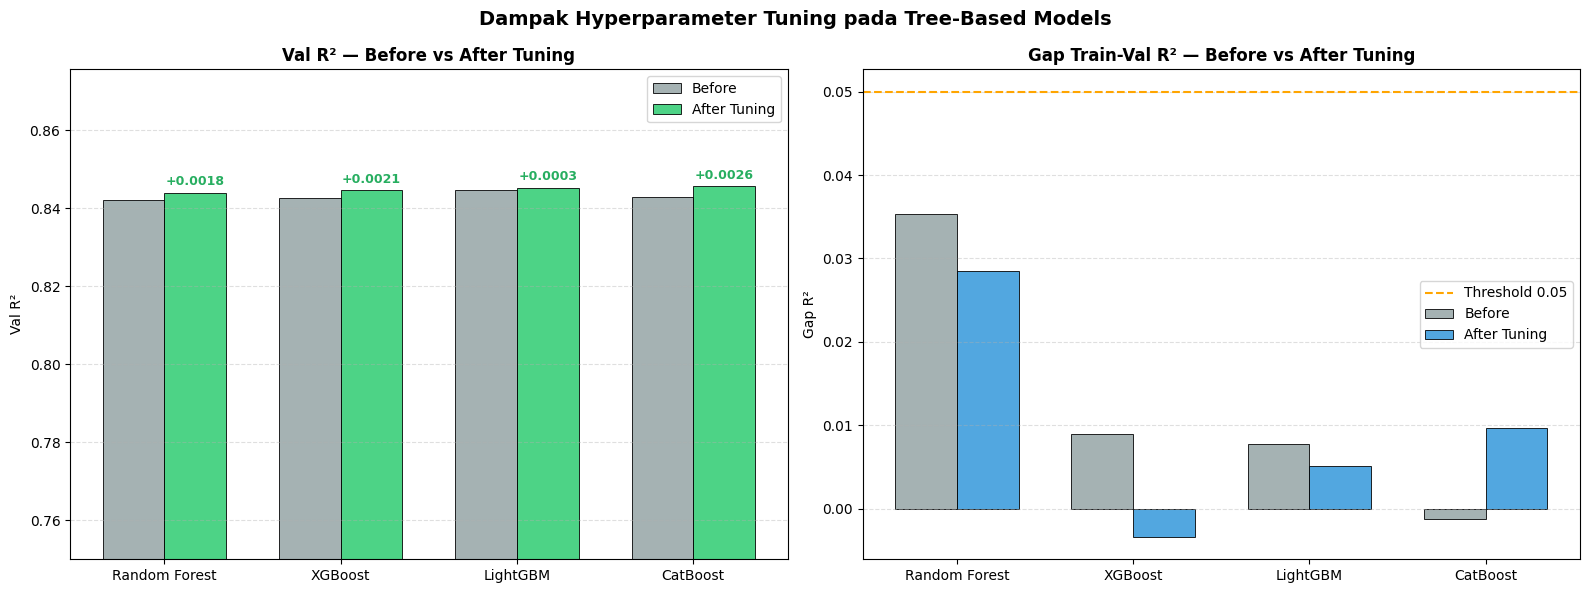

In [253]:
tree_names   = ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]
before_r2s   = [before_tree[n]["Val R²"]  for n in tree_names]
after_r2s    = [r["Val R²"] for r in tuned_results]
before_gaps  = [before_tree[n]["Gap R²"]  for n in tree_names]
after_gaps   = [r["Gap R²"] for r in tuned_results]

x     = np.arange(len(tree_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - width/2, before_r2s, width, label="Before",
            color="#95a5a6", edgecolor="black", linewidth=0.7, alpha=0.85)
axes[0].bar(x + width/2, after_r2s,  width, label="After Tuning",
            color="#2ecc71", edgecolor="black", linewidth=0.7, alpha=0.85)

for i, (b, a) in enumerate(zip(before_r2s, after_r2s)):
    delta = a - b
    color = "#27ae60" if delta > 0 else "#e74c3c"
    axes[0].text(i + width/2, a + 0.002, f"+{delta:.4f}" if delta > 0 else f"{delta:.4f}",
                 ha="center", fontsize=9, fontweight="bold", color=color)

axes[0].set_xticks(x); axes[0].set_xticklabels(tree_names, fontsize=10)
axes[0].set_title("Val R² — Before vs After Tuning", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Val R²"); axes[0].legend()
axes[0].set_ylim(0.75, min(1.0, max(after_r2s) + 0.03))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].bar(x - width/2, before_gaps, width, label="Before",
            color="#95a5a6", edgecolor="black", linewidth=0.7, alpha=0.85)
axes[1].bar(x + width/2, after_gaps,  width, label="After Tuning",
            color="#3498db", edgecolor="black", linewidth=0.7, alpha=0.85)
axes[1].axhline(0.05, color="orange", linestyle="--", linewidth=1.5, label="Threshold 0.05")

axes[1].set_xticks(x); axes[1].set_xticklabels(tree_names, fontsize=10)
axes[1].set_title("Gap Train-Val R² — Before vs After Tuning",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Gap R²"); axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Dampak Hyperparameter Tuning pada Tree-Based Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Evaluasi Final — Model Terbaik di Test Set ##

In [260]:
df_tuned = pd.DataFrame(tuned_results).set_index("Model")
df_tuned = df_tuned.round(4).sort_values("Val MAE", ascending=True)

print("=" * 70)
print("  RANKING MODEL SETELAH TUNING (Val MAE)")
print("=" * 70)
print(df_tuned[["Train R²", "Val R²", "Gap R²", "Val RMSE", "Val MAE"]].to_string())

best_tuned_name = df_tuned["Val MAE"].idxmin()
print(f"\n🏆 Model terbaik setelah tuning: {best_tuned_name}")

  RANKING MODEL SETELAH TUNING (Val MAE)
                       Train R²  Val R²  Gap R²  Val RMSE  Val MAE
Model                                                             
LightGBM (Tuned)         0.8502  0.8451  0.0051    0.3456   3.1493
CatBoost (Tuned)         0.8553  0.8456  0.0097    0.3450   3.1597
XGBoost (Tuned)          0.8412  0.8446 -0.0034    0.3461   3.1743
Random Forest (Tuned)    0.8724  0.8439  0.0285    0.3470   3.2078

🏆 Model terbaik setelah tuning: LightGBM (Tuned)


In [261]:
tuned_model_map = {
    "Random Forest (Tuned)": rf_tuned,
    "XGBoost (Tuned)":       xgb_tuned,
    "LightGBM (Tuned)":      lgb_tuned,
    "CatBoost (Tuned)":      cat_tuned,
}

best_tuned_model = tuned_model_map[best_tuned_name]

X_test_final = X_test.copy()
if hasattr(best_tuned_model, "feature_names_in_"):
    X_test_final.columns = best_tuned_model.feature_names_in_

y_test_pred_tuned = best_tuned_model.predict(X_test_final)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
test_mae  = mean_absolute_error(y_test, y_test_pred_tuned)
test_r2   = r2_score(y_test, y_test_pred_tuned)

test_rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_tuned)))
test_mae_orig  = mean_absolute_error(np.expm1(y_test), np.expm1(y_test_pred_tuned))

print("=" * 55)
print(f"  EVALUASI FINAL (TUNED): {best_tuned_name}")
print("=" * 55)
print(f"  Test R²   : {test_r2:.4f}")
print(f"  Test RMSE : {test_rmse:.4f}  (log1p scale)")
print(f"  Test MAE  : {test_mae:.4f}  (log1p scale)")
print(f"  Test RMSE : {test_rmse_orig:.2f}   (skala SCORE asli)")
print(f"  Test MAE  : {test_mae_orig:.2f}   (skala SCORE asli)")

print(f"\n  Perbandingan dengan baseline:")
print(f"  Baseline Test R² : 0.8340  (LightGBM sebelum tuning)")
print(f"  Tuned    Test R² : {test_r2:.4f}  ({best_tuned_name})")
print(f"  Δ R²             : {test_r2 - 0.8340:+.4f}")


  EVALUASI FINAL (TUNED): LightGBM (Tuned)
  Test R²   : 0.8367
  Test RMSE : 0.3071  (log1p scale)
  Test MAE  : 0.1680  (log1p scale)
  Test RMSE : 6.55   (skala SCORE asli)
  Test MAE  : 3.05   (skala SCORE asli)

  Perbandingan dengan baseline:
  Baseline Test R² : 0.8340  (LightGBM sebelum tuning)
  Tuned    Test R² : 0.8367  (LightGBM (Tuned))
  Δ R²             : +0.0027


# SHAP Values — Model Interpretability ##

SHAP (SHapley Additive exPlanations) adalah framework untuk menjelaskan prediksi model secara individual maupun global, berdasarkan teori game theory (Shapley values).

Untuk setiap prediksi, SHAP menjawab pertanyaan: **"Seberapa besar kontribusi tiap fitur terhadap prediksi ini, dibandingkan rata-rata prediksi model?"**

```
prediksi = baseline (rata-rata semua prediksi) + SHAP_fitur_1 + SHAP_fitur_2 + ... + SHAP_fitur_n
```

**Tiga level analisis yang akan dilakukan:**

| Level | Plot | Pertanyaan |
|---|---|---|
| **Global** | Summary Plot (Beeswarm) | Fitur mana yang paling penting secara keseluruhan? |
| **Global** | Bar Plot | Rata-rata kontribusi absolut tiap fitur |
| **Global** | Dependence Plot | Bagaimana hubungan nilai fitur dengan SHAP-nya? |
| **Local** | Waterfall Plot | Mengapa model memprediksi nilai X untuk satu inspeksi? |
| **Local** | Force Plot | Visualisasi push/pull fitur untuk satu prediksi |

**Model yang digunakan:** LightGBM (Tuned) — model terbaik berdasarkan Val MAE.

In [265]:
import shap
shap.initjs()  

print(f"✅ SHAP versi: {shap.__version__}")

✅ SHAP versi: 0.51.0


## Hitung SHAP Values ##

In [266]:
explainer = shap.TreeExplainer(lgb_tuned)

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_idx].reset_index(drop=True)

shap_values = explainer(X_test_sample)

print(f"✅ SHAP values berhasil dihitung")
print(f"Shape SHAP values : {shap_values.values.shape}")
print(f"Shape X_test_sample: {X_test_sample.shape}")
print(f"Baseline (expected value): {explainer.expected_value:.4f}")
print(f"  → Dalam skala asli: {np.expm1(explainer.expected_value):.2f} poin SCORE")


✅ SHAP values berhasil dihitung
Shape SHAP values : (2000, 47)
Shape X_test_sample: (2000, 47)
Baseline (expected value): 2.6667
  → Dalam skala asli: 13.39 poin SCORE


## Global Analysis 1 — Summary Plot (Beeswarm) ##

**Cara baca Summary Plot:**
- Sumbu Y = fitur, diurutkan dari yang paling berpengaruh (atas) ke paling kecil (bawah)
- Sumbu X = nilai SHAP (positif = mendorong score tinggi, negatif = mendorong score rendah)
- Warna titik = nilai fitur (merah = tinggi, biru = rendah)
- Setiap titik = satu sampel dari test set

**Pola yang dicari:** Apakah fitur dengan nilai tinggi (merah) punya SHAP positif? Kalau ya, berarti nilai fitur yang tinggi mendorong score naik.


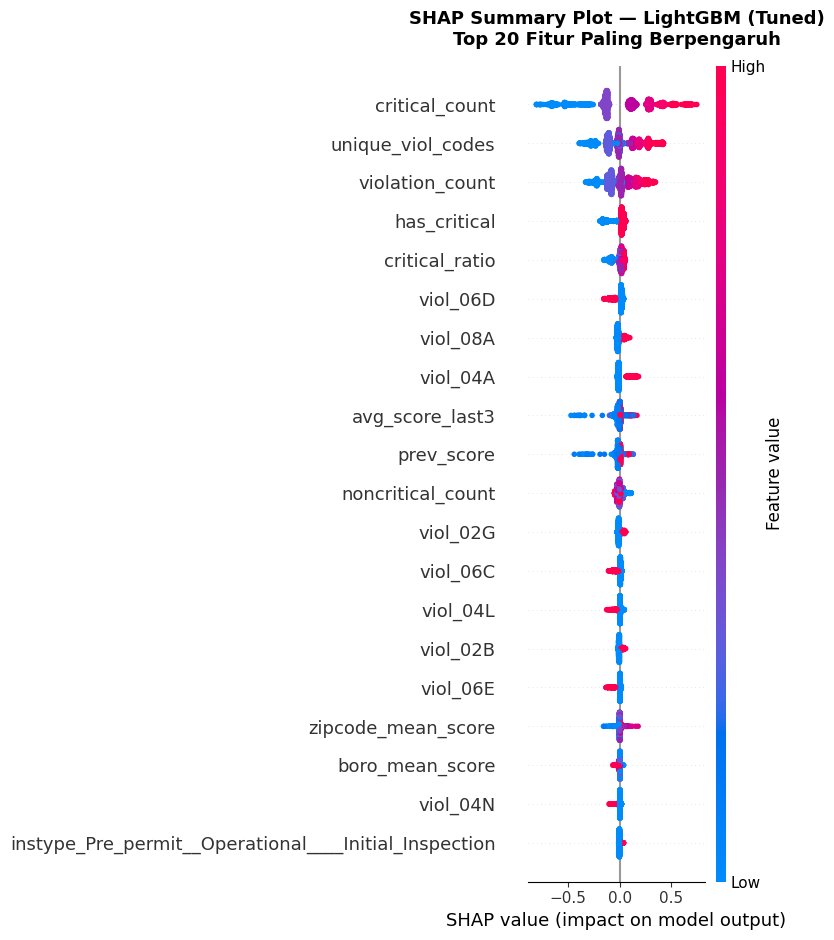

In [269]:
plt.figure(figsize=(20, 15))
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,        
    show=False
)
plt.title("SHAP Summary Plot — LightGBM (Tuned)\nTop 20 Fitur Paling Berpengaruh",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## Global Analysis 2 — Bar Plot (Mean |SHAP|) ##

**Cara baca Bar Plot:**
- Berbeda dari Beeswarm, bar plot menunjukkan **rata-rata nilai absolut SHAP** per fitur
- Ini adalah ukuran "kepentingan global" yang lebih simpel — tidak ada informasi arah
- Cocok untuk reporting dan presentasi karena lebih mudah dibaca


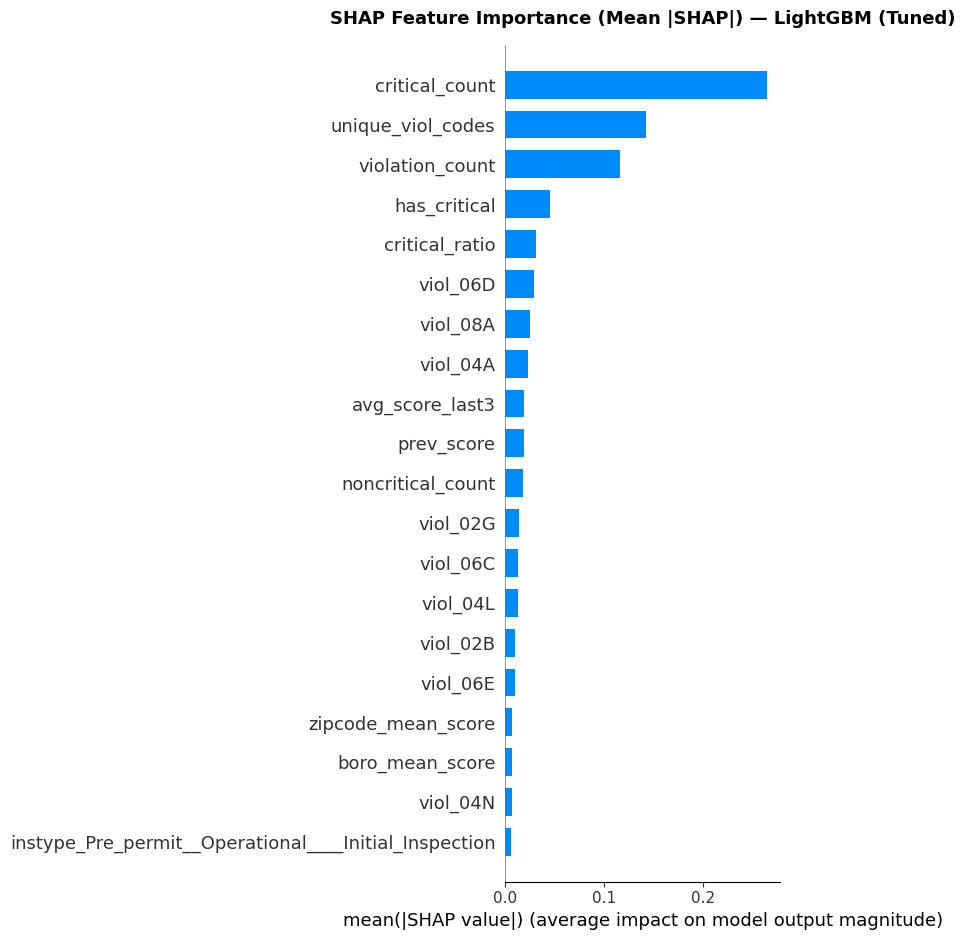

In [270]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance (Mean |SHAP|) — LightGBM (Tuned)",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## Global Analysis 3 — Dependence Plot ##

**Cara baca Dependence Plot:**
- Sumbu X = nilai fitur
- Sumbu Y = SHAP value fitur tersebut
- Warna = nilai fitur lain yang paling berinteraksi (auto-detect oleh SHAP)
- Menunjukkan **hubungan non-linear** antara nilai fitur dan dampaknya ke prediksi

Dibuat untuk 3 fitur paling penting berdasarkan Summary Plot.


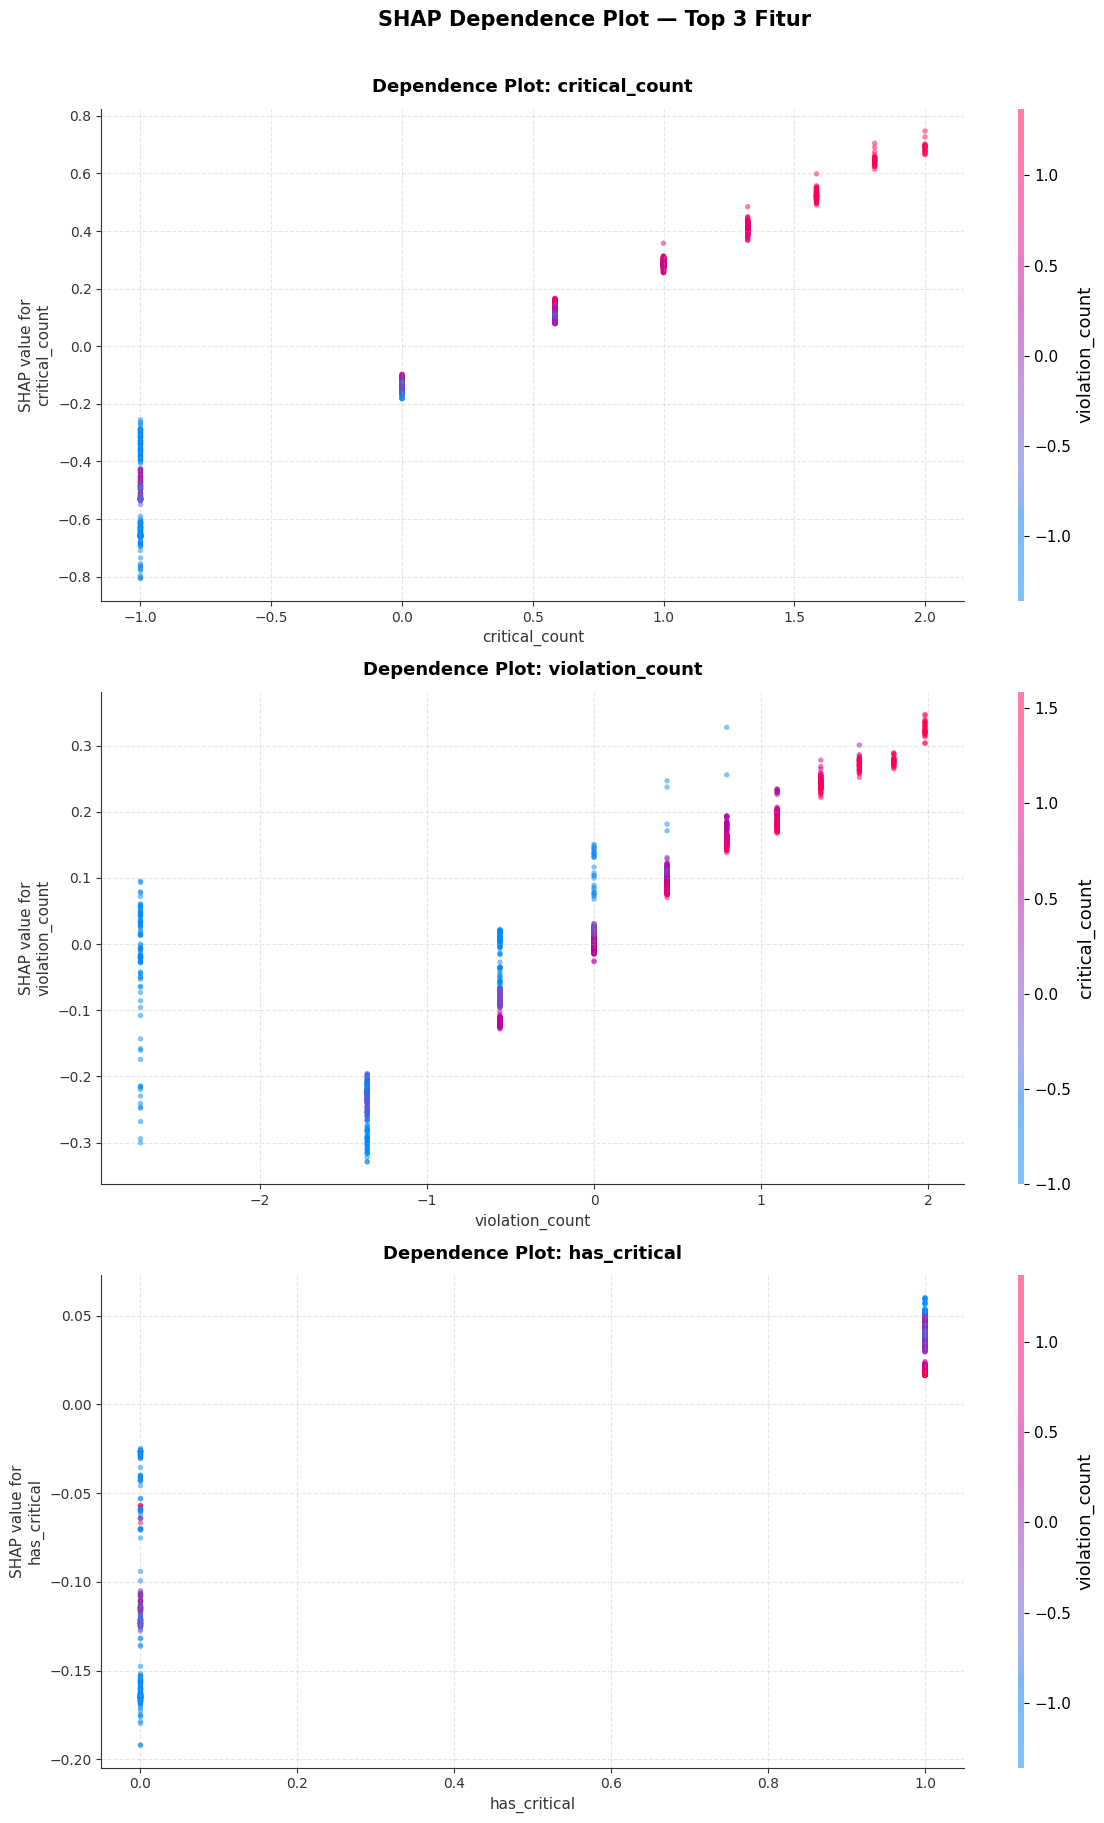

In [274]:
top3_features = ["critical_count", "violation_count", "has_critical"]

fig, axes = plt.subplots(3, 1, figsize=(12, 18))  

for ax, feat in zip(axes, top3_features):
    if feat not in X_test_sample.columns:
        ax.set_visible(False)
        continue

    shap.dependence_plot(
        feat,
        shap_values.values,
        X_test_sample,
        ax=ax,
        show=False,
        alpha=0.5,       
        dot_size=15,     
    )
    ax.set_title(f"Dependence Plot: {feat}", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel(f"SHAP value for\n{feat}", fontsize=11)
    ax.grid(linestyle="--", alpha=0.3)

plt.suptitle("SHAP Dependence Plot — Top 3 Fitur",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Local Analysis 1 — Waterfall Plot ##

**Cara baca Waterfall Plot:**
- Menjelaskan **satu prediksi spesifik** secara detail
- Dimulai dari `E[f(x)]` = baseline (rata-rata prediksi model)
- Setiap fitur menambah (+) atau mengurangi (−) prediksi dari baseline
- Diakhiri dengan `f(x)` = prediksi final untuk sampel tersebut
- Merah = mendorong score naik | Biru = mendorong score turun

Dibuat untuk 3 kasus: prediksi tinggi, rendah, dan di sekitar median.


In [275]:
preds_sample = lgb_tuned.predict(X_test_sample)

idx_high   = np.argmax(preds_sample)
idx_low    = np.argmin(preds_sample)
idx_median = np.argmin(np.abs(preds_sample - np.median(preds_sample)))

print("Sampel yang dipilih:")
for label, idx in [("Tinggi", idx_high), ("Rendah", idx_low), ("Median", idx_median)]:
    actual  = np.expm1(y_test_sample.iloc[idx])
    pred    = np.expm1(preds_sample[idx])
    print(f"  {label:<8}: idx={idx} | Actual={actual:.1f} | Predicted={pred:.1f}")


Sampel yang dipilih:
  Tinggi  : idx=1050 | Actual=73.0 | Predicted=73.5
  Rendah  : idx=316 | Actual=0.0 | Predicted=-0.0
  Median  : idx=845 | Actual=13.0 | Predicted=12.6


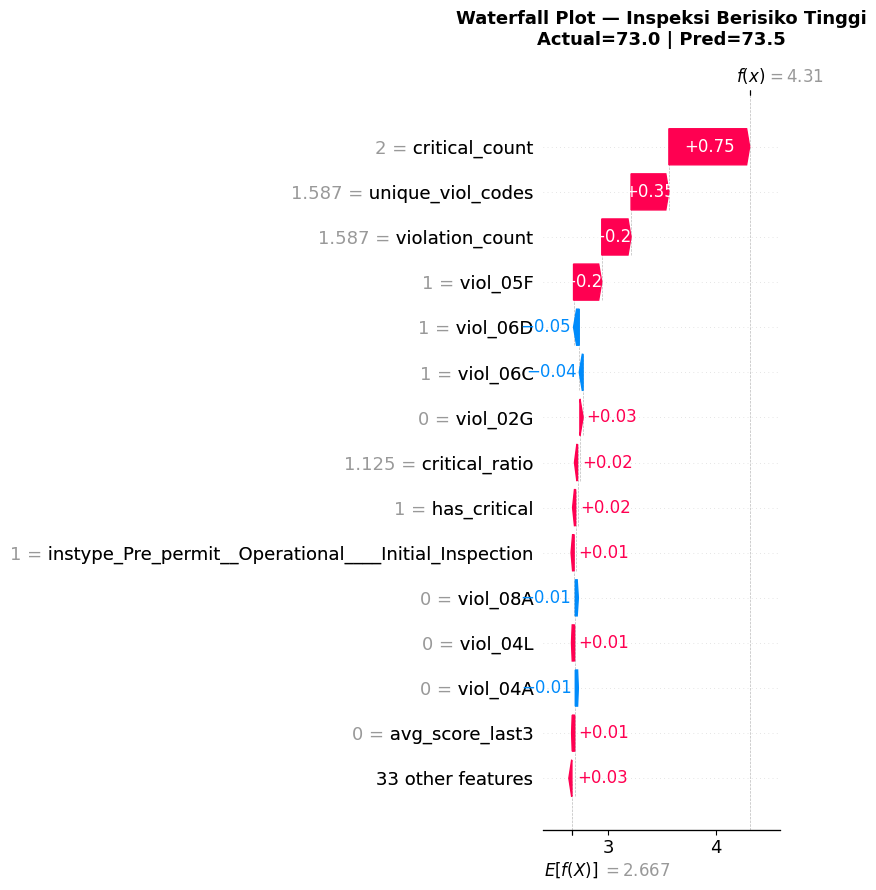

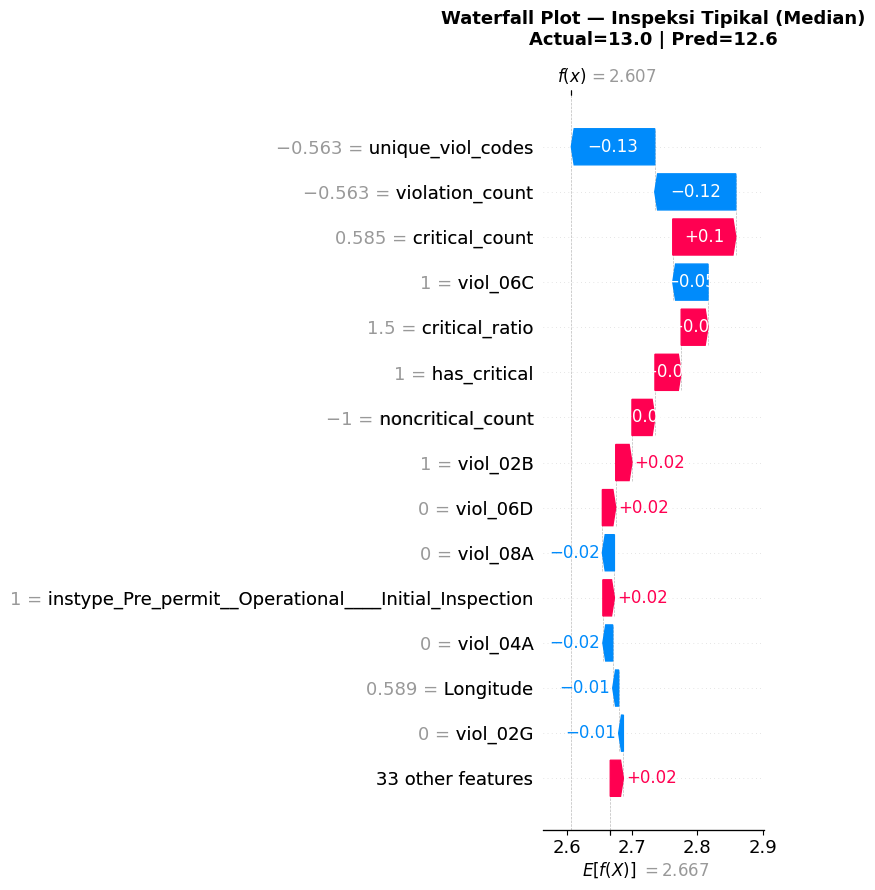

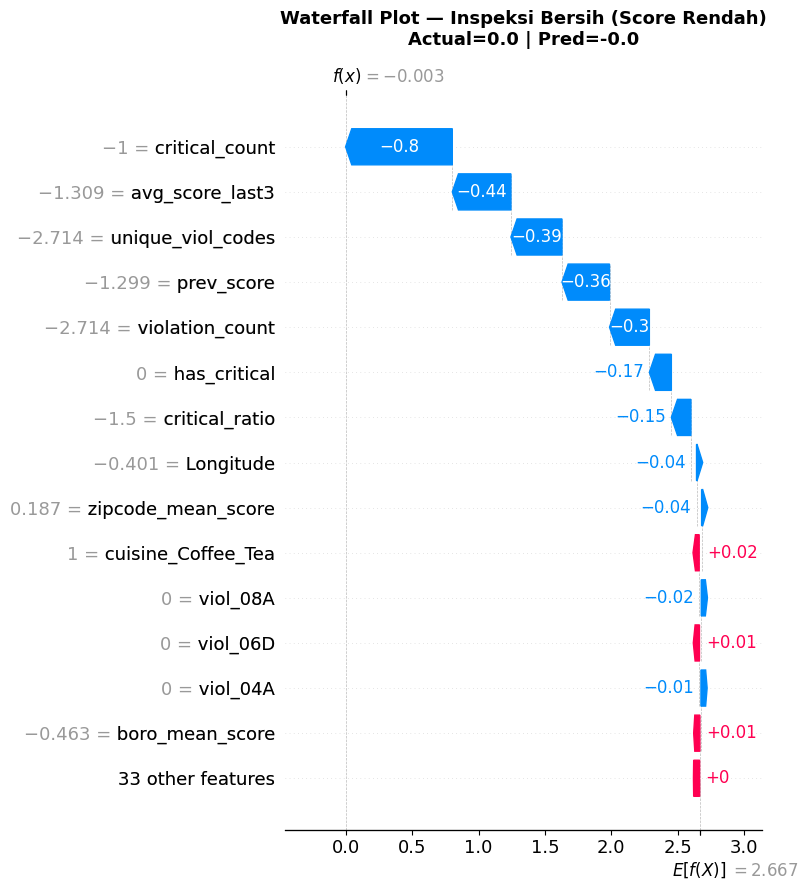

In [277]:
cases = [
    (idx_high,   "Inspeksi Berisiko Tinggi"),
    (idx_median, "Inspeksi Tipikal (Median)"),
    (idx_low,    "Inspeksi Bersih (Score Rendah)"),
]

for idx, title in cases:
    actual = np.expm1(y_test_sample.iloc[idx])
    pred   = np.expm1(lgb_tuned.predict(X_test_sample.iloc[[idx]])[0])

    fig, ax = plt.subplots(figsize=(14, 8))  
    plt.sca(ax)
    shap.waterfall_plot(
        shap_values[idx],
        max_display=15,   
        show=False
    )
    ax.set_title(
        f"Waterfall Plot — {title}\nActual={actual:.1f} | Pred={pred:.1f}",
        fontsize=13, fontweight="bold", pad=15
    )
    plt.tight_layout()
    plt.show()

## Local Analysis 2 — Force Plot ##

**Cara baca Force Plot:**
- Visualisasi alternatif dari Waterfall, lebih compact
- Panah merah = fitur yang **mendorong score naik** (higher risk)
- Panah biru = fitur yang **mendorong score turun** (lower risk)
- Panjang panah = besarnya kontribusi fitur
- `f(x)` = prediksi final | `base value` = baseline model


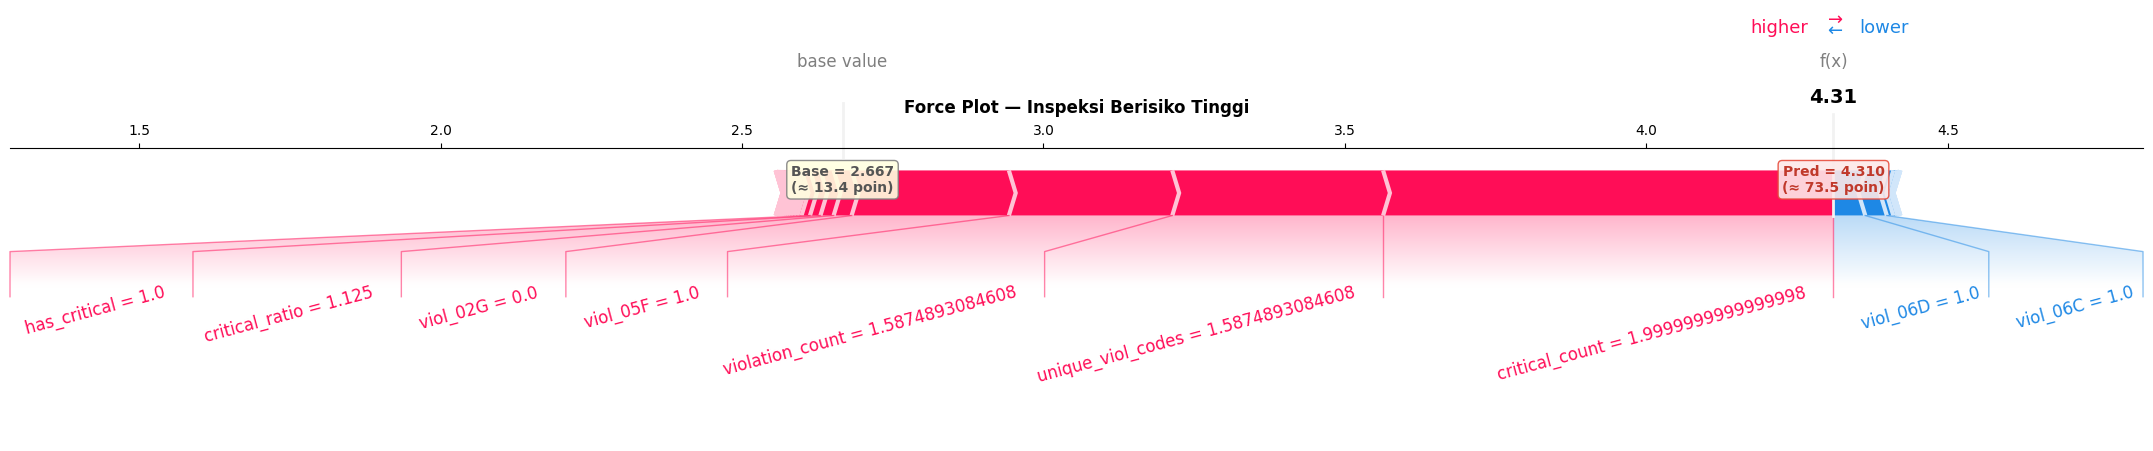

In [282]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx_high],
    X_test_sample.iloc[idx_high],
    matplotlib=True,
    show=False,
    figsize=(22, 5),
    text_rotation=15,
    contribution_threshold=0.015
)

base_orig = np.expm1(explainer.expected_value)
pred_orig = np.expm1(lgb_tuned.predict(X_test_sample.iloc[[idx_high]])[0])

plt.annotate(
    f"Base = {explainer.expected_value:.3f}\n(≈ {base_orig:.1f} poin)",
    xy=(explainer.expected_value, 0.85),
    xycoords=("data", "axes fraction"),
    fontsize=10, fontweight="bold", color="#555555",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
              edgecolor="gray", alpha=0.9)
)

plt.annotate(
    f"Pred = {explainer.expected_value + shap_values.values[idx_high].sum():.3f}\n(≈ {pred_orig:.1f} poin)",
    xy=(explainer.expected_value + shap_values.values[idx_high].sum(), 0.85),
    xycoords=("data", "axes fraction"),
    fontsize=10, fontweight="bold", color="#c0392b",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fde8e8",
              edgecolor="#e74c3c", alpha=0.9)
)

plt.title("Force Plot — Inspeksi Berisiko Tinggi",
          fontsize=12, fontweight="bold", pad=25)
plt.tight_layout()
plt.show()

Force Plot — Inspeksi Bersih (Score Rendah)
Actual SCORE : 0.0
Predicted    : -0.0



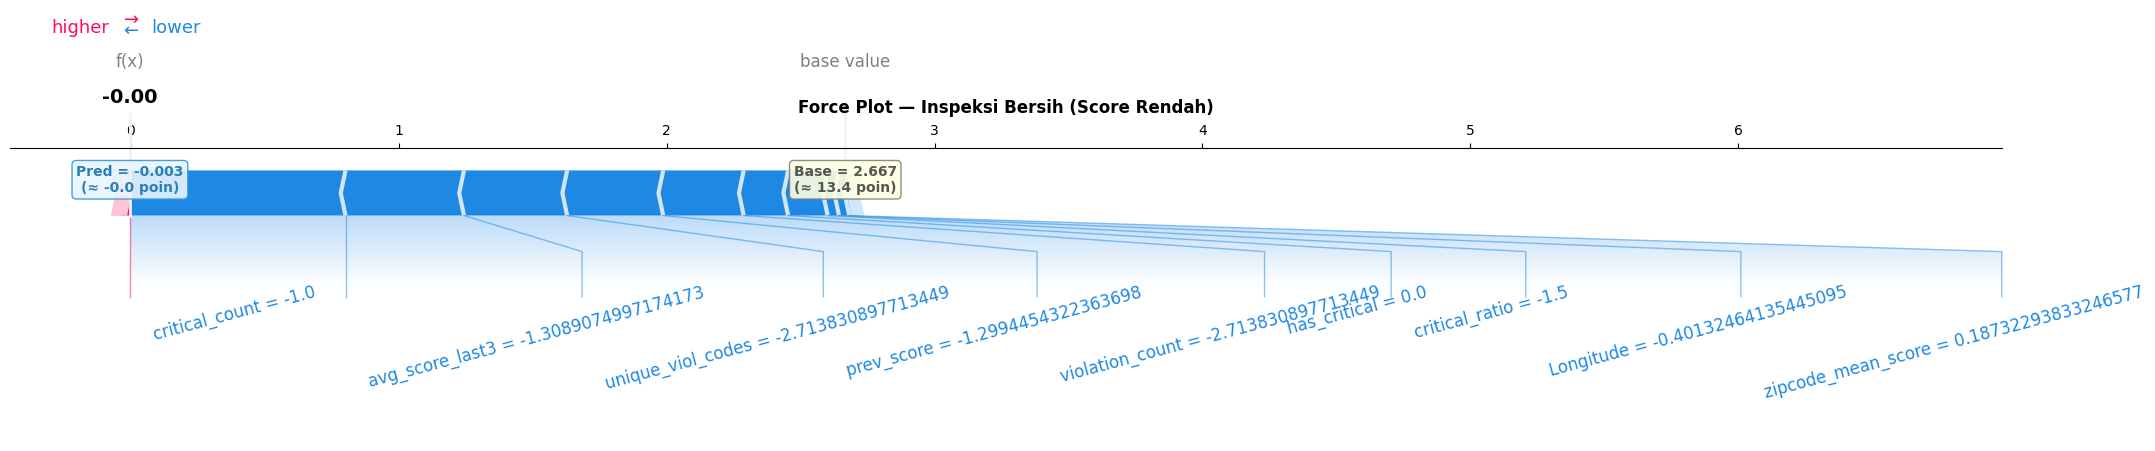

In [283]:
print("Force Plot — Inspeksi Bersih (Score Rendah)")
print(f"Actual SCORE : {np.expm1(y_test_sample.iloc[idx_low]):.1f}")
print(f"Predicted    : {np.expm1(lgb_tuned.predict(X_test_sample.iloc[[idx_low]])[0]):.1f}")
print()

shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx_low],
    X_test_sample.iloc[idx_low],
    matplotlib=True,
    show=False,
    figsize=(22, 5),
    text_rotation=15,
    contribution_threshold=0.015
)

base_orig = np.expm1(explainer.expected_value)
pred_orig = np.expm1(lgb_tuned.predict(X_test_sample.iloc[[idx_low]])[0])

plt.annotate(
    f"Base = {explainer.expected_value:.3f}\n(≈ {base_orig:.1f} poin)",
    xy=(explainer.expected_value, 0.85),
    xycoords=("data", "axes fraction"),
    fontsize=10, fontweight="bold", color="#555555",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
              edgecolor="gray", alpha=0.9)
)

pred_log1p = explainer.expected_value + shap_values.values[idx_low].sum()
plt.annotate(
    f"Pred = {pred_log1p:.3f}\n(≈ {pred_orig:.1f} poin)",
    xy=(pred_log1p, 0.85),
    xycoords=("data", "axes fraction"),
    fontsize=10, fontweight="bold", color="#2980b9",   # biru karena ini inspeksi bersih
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f4fd",
              edgecolor="#3498db", alpha=0.9)
)

plt.title("Force Plot — Inspeksi Bersih (Score Rendah)",
          fontsize=12, fontweight="bold", pad=25)
plt.tight_layout()
plt.show()

## Ringkasan Insight dari SHAP ##

In [284]:
mean_abs_shap = pd.DataFrame({
    "feature":    X_test_sample.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

mean_abs_shap["rank"] = mean_abs_shap.index + 1
mean_abs_shap["pct_contribution"] = (
    mean_abs_shap["mean_abs_shap"] / mean_abs_shap["mean_abs_shap"].sum() * 100
).round(2)

print("=" * 60)
print("  TOP 15 FITUR — Mean |SHAP| (LightGBM Tuned, Test Set)")
print("=" * 60)
print(f"{'Rank':<5} {'Feature':<35} {'Mean |SHAP|':>12} {'% Kontribusi':>13}")
print("-" * 60)
for _, row in mean_abs_shap.head(15).iterrows():
    print(f"{int(row['rank']):<5} {row['feature']:<35} "
          f"{row['mean_abs_shap']:>12.4f} {row['pct_contribution']:>12.2f}%")

top3_pct = mean_abs_shap.head(3)["pct_contribution"].sum()
print("-" * 60)
print(f"Top 3 fitur berkontribusi {top3_pct:.1f}% dari total SHAP")

  TOP 15 FITUR — Mean |SHAP| (LightGBM Tuned, Test Set)
Rank  Feature                              Mean |SHAP|  % Kontribusi
------------------------------------------------------------
1     critical_count                            0.2649        31.41%
2     unique_viol_codes                         0.1426        16.92%
3     violation_count                           0.1165        13.82%
4     has_critical                              0.0455         5.40%
5     critical_ratio                            0.0312         3.71%
6     viol_06D                                  0.0289         3.43%
7     viol_08A                                  0.0248         2.94%
8     viol_04A                                  0.0226         2.68%
9     avg_score_last3                           0.0190         2.25%
10    prev_score                                0.0185         2.20%
11    noncritical_count                         0.0182         2.16%
12    viol_02G                                  0.0138 

# Error Analysis ##

**Tujuan:** Mengidentifikasi pola sistematis di mana model paling sering salah.

Error analysis menjawab pertanyaan:
- Di rentang SCORE berapa model paling tidak akurat?
- Apakah ada BORO atau cuisine tertentu yang error-nya konsisten tinggi?
- Apakah ada periode waktu tertentu yang lebih sulit diprediksi?
- Apa karakteristik inspeksi yang paling sering under/overprediksi?

**Setup:** Gunakan prediksi LightGBM (Tuned) di test set, kembalikan ke skala SCORE asli untuk interpretasi yang lebih intuitif.


## Setup: Menyiapkan DataFrame Error Analysis ##

In [286]:
X_test_ea = X_test.copy()
if hasattr(lgb_tuned, "feature_names_in_"):
    X_test_ea.columns = lgb_tuned.feature_names_in_

y_pred_log   = lgb_tuned.predict(X_test_ea)
y_actual_log = y_test.values

y_actual_orig = np.expm1(y_actual_log)
y_pred_orig   = np.expm1(y_pred_log)

residual_log  = y_actual_log  - y_pred_log    
residual_orig = y_actual_orig - y_pred_orig   
abs_error     = np.abs(residual_orig)

df_err = test_df[["INSPECTION DATE", "CAMIS"]].copy().reset_index(drop=True)
df_err["actual_log"]    = y_actual_log
df_err["pred_log"]      = y_pred_log
df_err["actual_score"]  = y_actual_orig
df_err["pred_score"]    = y_pred_orig
df_err["residual"]      = residual_orig   
df_err["abs_error"]     = abs_error

meta_cols = ["CAMIS", "INSPECTION DATE", "BORO", "CUISINE_DESCRIPTION",
             "INSPECTION TYPE", "violation_count", "critical_count"]
df_ins_meta = df_ins[meta_cols].copy()
df_ins_meta["CAMIS"] = df_ins_meta["CAMIS"].astype(str)
df_ins_meta["INSPECTION DATE"] = pd.to_datetime(df_ins_meta["INSPECTION DATE"])

df_err["CAMIS"] = df_err["CAMIS"].astype(str)
df_err["INSPECTION DATE"] = pd.to_datetime(df_err["INSPECTION DATE"])

df_err = df_err.merge(df_ins_meta, on=["CAMIS", "INSPECTION DATE"], how="left")

print(f"Shape df_err: {df_err.shape}")
print(f"\nStatistik error (skala SCORE asli):")
print(f"  Mean error   : {residual_orig.mean():.3f}  (+ = underprediksi, - = overprediksi)")
print(f"  Median error : {np.median(residual_orig):.3f}")
print(f"  MAE          : {abs_error.mean():.3f}")
print(f"  Max error    : {abs_error.max():.1f}")
print(f"  % error > 10 : {(abs_error > 10).mean()*100:.1f}%")
print(f"  % error > 20 : {(abs_error > 20).mean()*100:.1f}%")


Shape df_err: (10329, 13)

Statistik error (skala SCORE asli):
  Mean error   : 0.664  (+ = underprediksi, - = overprediksi)
  Median error : -0.324
  MAE          : 3.049
  Max error    : 63.6
  % error > 10 : 6.1%
  % error > 20 : 2.6%


## Analisis 1 — Distribusi Error ##

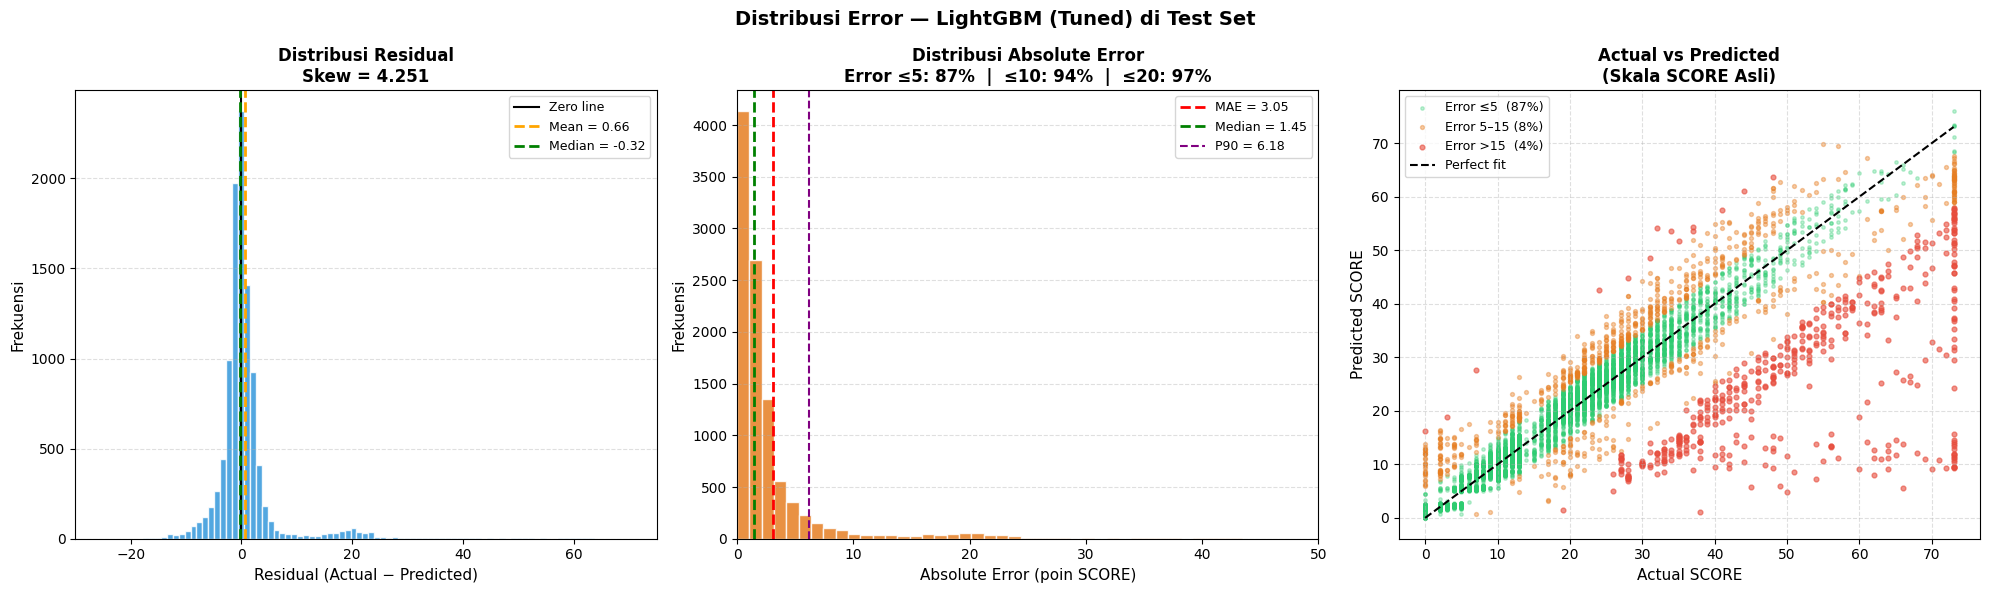

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(residual_orig, bins=80, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="black", linestyle="-", linewidth=1.5, label="Zero line")
axes[0].axvline(residual_orig.mean(), color="orange", linestyle="--", linewidth=2,
                label=f"Mean = {residual_orig.mean():.2f}")
axes[0].axvline(np.median(residual_orig), color="green", linestyle="--", linewidth=2,
                label=f"Median = {np.median(residual_orig):.2f}")
axes[0].set_xlim(-30, 75)
axes[0].set_title(f"Distribusi Residual\nSkew = {pd.Series(residual_orig).skew():.3f}",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Residual (Actual − Predicted)", fontsize=11)
axes[0].set_ylabel("Frekuensi", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

p90 = np.percentile(abs_error, 90)
pct5  = (abs_error <= 5).mean()  * 100
pct10 = (abs_error <= 10).mean() * 100
pct20 = (abs_error <= 20).mean() * 100

axes[1].hist(abs_error, bins=60, color="#e67e22", edgecolor="white", alpha=0.85)
axes[1].axvline(abs_error.mean(), color="red",    linestyle="--", linewidth=2,
                label=f"MAE = {abs_error.mean():.2f}")
axes[1].axvline(np.median(abs_error), color="green", linestyle="--", linewidth=2,
                label=f"Median = {np.median(abs_error):.2f}")
axes[1].axvline(p90, color="purple", linestyle="--", linewidth=1.5,
                label=f"P90 = {p90:.2f}")
axes[1].set_xlim(0, 50)
axes[1].set_title(
    f"Distribusi Absolute Error\n"
    f"Error ≤5: {pct5:.0f}%  |  ≤10: {pct10:.0f}%  |  ≤20: {pct20:.0f}%",
    fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Absolute Error (poin SCORE)", fontsize=11)
axes[1].set_ylabel("Frekuensi", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

low_err  = abs_error <= 5
mid_err  = (abs_error > 5)  & (abs_error <= 15)
high_err = abs_error > 15

axes[2].scatter(y_actual_orig[low_err],  y_pred_orig[low_err],
                alpha=0.3, s=6, color="#2ecc71", label=f"Error ≤5  ({low_err.mean()*100:.0f}%)")
axes[2].scatter(y_actual_orig[mid_err],  y_pred_orig[mid_err],
                alpha=0.4, s=8, color="#e67e22", label=f"Error 5–15 ({mid_err.mean()*100:.0f}%)")
axes[2].scatter(y_actual_orig[high_err], y_pred_orig[high_err],
                alpha=0.6, s=12, color="#e74c3c", label=f"Error >15  ({high_err.mean()*100:.0f}%)")
mn, mx = 0, y_actual_orig.max()
axes[2].plot([mn, mx], [mn, mx], "k--", linewidth=1.5, label="Perfect fit")
axes[2].set_title("Actual vs Predicted\n(Skala SCORE Asli)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Actual SCORE", fontsize=11)
axes[2].set_ylabel("Predicted SCORE", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Error — LightGBM (Tuned) di Test Set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis 2 — Error per Rentang SCORE ##

Model mungkin lebih akurat di range SCORE tertentu. Inspeksi dengan SCORE sangat tinggi (>40) atau sangat rendah (0) biasanya lebih sulit diprediksi.


=== Error per Rentang SCORE ===
score_bucket  count       mae  median_ae  mean_resid  pct_error_10
         0–5   1180  1.659718   0.708740   -1.013730      2.966102
        6–10   1426  1.430607   1.396776   -0.893545      0.140252
       11–15   3521  1.215785   0.910287    0.034772      0.056802
       16–20    695  2.694928   2.119040   -0.470774      2.014388
       21–30   1850  2.892998   2.073898   -0.580939      3.513514
       31–40    784  5.289051   3.105076    1.450729     13.775510
       41–73    873 13.569344   8.611510   10.853467     46.620848


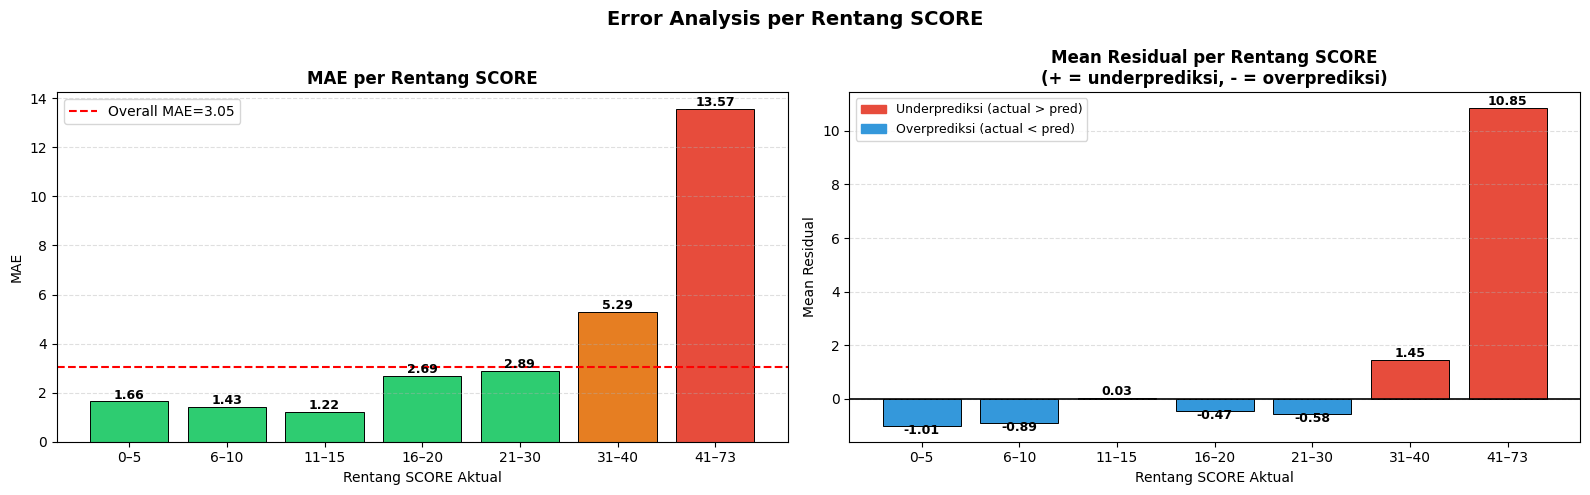

In [291]:
bins   = [0, 5, 10, 15, 20, 30, 40, 75]
labels = ["0–5", "6–10", "11–15", "16–20", "21–30", "31–40", "41–73"]

df_err["score_bucket"] = pd.cut(df_err["actual_score"], bins=bins, labels=labels,
                                 right=True, include_lowest=True)

bucket_stats = (
    df_err.groupby("score_bucket", observed=True)
    .agg(
        count        = ("abs_error", "count"),
        mae          = ("abs_error", "mean"),
        median_ae    = ("abs_error", "median"),
        mean_resid   = ("residual",  "mean"),
        pct_error_10 = ("abs_error", lambda x: (x > 10).mean() * 100)
    )
    .reset_index()
)

print("=== Error per Rentang SCORE ===")
print(bucket_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#2ecc71" if m < 3 else "#e67e22" if m < 7 else "#e74c3c"
          for m in bucket_stats["mae"]]
bars = axes[0].bar(bucket_stats["score_bucket"], bucket_stats["mae"],
                   color=colors, edgecolor="black", linewidth=0.7)
axes[0].axhline(abs_error.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Overall MAE={abs_error.mean():.2f}")
for bar, val in zip(bars, bucket_stats["mae"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("MAE per Rentang SCORE", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rentang SCORE Aktual"); axes[0].set_ylabel("MAE")
axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

colors2 = ["#e74c3c" if r > 0 else "#3498db" for r in bucket_stats["mean_resid"]]
bars2 = axes[1].bar(bucket_stats["score_bucket"], bucket_stats["mean_resid"],
                    color=colors2, edgecolor="black", linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=1.2)
for bar, val in zip(bars2, bucket_stats["mean_resid"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + (0.1 if val >= 0 else -0.3),
                 f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Mean Residual per Rentang SCORE\n(+ = underprediksi, - = overprediksi)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rentang SCORE Aktual"); axes[1].set_ylabel("Mean Residual")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color="#e74c3c", label="Underprediksi (actual > pred)"),
    Patch(color="#3498db", label="Overprediksi (actual < pred)"),
], fontsize=9)

plt.suptitle("Error Analysis per Rentang SCORE", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Analisis 3 — Error per BORO ##

=== Error per BORO ===
         BORO  count      mae  median_ae  mean_resid
     Brooklyn   2763 3.358813   1.459948    0.983564
       Queens   2532 3.041312   1.535586    0.568429
    Manhattan   3679 2.928527   1.415689    0.629521
        Bronx    974 2.763421   1.287484    0.553968
Staten Island    375 2.628189   1.581658   -0.564076
      Unknown      0      NaN        NaN         NaN


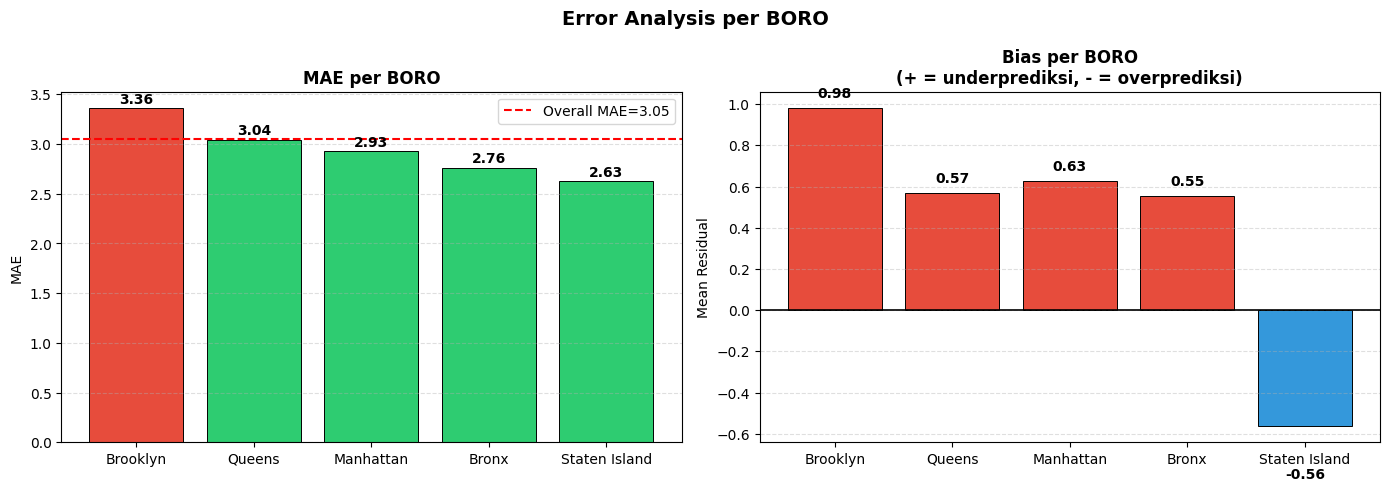

In [292]:
boro_err = (
    df_err[df_err["BORO"].notna() & (df_err["BORO"] != "Unknown") & (df_err["BORO"] != "0")]
    .groupby("BORO")
    .agg(
        count      = ("abs_error", "count"),
        mae        = ("abs_error", "mean"),
        median_ae  = ("abs_error", "median"),
        mean_resid = ("residual",  "mean"),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

print("=== Error per BORO ===")
print(boro_err.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_boro = ["#e74c3c" if m > abs_error.mean() else "#2ecc71"
               for m in boro_err["mae"]]
bars = axes[0].bar(boro_err["BORO"], boro_err["mae"],
                   color=colors_boro, edgecolor="black", linewidth=0.7)
axes[0].axhline(abs_error.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Overall MAE={abs_error.mean():.2f}")
for bar, val in zip(bars, boro_err["mae"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("MAE per BORO", fontsize=12, fontweight="bold")
axes[0].set_ylabel("MAE"); axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

colors_resid = ["#e74c3c" if r > 0 else "#3498db" for r in boro_err["mean_resid"]]
bars2 = axes[1].bar(boro_err["BORO"], boro_err["mean_resid"],
                    color=colors_resid, edgecolor="black", linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=1.2)
for bar, val in zip(bars2, boro_err["mean_resid"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + (0.05 if val >= 0 else -0.25),
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Bias per BORO\n(+ = underprediksi, - = overprediksi)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean Residual")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Error Analysis per BORO", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis 4 — Error per Cuisine (Top 15) ##

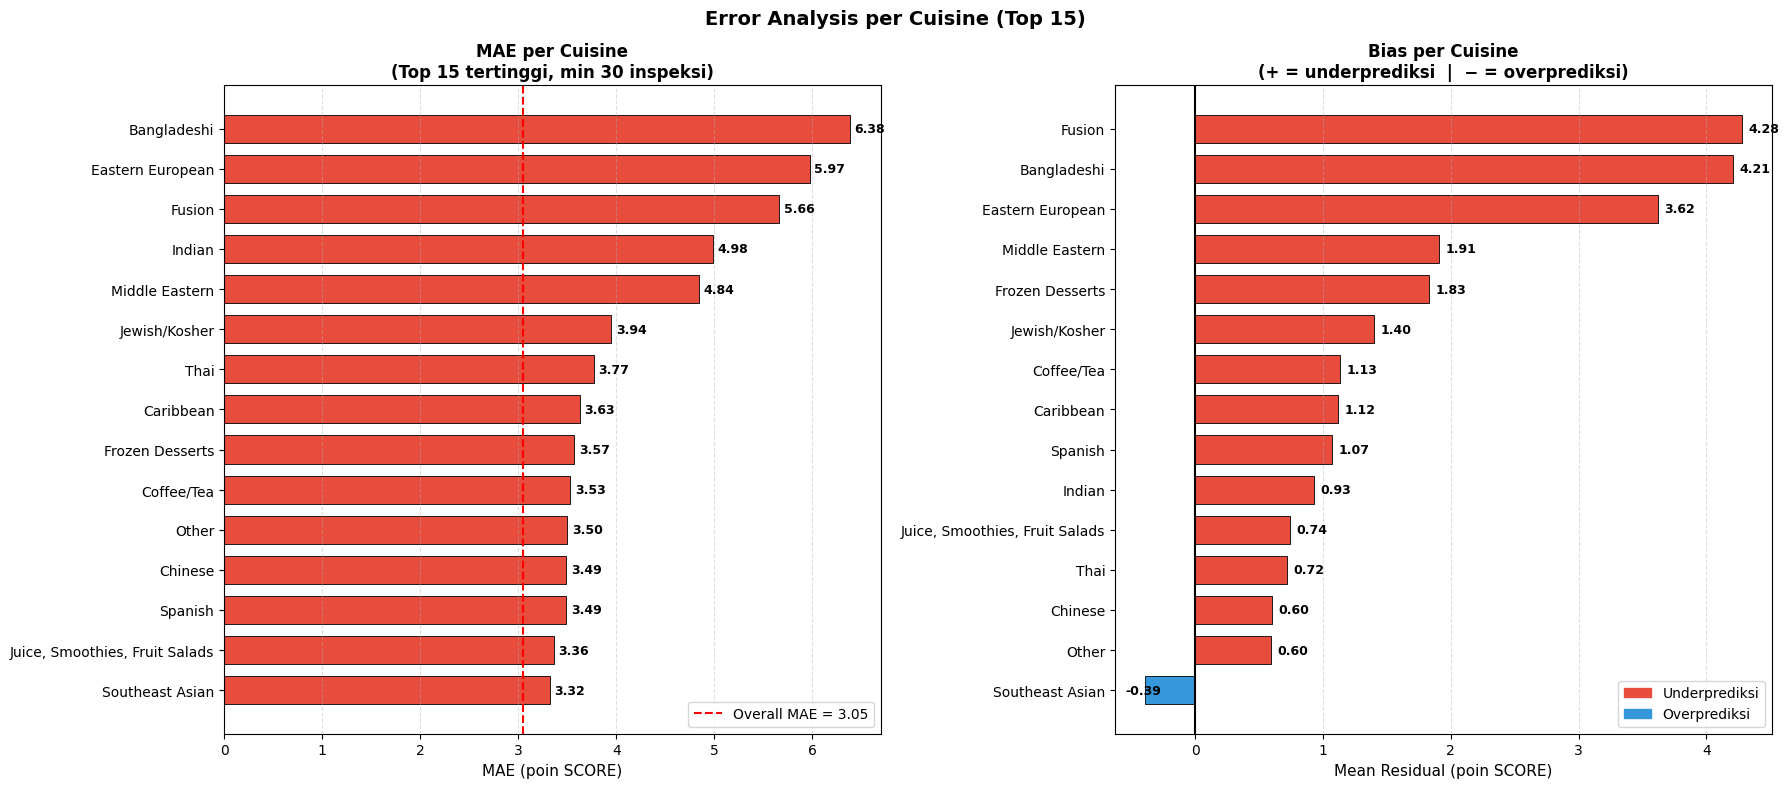

In [295]:
cuisine_err = (
    df_err.dropna(subset=["CUISINE_DESCRIPTION"])
    .groupby("CUISINE_DESCRIPTION")
    .agg(
        count      = ("abs_error", "count"),
        mae        = ("abs_error", "mean"),
        mean_resid = ("residual",  "mean"),
    )
    .reset_index()
)

cuisine_err = (
    cuisine_err[cuisine_err["count"] >= 30]
    .sort_values("mae", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

cuisine_plot = cuisine_err.sort_values("mae", ascending=True) 
colors_c = ["#e74c3c" if m > abs_error.mean() else "#2ecc71"
            for m in cuisine_plot["mae"]]

axes[0].barh(cuisine_plot["CUISINE_DESCRIPTION"], cuisine_plot["mae"],
             color=colors_c, edgecolor="black", linewidth=0.6, height=0.7)
axes[0].axvline(abs_error.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Overall MAE = {abs_error.mean():.2f}")

for i, (_, row) in enumerate(cuisine_plot.iterrows()):
    axes[0].text(row["mae"] + 0.05, i, f"{row['mae']:.2f}",
                 va="center", fontsize=9, fontweight="bold")

axes[0].set_title("MAE per Cuisine\n(Top 15 tertinggi, min 30 inspeksi)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("MAE (poin SCORE)", fontsize=11)
axes[0].tick_params(axis="y", labelsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

cuisine_bias = cuisine_err.sort_values("mean_resid", ascending=True)
colors_rc = ["#e74c3c" if r > 0 else "#3498db" for r in cuisine_bias["mean_resid"]]

axes[1].barh(cuisine_bias["CUISINE_DESCRIPTION"], cuisine_bias["mean_resid"],
             color=colors_rc, edgecolor="black", linewidth=0.6, height=0.7)
axes[1].axvline(0, color="black", linewidth=1.5)

for i, (_, row) in enumerate(cuisine_bias.iterrows()):
    pad = 0.05 if row["mean_resid"] >= 0 else -0.15
    axes[1].text(row["mean_resid"] + pad, i, f"{row['mean_resid']:.2f}",
                 va="center", fontsize=9, fontweight="bold")

axes[1].set_title("Bias per Cuisine\n(+ = underprediksi  |  − = overprediksi)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mean Residual (poin SCORE)", fontsize=11)
axes[1].tick_params(axis="y", labelsize=10)
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color="#e74c3c", label="Underprediksi"),
    Patch(color="#3498db", label="Overprediksi"),
], fontsize=10)

plt.suptitle("Error Analysis per Cuisine (Top 15)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis 5 — Error per Inspection Type ##

=== Error per Inspection Type ===
                                            INSPECTION TYPE  count       mae  mean_resid
          Pre-permit (Non-operational) / Initial Inspection    110 22.491043   17.215908
           Pre-permit (Operational) / Compliance Inspection     60 16.689056   15.014251
                   Cycle Inspection / Compliance Inspection     29 16.495087   14.147329
       Pre-permit (Non-operational) / Compliance Inspection      7 14.807034    0.001075
Pre-permit (Non-operational) / Second Compliance Inspection      2 14.342930    8.018784
               Pre-permit (Non-operational) / Re-inspection     32 13.237641    8.000649
            Pre-permit (Operational) / Reopening Inspection     72 11.267535   -0.780184
              Pre-permit (Operational) / Initial Inspection   1770  4.013961    0.966888
    Pre-permit (Operational) / Second Compliance Inspection      3  3.749292    1.832029
            Cycle Inspection / Second Compliance Inspection      1  3.630167

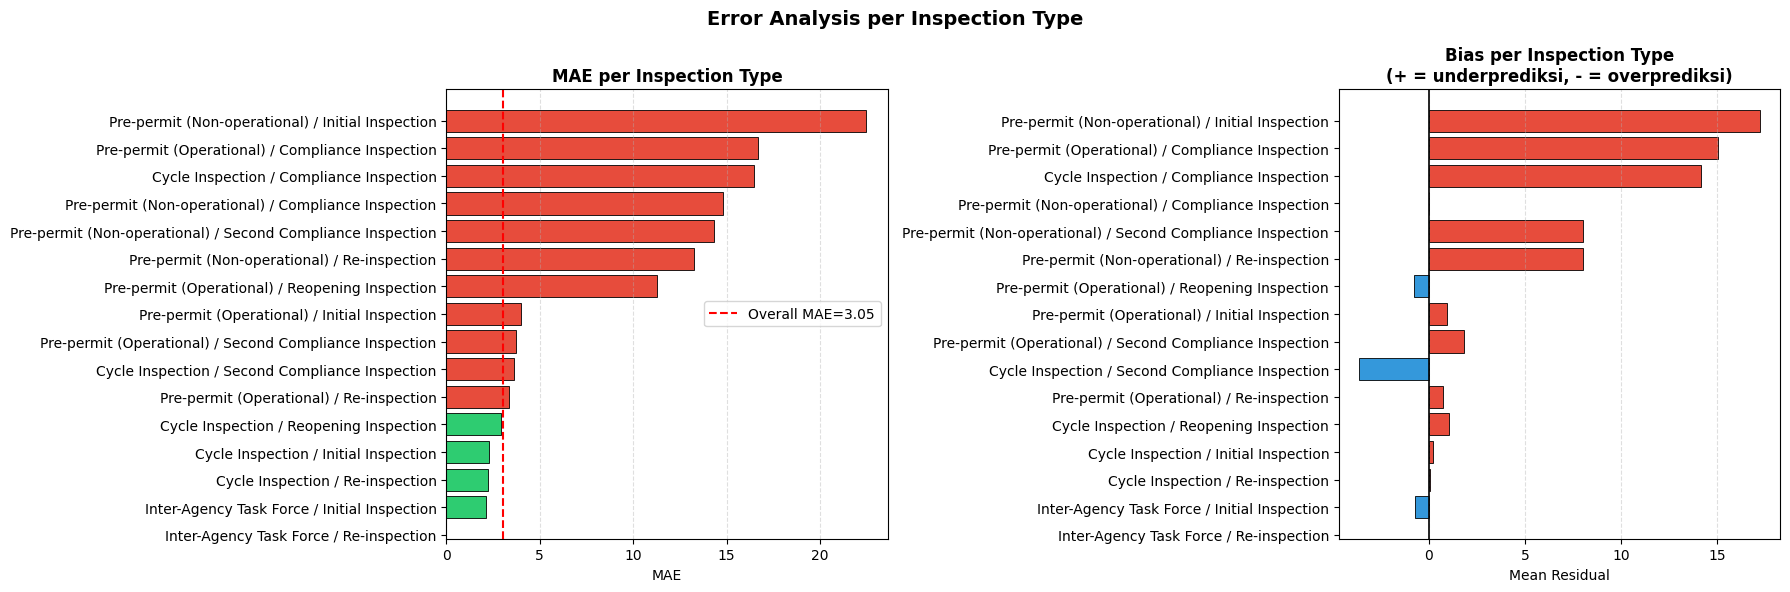

In [296]:
instype_err = (
    df_err.dropna(subset=["INSPECTION TYPE"])
    .groupby("INSPECTION TYPE")
    .agg(
        count      = ("abs_error", "count"),
        mae        = ("abs_error", "mean"),
        mean_resid = ("residual",  "mean"),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

print("=== Error per Inspection Type ===")
print(instype_err.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_it = ["#e74c3c" if m > abs_error.mean() else "#2ecc71"
             for m in instype_err["mae"]]
axes[0].barh(instype_err["INSPECTION TYPE"], instype_err["mae"],
             color=colors_it, edgecolor="black", linewidth=0.6)
axes[0].axvline(abs_error.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Overall MAE={abs_error.mean():.2f}")
axes[0].set_title("MAE per Inspection Type", fontsize=12, fontweight="bold")
axes[0].set_xlabel("MAE"); axes[0].legend()
axes[0].invert_yaxis(); axes[0].grid(axis="x", linestyle="--", alpha=0.4)

colors_ri = ["#e74c3c" if r > 0 else "#3498db" for r in instype_err["mean_resid"]]
axes[1].barh(instype_err["INSPECTION TYPE"], instype_err["mean_resid"],
             color=colors_ri, edgecolor="black", linewidth=0.6)
axes[1].axvline(0, color="black", linewidth=1.2)
axes[1].set_title("Bias per Inspection Type\n(+ = underprediksi, - = overprediksi)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mean Residual")
axes[1].invert_yaxis(); axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Error Analysis per Inspection Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis 6 — Inspeksi dengan Error Terbesar ##

=== Top 20 Inspeksi dengan Error Terbesar ===
    actual_score  pred_score  residual  abs_error       BORO CUISINE_DESCRIPTION                                    INSPECTION TYPE  violation_count  critical_count
1           73.0        9.40     63.60      63.60   Brooklyn            American  Pre-permit (Non-operational) / Initial Inspection                7               4
2           73.0        9.48     63.52      63.52   Brooklyn           Soul Food  Pre-permit (Non-operational) / Initial Inspection               14               7
3           73.0        9.51     63.49      63.49   Brooklyn      Middle Eastern  Pre-permit (Non-operational) / Initial Inspection                5               3
4           73.0        9.56     63.44      63.44  Manhattan               Other  Pre-permit (Non-operational) / Initial Inspection               10               8
5           72.0        9.35     62.65      62.65     Queens         Bangladeshi    Pre-permit (Operational) / Reopening Inspecti

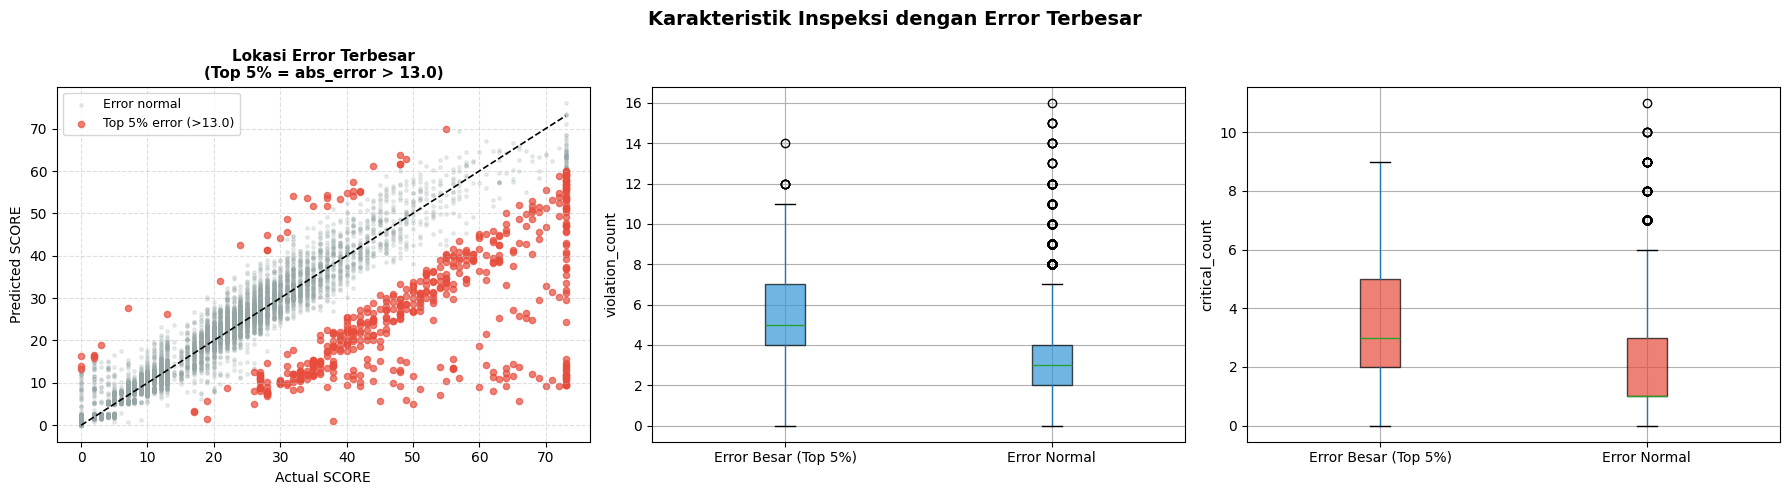

In [297]:
top_errors = (
    df_err.nlargest(20, "abs_error")
    [["actual_score", "pred_score", "residual", "abs_error",
       "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE",
       "violation_count", "critical_count"]]
    .reset_index(drop=True)
)
top_errors.index += 1

print("=== Top 20 Inspeksi dengan Error Terbesar ===")
print(top_errors.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

threshold_high = np.percentile(abs_error, 95)
mask_high = abs_error >= threshold_high

axes[0].scatter(y_actual_orig[~mask_high], y_pred_orig[~mask_high],
                alpha=0.2, s=6, color="#95a5a6", label="Error normal")
axes[0].scatter(y_actual_orig[mask_high], y_pred_orig[mask_high],
                alpha=0.7, s=20, color="#e74c3c", label=f"Top 5% error (>{threshold_high:.1f})")
mn, mx = 0, y_actual_orig.max()
axes[0].plot([mn, mx], [mn, mx], "k--", linewidth=1.2)
axes[0].set_title(f"Lokasi Error Terbesar\n(Top 5% = abs_error > {threshold_high:.1f})",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Actual SCORE"); axes[0].set_ylabel("Predicted SCORE")
axes[0].legend(fontsize=9); axes[0].grid(linestyle="--", alpha=0.4)

df_err["error_group"] = np.where(abs_error >= threshold_high, "Error Besar (Top 5%)", "Error Normal")
df_err.boxplot(column="violation_count", by="error_group", ax=axes[1],
               patch_artist=True,
               boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Violation Count\nvs Error Group", fontsize=11, fontweight="bold")
axes[1].set_xlabel(""); axes[1].set_ylabel("violation_count")
plt.sca(axes[1]); plt.title("")

df_err.boxplot(column="critical_count", by="error_group", ax=axes[2],
               patch_artist=True,
               boxprops=dict(facecolor="#e74c3c", alpha=0.7))
axes[2].set_title("Critical Count\nvs Error Group", fontsize=11, fontweight="bold")
axes[2].set_xlabel(""); axes[2].set_ylabel("critical_count")
plt.sca(axes[2]); plt.title("")

plt.suptitle("Karakteristik Inspeksi dengan Error Terbesar",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Ringkasan Error Analysis ##

In [298]:
print("=" * 60)
print("  RINGKASAN ERROR ANALYSIS — LightGBM (Tuned)")
print("=" * 60)

print(f"\n📊 Overall:")
print(f"  MAE          : {abs_error.mean():.3f} poin SCORE")
print(f"  Median AE    : {np.median(abs_error):.3f} poin SCORE")
print(f"  % error ≤ 5  : {(abs_error <= 5).mean()*100:.1f}%")
print(f"  % error ≤ 10 : {(abs_error <= 10).mean()*100:.1f}%")
print(f"  % error > 20 : {(abs_error > 20).mean()*100:.1f}%")

print(f"\n📍 BORO tersulit (MAE tertinggi):")
top_boro = boro_err.iloc[0]
print(f"  {top_boro['BORO']:<20} MAE={top_boro['mae']:.3f}  n={top_boro['count']}")

print(f"\n🍽️  Cuisine tersulit (MAE tertinggi):")
top_cuisine_err = cuisine_err.iloc[0]
print(f"  {top_cuisine_err['CUISINE_DESCRIPTION']:<25} MAE={top_cuisine_err['mae']:.3f}  n={top_cuisine_err['count']}")

print(f"\n📋 Inspection Type tersulit:")
top_instype = instype_err.iloc[0]
print(f"  {top_instype['INSPECTION TYPE'][:40]:<40} MAE={top_instype['mae']:.3f}")

print(f"\n📈 Rentang SCORE paling sulit diprediksi:")
hardest_bucket = bucket_stats.loc[bucket_stats['mae'].idxmax()]
print(f"  SCORE {hardest_bucket['score_bucket']} → MAE={hardest_bucket['mae']:.3f}")

print(f"\n💡 Temuan utama:")
over_pct  = (residual_orig < 0).mean() * 100
under_pct = (residual_orig > 0).mean() * 100
print(f"  Model underprediksi : {under_pct:.1f}% dari test set")
print(f"  Model overprediksi  : {over_pct:.1f}% dari test set")
print(f"  → Model cenderung {'underprediksi' if under_pct > over_pct else 'overprediksi'} secara keseluruhan")

  RINGKASAN ERROR ANALYSIS — LightGBM (Tuned)

📊 Overall:
  MAE          : 3.049 poin SCORE
  Median AE    : 1.454 poin SCORE
  % error ≤ 5  : 87.3%
  % error ≤ 10 : 93.9%
  % error > 20 : 2.6%

📍 BORO tersulit (MAE tertinggi):
  Brooklyn             MAE=3.359  n=2763

🍽️  Cuisine tersulit (MAE tertinggi):
  Bangladeshi               MAE=6.379  n=63

📋 Inspection Type tersulit:
  Pre-permit (Non-operational) / Initial I MAE=22.491

📈 Rentang SCORE paling sulit diprediksi:
  SCORE 41–73 → MAE=13.569

💡 Temuan utama:
  Model underprediksi : 43.1% dari test set
  Model overprediksi  : 56.9% dari test set
  → Model cenderung overprediksi secara keseluruhan
